In [4]:
import os
os.getcwd()
os.listdir()

['.ipynb_checkpoints', 'bindingdb_raw.tsv', 'chembl_raw.csv', 'Untitled.ipynb']

In [8]:
import pandas as pd

chembl = pd.read_csv("chembl_raw.csv", sep=None, engine="python")
bindingdb = pd.read_csv("bindingdb_raw.tsv", sep="\t", low_memory=False)

print("ChEMBL shape:", chembl.shape)
print("BindingDB shape:", bindingdb.shape)

ChEMBL shape: (13587, 48)
BindingDB shape: (10343, 640)


In [10]:
# =========================
# 1. target name
# =========================
chembl_cyp = chembl[
    chembl["Target Name"].str.contains(
        "cytochrome p450 3a4",
        case=False,
        na=False
    )
]
print("After target filter:", chembl_cyp.shape)


# =========================
# 2. assay description
# =========================
chembl_cyp = chembl_cyp[
    chembl_cyp["Assay Description"].str.contains(
        "human",
        case=False,
        na=False
    )
    &
    chembl_cyp["Assay Description"].str.contains(
        "recombinant",
        case=False,
        na=False
    )
]
print("After assay description filter:", chembl_cyp.shape)


# =========================
# 3. remove substrate / time assay
# =========================
chembl_cyp = chembl_cyp[
    ~chembl_cyp["Assay Description"].str.contains(
        "substrate|metabolite|midazolam|testosterone|nifedipine|min|minutes|time-dependent|preincub",
        case=False,
        na=False
    )
]
print("After substrate/time cleaning:", chembl_cyp.shape)


# =========================
# 4. standard type
# =========================
chembl_ic50 = chembl_cyp[
    chembl_cyp["Standard Type"] == "IC50"
]
print("After IC50 filter:", chembl_ic50.shape)


# =========================
# 5. standard value
# =========================
chembl_ic50 = chembl_ic50[
    chembl_ic50["Standard Value"].notna()
]
print("After value filter:", chembl_ic50.shape)


# =========================
# 6. standard unit
# =========================
chembl_ic50 = chembl_ic50[
    chembl_ic50["Standard Units"] == "nM"
]
print("After unit filter:", chembl_ic50.shape)


# =========================
# 7. final selected columns
# =========================
chembl_final = chembl_ic50[[
    "Molecule ChEMBL ID",
    "Smiles",
    "Standard Value",
    "Assay Description"
]].copy()

chembl_final.columns = [
    "Molecule_ID",
    "SMILES",
    "IC50",
    "Assay_Description"
]

chembl_final["Source"] = "ChEMBL"

chembl_final = chembl_final[
    ["Source", "Molecule_ID", "SMILES", "IC50", "Assay_Description"]
]

print("Final ChEMBL clean:", chembl_final.shape)
chembl_final.head()

After target filter: (13587, 48)
After assay description filter: (1088, 48)
After substrate/time cleaning: (431, 48)
After IC50 filter: (431, 48)
After value filter: (407, 48)
After unit filter: (405, 48)
Final ChEMBL clean: (405, 5)


,Source,Molecule_ID,SMILES,IC50,Assay_Description
79,ChEMBL,CHEMBL2419495,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,1400.0,Inhibition of human recombinant CYP3A4
80,ChEMBL,CHEMBL2419491,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,4500.0,Inhibition of human recombinant CYP3A4
100,ChEMBL,CHEMBL3112864,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21,40000.0,Inhibition of recombinant human CYP3A4
176,ChEMBL,CHEMBL4102920,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...,1400.0,Inhibition of recombinant human CYP3A4
183,ChEMBL,CHEMBL2296321,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...,10000.0,Inhibition of Homo sapiens (human) recombinant...


In [11]:
chembl_final.to_csv("chembl_clean_human_recombinant_cyp3a4.csv", index=False)

print("✅ ChEMBL cleaned dataset saved")
print(chembl_final.shape)

✅ ChEMBL cleaned dataset saved
(405, 5)


In [12]:
chembl_final["Assay_Description"].value_counts().head(20)

Assay_Description
Inhibition of human recombinant CYP3A4                                                                                                                                                                                                                                                                      109
Inhibition of recombinant human CYP3A4                                                                                                                                                                                                                                                                       64
Biological Assay Example 6: The assay was based on a method published by Moody et al. (Xenobiotica 1999). The inhibition of cytochrome P450 3A4-isoenzyme catalysed N-demethylation of [N-methyl-14C]-Erythromycin by the test compound was assayed at 37° C with human recombinant cytochrome P450 3A4.     60
Inhibition of human recombinant CYP3A4-mediated oxidation of 7-benzylo

In [13]:
import pandas as pd

binding = pd.read_csv(
    "bindingdb_raw.tsv",
    sep="\t",
    low_memory=False
)

# STEP 1 — filter CYP3A4
binding_cyp = binding[
    binding["Target Name"].str.contains(
        "cytochrome p450 3a4",
        case=False,
        na=False
    )
]

print("After target filter:", binding_cyp.shape)


# STEP 2 — keep IC50 only
binding_ic50 = binding_cyp[
    binding_cyp["IC50 (nM)"].notna()
]

print("IC50 rows:", binding_ic50.shape)


# STEP 3 — extract minimal dataset
binding_final = binding_ic50[[
    "ChEMBL ID of Ligand",
    "Ligand SMILES",
    "IC50 (nM)"
]].copy()

binding_final.columns = ["Molecule_ID", "SMILES", "IC50"]


# STEP 4 — convert IC50 to numeric
binding_final["IC50"] = pd.to_numeric(
    binding_final["IC50"],
    errors="coerce"
)

binding_final = binding_final.dropna()


# STEP 5 — add source column
binding_final["Source"] = "BindingDB"


# STEP 6 — reorder columns (same as ChEMBL)
binding_final = binding_final[
    ["Source", "Molecule_ID", "SMILES", "IC50"]
]

print(binding_final.shape)
binding_final.head()

After target filter: (10343, 640)
IC50 rows: (10343, 640)
(3366, 4)


,Source,Molecule_ID,SMILES,IC50
1,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1[C@@H]([C@H](C...,0.0962
4,BindingDB,CHEMBL75,CC(=O)N1CCN(CC1)c2ccc(cc2)OC[C@H]3CO[C@](O3)(C...,0.1800
5,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@@H](N1S(=O)(=O)c1ccc(Cl)cc1)...,0.3000
7,BindingDB,CHEMBL520419,Cc1cc(cc2[nH]c(nc12)-c1c(NC[C@@H](O)c2cccc(Cl)...,0.4000
9,BindingDB,CHEMBL1271822,CC(C)(CO)N1CCN(CC1)C(=O)OC[C@H]1COC[C@H](N1S(=...,0.5000


In [14]:
missing_id = binding_ic50["ChEMBL ID of Ligand"].isna().sum()
print("Missing ChEMBL ID:", missing_id)

Missing ChEMBL ID: 4838


In [15]:
print("Missing ID:", binding_ic50["ChEMBL ID of Ligand"].isna().sum())
print("Missing SMILES:", binding_ic50["Ligand SMILES"].isna().sum())

ic50_numeric = pd.to_numeric(binding_ic50["IC50 (nM)"], errors="coerce")
print("Non-numeric IC50:", ic50_numeric.isna().sum())

Missing ID: 4838
Missing SMILES: 0
Non-numeric IC50: 4671


In [16]:
binding_final.to_csv("bindingdb_clean_cyp3a4.csv", index=False)
print("✅ BindingDB cleaned dataset saved")
print(binding_final.shape)

✅ BindingDB cleaned dataset saved
(3366, 4)


data cleaning - chembl

In [17]:
# 1.Remove invalid smiles

from rdkit import Chem

# cek validitas smiles
chembl_final["Mol"] = chembl_final["SMILES"].apply(
    lambda x: Chem.MolFromSmiles(x)
)

# keep valid only
chembl_valid = chembl_final[
    chembl_final["Mol"].notna()
].copy()

print("Before invalid SMILES removal:", chembl_final.shape)
print("After invalid SMILES removal:", chembl_valid.shape)
print("Removed invalid SMILES:", chembl_final.shape[0] - chembl_valid.shape[0])

Before invalid SMILES removal: (405, 6)
After invalid SMILES removal: (405, 6)
Removed invalid SMILES: 0


In [18]:
# 2. remove salt
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem

# salt remover
lfc = rdMolStandardize.LargestFragmentChooser()

chembl_valid["Mol_NoSalt"] = chembl_valid["Mol"].apply(
    lambda mol: lfc.choose(mol)
)

# convert back to smiles for checking
chembl_valid["SMILES_NoSalt"] = chembl_valid["Mol_NoSalt"].apply(
    lambda mol: Chem.MolToSmiles(mol)
)

print("After salt removal:", chembl_valid.shape)
chembl_valid[["SMILES", "SMILES_NoSalt"]].head(10)

[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Fragment: Cl
[21:04:36] New largest fragment: Cl (2)
[21:04:36] Fragment: O=c1c2c3n(c(=O)cc2[nH]n1-c1ccccc1Cl)CCCN(Cc1ccccc1)C3
[21:04:36] New largest fragment: O=c1c2c3n(c(=O)cc2[nH]n1-c1ccccc1Cl)CCCN(Cc1ccccc1)C3 (51)
[21:04:36] Running LargestFragmentChooser
[21:04:36] Running LargestFragmentChooser
[21:04:36] Ru

After salt removal: (405, 8)


,SMILES,SMILES_NoSalt
79,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...
80,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...
100,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21
176,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...
183,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...
280,C[C@@H](c1ccc(-c2ccn(C(F)F)c(=O)c2)cc1)N1CC[C@...,C[C@@H](c1ccc(-c2ccn(C(F)F)c(=O)c2)cc1)N1CC[C@...
281,C[C@@H](c1ccc(-c2ccc(=O)n(C)c2)cc1)N1CC[C@](CC...,C[C@@H](c1ccc(-c2ccc(=O)n(C)c2)cc1)N1CC[C@](CC...
379,COc1cc(/C=C2\CC/C(=C\c3ccc(O)c(OC)c3)C2=O)ccc1O,COc1cc(/C=C2\CC/C(=C\c3ccc(O)c(OC)c3)C2=O)ccc1O
406,COC(c1ccc(Cl)cc1)(c1ccc2c(c1)c(-c1ccc(Cl)cc1)c...,COC(c1ccc(Cl)cc1)(c1ccc2c(c1)c(-c1ccc(Cl)cc1)c...
416,Cn1cncc1[C@@](N)(c1ccc(Cl)cc1)c1ccc2c(c1)c(-c1...,Cn1cncc1[C@@](N)(c1ccc(Cl)cc1)c1ccc2c(c1)c(-c1...


In [19]:
salt_changed = (
    chembl_valid["SMILES"] != chembl_valid["SMILES_NoSalt"]
).sum()

print("Salt-modified molecules:", salt_changed)

Salt-modified molecules: 11


In [20]:
# 3. Remove Inorganic Molecule

# keep molecules containing carbon
chembl_organic = chembl_valid[
    chembl_valid["Mol_NoSalt"].apply(
        lambda mol: any(atom.GetSymbol() == "C" for atom in mol.GetAtoms())
    )
].copy()

print("Before inorganic removal:", chembl_valid.shape)
print("After inorganic removal:", chembl_organic.shape)
print(
    "Removed inorganic:",
    chembl_valid.shape[0] - chembl_organic.shape[0]
)

Before inorganic removal: (405, 8)
After inorganic removal: (405, 8)
Removed inorganic: 0


In [21]:
# 4. Standardize molecule

from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem

# standardize molecule
chembl_organic["Mol_Standardized"] = chembl_organic["Mol_NoSalt"].apply(
    lambda mol: rdMolStandardize.Cleanup(mol)
)

# smiles preview
chembl_organic["SMILES_Standardized"] = chembl_organic[
    "Mol_Standardized"
].apply(lambda mol: Chem.MolToSmiles(mol))

print("After molecule standardization:", chembl_organic.shape)

chembl_organic[
    ["SMILES_NoSalt", "SMILES_Standardized"]
].head(10)

[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Normalizer
[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Normalizer
[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Normalizer
[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Normalizer
[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Normalizer
[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Normalizer
[21:14:11] Initializing MetalDisconnector
[21:14:11] Running MetalDisconnector
[21:14:11] Initializing Normalizer
[21:14:11] Running Nor

After molecule standardization: (405, 10)


[21:14:12] Running Normalizer
[21:14:12] Initializing MetalDisconnector
[21:14:12] Running MetalDisconnector
[21:14:12] Initializing Normalizer
[21:14:12] Running Normalizer


,SMILES_NoSalt,SMILES_Standardized
79,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...
80,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...
100,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21
176,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...
183,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...
280,C[C@@H](c1ccc(-c2ccn(C(F)F)c(=O)c2)cc1)N1CC[C@...,C[C@@H](c1ccc(-c2ccn(C(F)F)c(=O)c2)cc1)N1CC[C@...
281,C[C@@H](c1ccc(-c2ccc(=O)n(C)c2)cc1)N1CC[C@](CC...,C[C@@H](c1ccc(-c2ccc(=O)n(C)c2)cc1)N1CC[C@](CC...
379,COc1cc(/C=C2\CC/C(=C\c3ccc(O)c(OC)c3)C2=O)ccc1O,COc1cc(/C=C2\CC/C(=C\c3ccc(O)c(OC)c3)C2=O)ccc1O
406,COC(c1ccc(Cl)cc1)(c1ccc2c(c1)c(-c1ccc(Cl)cc1)c...,COC(c1ccc(Cl)cc1)(c1ccc2c(c1)c(-c1ccc(Cl)cc1)c...
416,Cn1cncc1[C@@](N)(c1ccc(Cl)cc1)c1ccc2c(c1)c(-c1...,Cn1cncc1[C@@](N)(c1ccc(Cl)cc1)c1ccc2c(c1)c(-c1...


In [22]:
std_changed = (
    chembl_organic["SMILES_NoSalt"]
    != chembl_organic["SMILES_Standardized"]
).sum()

print("Standardized molecules changed:", std_changed)

Standardized molecules changed: 0


In [23]:
# 5. canonicalize smiles

# canonical smiles final
chembl_organic["SMILES_Canonical"] = chembl_organic[
    "Mol_Standardized"
].apply(
    lambda mol: Chem.MolToSmiles(mol, canonical=True)
)

print("After canonical SMILES:", chembl_organic.shape)

chembl_organic[
    ["SMILES_Standardized", "SMILES_Canonical"]
].head(10)

After canonical SMILES: (405, 11)


,SMILES_Standardized,SMILES_Canonical
79,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...
80,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...
100,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21
176,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...
183,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...
280,C[C@@H](c1ccc(-c2ccn(C(F)F)c(=O)c2)cc1)N1CC[C@...,C[C@@H](c1ccc(-c2ccn(C(F)F)c(=O)c2)cc1)N1CC[C@...
281,C[C@@H](c1ccc(-c2ccc(=O)n(C)c2)cc1)N1CC[C@](CC...,C[C@@H](c1ccc(-c2ccc(=O)n(C)c2)cc1)N1CC[C@](CC...
379,COc1cc(/C=C2\CC/C(=C\c3ccc(O)c(OC)c3)C2=O)ccc1O,COc1cc(/C=C2\CC/C(=C\c3ccc(O)c(OC)c3)C2=O)ccc1O
406,COC(c1ccc(Cl)cc1)(c1ccc2c(c1)c(-c1ccc(Cl)cc1)c...,COC(c1ccc(Cl)cc1)(c1ccc2c(c1)c(-c1ccc(Cl)cc1)c...
416,Cn1cncc1[C@@](N)(c1ccc(Cl)cc1)c1ccc2c(c1)c(-c1...,Cn1cncc1[C@@](N)(c1ccc(Cl)cc1)c1ccc2c(c1)c(-c1...


In [24]:
canonical_changed = (
    chembl_organic["SMILES_Standardized"]
    != chembl_organic["SMILES_Canonical"]
).sum()

print("Canonicalized molecules changed:", canonical_changed)

Canonicalized molecules changed: 0


In [25]:
chembl_clean_final = chembl_organic[[
    "Source",
    "Molecule_ID",
    "SMILES_Canonical",
    "IC50",
    "Assay_Description"
]].copy()

chembl_clean_final.columns = [
    "Source",
    "Molecule_ID",
    "SMILES",
    "IC50",
    "Assay_Description"
]

print("Final molecularly curated ChEMBL:", chembl_clean_final.shape)
chembl_clean_final.head()

Final molecularly curated ChEMBL: (405, 5)


,Source,Molecule_ID,SMILES,IC50,Assay_Description
79,ChEMBL,CHEMBL2419495,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,1400.0,Inhibition of human recombinant CYP3A4
80,ChEMBL,CHEMBL2419491,CCOC(=O)c1cc(C#N)c(N2CCC(C(=O)NS(=O)(=O)Cc3ccc...,4500.0,Inhibition of human recombinant CYP3A4
100,ChEMBL,CHEMBL3112864,CC1CN(C(=O)Cc2nc(N3CCOCC3)cc(=O)[nH]2)c2ccccc21,40000.0,Inhibition of recombinant human CYP3A4
176,ChEMBL,CHEMBL4102920,Cc1ccc(S(=O)(=O)N2CCN(c3nc(-c4ccncn4)cc(=O)n3C...,1400.0,Inhibition of recombinant human CYP3A4
183,ChEMBL,CHEMBL2296321,COc1ccc2c(n1)C1(CO2)C(=O)N(Cc2ccc(C(F)(F)F)o2)...,10000.0,Inhibition of Homo sapiens (human) recombinant...


In [26]:
chembl_clean_final.to_csv(
    "chembl_clean_final_canonical.csv",
    index=False
)

print("✅ Final ChEMBL canonical dataset saved")

✅ Final ChEMBL canonical dataset saved


data cleaning - bindingdb

In [27]:
# 1. Remove invalid Smiles

from rdkit import Chem

# check valid smiles
binding_final["Mol"] = binding_final["SMILES"].apply(
    lambda x: Chem.MolFromSmiles(x)
)

binding_valid = binding_final[
    binding_final["Mol"].notna()
].copy()

print("Before invalid SMILES removal:", binding_final.shape)
print("After invalid SMILES removal:", binding_valid.shape)
print(
    "Removed invalid SMILES:",
    binding_final.shape[0] - binding_valid.shape[0]
)

Before invalid SMILES removal: (3366, 5)
After invalid SMILES removal: (3325, 5)
Removed invalid SMILES: 41


In [28]:
# 2. Remove Salt

from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem

# salt remover
lfc = rdMolStandardize.LargestFragmentChooser()

binding_valid["Mol_NoSalt"] = binding_valid["Mol"].apply(
    lambda mol: lfc.choose(mol)
)

binding_valid["SMILES_NoSalt"] = binding_valid["Mol_NoSalt"].apply(
    lambda mol: Chem.MolToSmiles(mol)
)

print("After salt removal:", binding_valid.shape)
binding_valid[["SMILES", "SMILES_NoSalt"]].head(10)

[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragmentChooser
[21:23:55] Running LargestFragment

After salt removal: (3325, 7)


,SMILES,SMILES_NoSalt
1,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1[C@@H]([C@H](C...,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...
4,CC(=O)N1CCN(CC1)c2ccc(cc2)OC[C@H]3CO[C@](O3)(C...,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...
5,CC(C)[C@@H]1COC[C@@H](N1S(=O)(=O)c1ccc(Cl)cc1)...,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...
7,Cc1cc(cc2[nH]c(nc12)-c1c(NC[C@@H](O)c2cccc(Cl)...,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...
9,CC(C)(CO)N1CCN(CC1)C(=O)OC[C@H]1COC[C@H](N1S(=...,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...
11,CC(C)[C@@H]1COC[C@@H](N1S(=O)(=O)c1ccc(Cl)cc1)...,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CC4CCC(C3)N4)C...
12,COC(=O)NC1CCN(CC1)c1cc(C)c2nc([nH]c2c1)-c1c(NC...,COC(=O)NC1CCN(c2cc(C)c3nc(-c4c(NC[C@@H](O)c5cc...
13,Cc1cc(cc2c1nc([nH]2)C3=C(C=CNC3=O)NC[C@H](c4cc...,Cc1cc(N2CCOCC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc...
14,Cc1cc(cc2[nH]c(nc12)-c1c(NC[C@@H](O)c2cccc(Cl)...,Cc1cc(N2CCC3(CC2)OCCO3)cc2[nH]c(-c3c(NC[C@@H](...
15,Cc1cc(cc2[nH]c(nc12)-c1c(NC[C@@H](O)c2cccc(Cl)...,Cc1cc(N2CCC(NC(=O)C3CC3)CC2)cc2[nH]c(-c3c(NC[C...


In [29]:
salt_changed = (
    binding_valid["SMILES"] != binding_valid["SMILES_NoSalt"]
).sum()

print("Salt-modified molecules:", salt_changed)

Salt-modified molecules: 3085


In [30]:
# 3. Remove inorganic molecule

binding_organic = binding_valid[
    binding_valid["Mol_NoSalt"].apply(
        lambda mol: any(atom.GetSymbol() == "C" for atom in mol.GetAtoms())
    )
].copy()

print("Before inorganic removal:", binding_valid.shape)
print("After inorganic removal:", binding_organic.shape)
print(
    "Removed inorganic:",
    binding_valid.shape[0] - binding_organic.shape[0]
)

Before inorganic removal: (3325, 7)
After inorganic removal: (3325, 7)
Removed inorganic: 0


In [31]:
# 4. Standardize Molecule

from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem

# standardize molecule
binding_organic["Mol_Standardized"] = binding_organic["Mol_NoSalt"].apply(
    lambda mol: rdMolStandardize.Cleanup(mol)
)

binding_organic["SMILES_Standardized"] = binding_organic[
    "Mol_Standardized"
].apply(
    lambda mol: Chem.MolToSmiles(mol)
)

print("After molecule standardization:", binding_organic.shape)
binding_organic[
    ["SMILES_NoSalt", "SMILES_Standardized"]
].head(10)

[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Normalizer
[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Normalizer
[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Normalizer
[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Normalizer
[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Normalizer
[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Normalizer
[21:28:04] Initializing MetalDisconnector
[21:28:04] Running MetalDisconnector
[21:28:04] Initializing Normalizer
[21:28:04] Running Nor

After molecule standardization: (3325, 9)


,SMILES_NoSalt,SMILES_Standardized
1,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...
4,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...
5,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...
7,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...
9,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...
11,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CC4CCC(C3)N4)C...,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CC4CCC(C3)N4)C...
12,COC(=O)NC1CCN(c2cc(C)c3nc(-c4c(NC[C@@H](O)c5cc...,COC(=O)NC1CCN(c2cc(C)c3nc(-c4c(NC[C@@H](O)c5cc...
13,Cc1cc(N2CCOCC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc...,Cc1cc(N2CCOCC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc...
14,Cc1cc(N2CCC3(CC2)OCCO3)cc2[nH]c(-c3c(NC[C@@H](...,Cc1cc(N2CCC3(CC2)OCCO3)cc2[nH]c(-c3c(NC[C@@H](...
15,Cc1cc(N2CCC(NC(=O)C3CC3)CC2)cc2[nH]c(-c3c(NC[C...,Cc1cc(N2CCC(NC(=O)C3CC3)CC2)cc2[nH]c(-c3c(NC[C...


In [32]:
std_changed = (
    binding_organic["SMILES_NoSalt"]
    != binding_organic["SMILES_Standardized"]
).sum()

print("Standardized molecules changed:", std_changed)

Standardized molecules changed: 8


In [33]:
# 5. canonicalize smiles

# canonical smiles final
binding_organic["SMILES_Canonical"] = binding_organic[
    "Mol_Standardized"
].apply(
    lambda mol: Chem.MolToSmiles(mol, canonical=True)
)

print("After canonical SMILES:", binding_organic.shape)

binding_organic[
    ["SMILES_Standardized", "SMILES_Canonical"]
].head(10)

After canonical SMILES: (3325, 10)


,SMILES_Standardized,SMILES_Canonical
1,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...
4,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...
5,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...
7,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...
9,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...
11,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CC4CCC(C3)N4)C...,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CC4CCC(C3)N4)C...
12,COC(=O)NC1CCN(c2cc(C)c3nc(-c4c(NC[C@@H](O)c5cc...,COC(=O)NC1CCN(c2cc(C)c3nc(-c4c(NC[C@@H](O)c5cc...
13,Cc1cc(N2CCOCC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc...,Cc1cc(N2CCOCC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc...
14,Cc1cc(N2CCC3(CC2)OCCO3)cc2[nH]c(-c3c(NC[C@@H](...,Cc1cc(N2CCC3(CC2)OCCO3)cc2[nH]c(-c3c(NC[C@@H](...
15,Cc1cc(N2CCC(NC(=O)C3CC3)CC2)cc2[nH]c(-c3c(NC[C...,Cc1cc(N2CCC(NC(=O)C3CC3)CC2)cc2[nH]c(-c3c(NC[C...


In [34]:
canonical_changed = (
    binding_organic["SMILES_Standardized"]
    != binding_organic["SMILES_Canonical"]
).sum()

print("Canonicalized molecules changed:", canonical_changed)

Canonicalized molecules changed: 0


In [35]:
binding_clean_final = binding_organic[[
    "Source",
    "Molecule_ID",
    "SMILES_Canonical",
    "IC50"
]].copy()

binding_clean_final.columns = [
    "Source",
    "Molecule_ID",
    "SMILES",
    "IC50"
]

print("Final curated BindingDB:", binding_clean_final.shape)
binding_clean_final.head()

Final curated BindingDB: (3325, 4)


,Source,Molecule_ID,SMILES,IC50
1,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962
4,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800
5,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000
7,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000
9,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000


In [36]:
binding_clean_final.to_csv(
    "bindingdb_clean_final_canonical.csv",
    index=False
)

print("✅ Final BindingDB canonical dataset saved")

✅ Final BindingDB canonical dataset saved


merge

In [37]:
binding_clean_final["Assay_Description"] = None

In [38]:
merged = pd.concat(
    [chembl_clean_final, binding_clean_final],
    ignore_index=True
)

print("Merged dataset:", merged.shape)

Merged dataset: (3730, 5)


In [39]:
merged_dedup = (
    merged.sort_values("IC50", ascending=True)
    .drop_duplicates(subset="SMILES", keep="first")
    .reset_index(drop=True)
)

print("After dedup by smallest IC50:", merged_dedup.shape)
print("Removed duplicates:", merged.shape[0] - merged_dedup.shape[0])

After dedup by smallest IC50: (2913, 5)
Removed duplicates: 817


In [43]:
merged_dedup.to_csv(
    "cyp3a4_merged_clean_dedup_final.csv",
    index=False
)

print("✅ Final merged deduplicated dataset saved")
print(merged_dedup.shape)

✅ Final merged deduplicated dataset saved
(2913, 5)


In [44]:
merged_dedup = merged_dedup.rename(
    columns={"IC50": "IC50_nM"}
)

print(merged_dedup.columns)
merged_dedup.head()

Index(['Source', 'Molecule_ID', 'SMILES', 'IC50_nM', 'Assay_Description'], dtype='object')


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,None
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,None
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,None
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,None
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,None


In [45]:
merged_dedup.to_csv(
    "cyp3a4_merged_clean_dedup_final.csv",
    index=False
)

print("✅ Final dataset updated with IC50_nM column")

✅ Final dataset updated with IC50_nM column


In [46]:
import numpy as np

merged_dedup["pIC50"] = 9 - np.log10(
    merged_dedup["IC50_nM"]
)

print(merged_dedup.shape)
merged_dedup[["IC50_nM", "pIC50"]].head()

(2913, 6)


,IC50_nM,pIC50
0,0.0962,10.016825
1,0.1800,9.744727
2,0.3000,9.522879
3,0.4000,9.397940
4,0.5000,9.301030


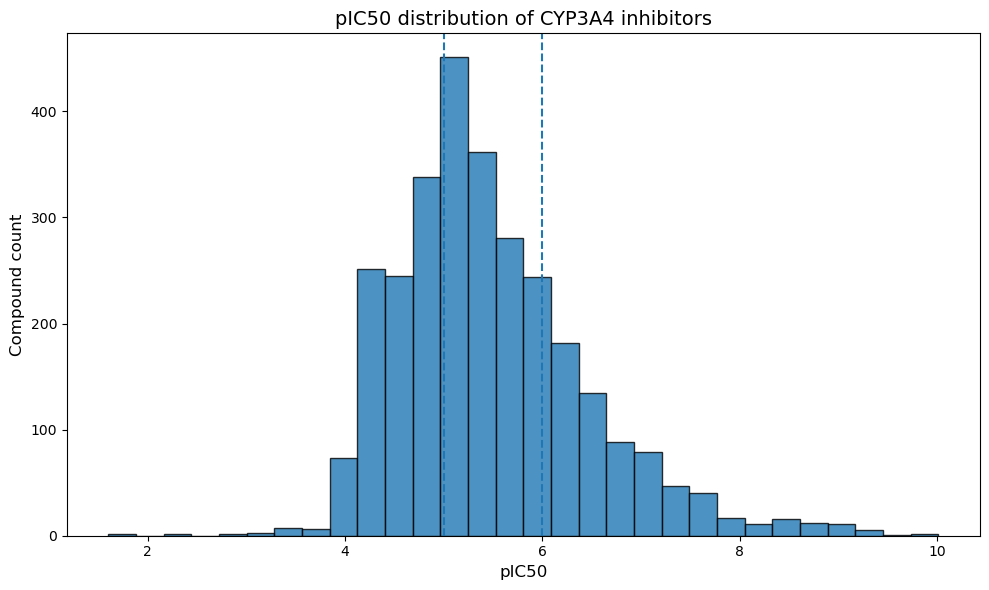

In [47]:
# PIC50 distribution histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    merged_dedup["pIC50"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# threshold lines
plt.axvline(5, linestyle="--", linewidth=1.5)
plt.axvline(6, linestyle="--", linewidth=1.5)

plt.title("pIC50 distribution of CYP3A4 inhibitors", fontsize=14)
plt.xlabel("pIC50", fontsize=12)
plt.ylabel("Compound count", fontsize=12)

plt.tight_layout()
plt.show()

In [48]:
# Class labeling

def classify_pic50(x):
    if x >= 6:
        return "Active"
    elif x <= 5:
        return "Inactive"
    else:
        return "Intermediate"

merged_dedup["Activity_Class"] = merged_dedup["pIC50"].apply(
    classify_pic50
)

print(merged_dedup["Activity_Class"].value_counts())
merged_dedup.head()

Activity_Class
Intermediate    1157
Inactive        1016
Active           740
Name: count, dtype: int64


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,None,10.016825,Active
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,None,9.744727,Active
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,None,9.522879,Active
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,None,9.397940,Active
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,None,9.301030,Active


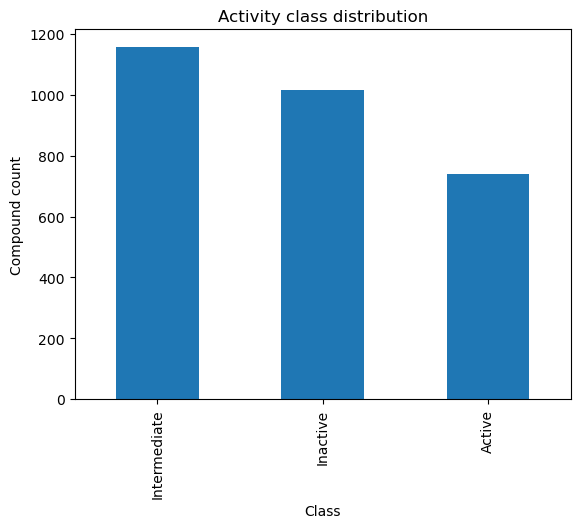

In [49]:
merged_dedup["Activity_Class"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Compound count")
plt.title("Activity class distribution")
plt.show()

In [50]:
class_table = merged_dedup["Activity_Class"].value_counts().reset_index()
class_table.columns = ["Class", "Count"]

print(class_table)

          Class  Count
0  Intermediate   1157
1      Inactive   1016
2        Active    740


In [51]:
class_percent = (
    merged_dedup["Activity_Class"]
    .value_counts(normalize=True) * 100
).round(2)

print(class_percent)

Activity_Class
Intermediate    39.72
Inactive        34.88
Active          25.40
Name: proportion, dtype: float64


In [52]:
binary_data = merged_dedup[
    merged_dedup["Activity_Class"] != "Intermediate"
].copy()

print("After removing intermediate:", binary_data.shape)
print(binary_data["Activity_Class"].value_counts())

After removing intermediate: (1756, 7)
Activity_Class
Inactive    1016
Active       740
Name: count, dtype: int64


In [53]:
binary_data["Label"] = binary_data["Activity_Class"].map({
    "Inactive": 0,
    "Active": 1
})

print(binary_data["Label"].value_counts())
binary_data.head()

Label
0    1016
1     740
Name: count, dtype: int64


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,None,10.016825,Active,1
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,None,9.744727,Active,1
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,None,9.522879,Active,1
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,None,9.397940,Active,1
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,None,9.301030,Active,1


In [54]:
binary_data.to_csv(
    "cyp3a4_binary_final_dataset.csv",
    index=False
)

print("✅ Binary final dataset saved")
print(binary_data.shape)

✅ Binary final dataset saved
(1756, 8)


Feature Engineering

In [55]:
# 1. ECFP4 2048 bit

from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd

# smiles → mol
binary_data["Mol"] = binary_data["SMILES"].apply(
    lambda x: Chem.MolFromSmiles(x)
)

# generate Morgan fingerprint
def mol_to_ecfp4(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )
    return list(fp)

# create fingerprint dataframe
X = pd.DataFrame(
    binary_data["Mol"].apply(mol_to_ecfp4).tolist()
)

# label
y = binary_data["Label"]

print("Feature matrix:", X.shape)
print("Label vector:", y.shape)

[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerator
[21:56:30] DEPRECATION WARNING: please use MorganGenerat

Feature matrix: (1756, 2048)
Label vector: (1756,)


In [56]:
X.columns = [f"Bit_{i}" for i in range(2048)]

In [57]:
binary_data.head()

,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label,Mol
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,None,10.016825,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,None,9.744727,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,None,9.522879,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,None,9.397940,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,None,9.301030,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...


In [58]:
X.head()


,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
fp_data = pd.concat(
    [
        binary_data.reset_index(drop=True),
        X.reset_index(drop=True)
    ],
    axis=1
)

print("Final fingerprint dataset:", fp_data.shape)
fp_data.head()

Final fingerprint dataset: (1756, 2057)


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label,Mol,Bit_0,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,None,10.016825,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,None,9.744727,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,None,9.522879,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,None,9.397940,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,1,0,0,0,0
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,None,9.301030,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
fp_data.to_csv(
    "cyp3a4_binary_ecfp4_2048_dataset.csv",
    index=False
)

print("✅ Final ECFP4 dataset saved")

✅ Final ECFP4 dataset saved


generate descriptor

In [61]:
from rdkit.Chem import Descriptors, rdMolDescriptors, QED
import pandas as pd
import numpy as np

def calculate_descriptors(mol):
    heavy_atoms = Descriptors.HeavyAtomCount(mol)

    return pd.Series({
        "MW": Descriptors.MolWt(mol),
        "SlogP": Descriptors.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "MolarRefractivity": Descriptors.MolMR(mol),
        "QED": QED.qed(mol),
        "HeteroatomRatio": (
            rdMolDescriptors.CalcNumHeteroatoms(mol) / heavy_atoms
            if heavy_atoms > 0 else 0
        )
    })

descriptor_data = binary_data["Mol"].apply(calculate_descriptors)

print("Descriptor matrix:", descriptor_data.shape)
descriptor_data.head()

Descriptor matrix: (1756, 11)


,MW,SlogP,TPSA,HBA,HBD,RotatableBonds,AromaticRings,FractionCsp3,MolarRefractivity,QED,HeteroatomRatio
0,580.574,6.52350,91.75,4.0,1.0,8.0,2.0,0.517241,150.2606,0.383821,0.236842
1,531.440,4.20580,69.06,6.0,0.0,7.0,3.0,0.384615,137.5960,0.455414,0.277778
2,472.007,2.32850,88.18,6.0,1.0,5.0,1.0,0.666667,116.5985,0.708678,0.322581
3,493.995,3.98662,117.27,6.0,5.0,6.0,4.0,0.307692,139.2427,0.277118,0.257143
4,530.087,2.42330,99.62,7.0,1.0,7.0,1.0,0.708333,131.8716,0.578727,0.314286


In [62]:
descriptor_full = pd.concat(
    [
        binary_data.reset_index(drop=True),
        descriptor_data.reset_index(drop=True)
    ],
    axis=1
)

print("Final descriptor dataset:", descriptor_full.shape)
descriptor_full.head()

Final descriptor dataset: (1756, 20)


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label,Mol,MW,SlogP,TPSA,HBA,HBD,RotatableBonds,AromaticRings,FractionCsp3,MolarRefractivity,QED,HeteroatomRatio
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,None,10.016825,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,580.574,6.52350,91.75,4.0,1.0,8.0,2.0,0.517241,150.2606,0.383821,0.236842
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,None,9.744727,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,531.440,4.20580,69.06,6.0,0.0,7.0,3.0,0.384615,137.5960,0.455414,0.277778
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,None,9.522879,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,472.007,2.32850,88.18,6.0,1.0,5.0,1.0,0.666667,116.5985,0.708678,0.322581
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,None,9.397940,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,493.995,3.98662,117.27,6.0,5.0,6.0,4.0,0.307692,139.2427,0.277118,0.257143
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,None,9.301030,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,530.087,2.42330,99.62,7.0,1.0,7.0,1.0,0.708333,131.8716,0.578727,0.314286


In [63]:
descriptor_full.to_csv(
    "cyp3a4_binary_descriptor_dataset.csv",
    index=False
)

print("✅ Descriptor dataset saved")

✅ Descriptor dataset saved


UMAP

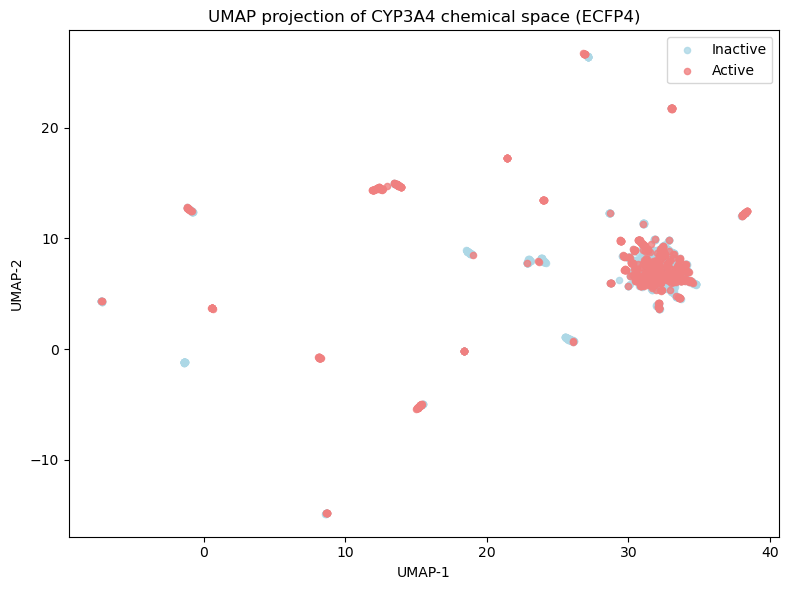

In [65]:
# 1. UMAP fingerprint

plt.figure(figsize=(8, 6))

for label, color, name in [
    (0, "lightblue", "Inactive"),
    (1, "lightcoral", "Active")
]:
    idx = binary_data["Label"] == label
    plt.scatter(
        X_umap_fp[idx, 0],
        X_umap_fp[idx, 1],
        color=color,
        s=20,
        alpha=0.8,
        label=name
    )

plt.title("UMAP projection of CYP3A4 chemical space (ECFP4)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
import umap.umap_ as umap

umap_desc = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap_desc = umap_desc.fit_transform(descriptor_data)

print(X_umap_desc.shape)

C:\Users\daffa\anaconda3\envs\project_internship_della\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(1756, 2)


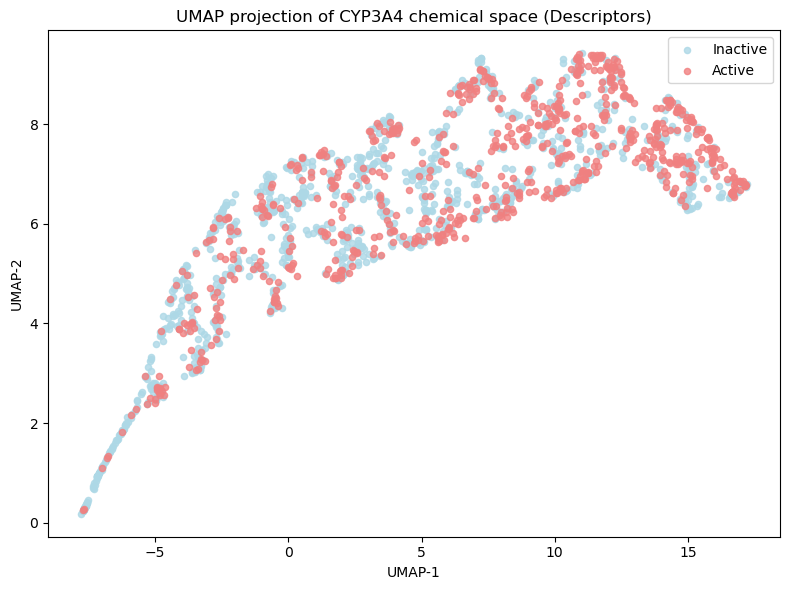

In [68]:
# 2. UMAP descriptor

plt.figure(figsize=(8, 6))

for label, color, name in [
    (0, "lightblue", "Inactive"),
    (1, "lightcoral", "Active")
]:
    idx = binary_data["Label"] == label
    plt.scatter(
        X_umap_desc[idx, 0],
        X_umap_desc[idx, 1],
        color=color,
        s=20,
        alpha=0.8,
        label=name
    )

plt.title("UMAP projection of CYP3A4 chemical space (Descriptors)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
data split

In [73]:
X_features = pd.concat(
    [
        X.reset_index(drop=True),
        descriptor_data.reset_index(drop=True)
    ],
    axis=1
)

y = y.reset_index(drop=True)

print("Final feature shape:", X_features.shape)
X_features.head()

Final feature shape: (1756, 2059)


,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,SlogP,TPSA,HBA,HBD,RotatableBonds,AromaticRings,FractionCsp3,MolarRefractivity,QED,HeteroatomRatio
0,0,1,0,0,0,0,0,0,0,0,...,6.52350,91.75,4.0,1.0,8.0,2.0,0.517241,150.2606,0.383821,0.236842
1,0,0,0,0,0,0,0,0,0,0,...,4.20580,69.06,6.0,0.0,7.0,3.0,0.384615,137.5960,0.455414,0.277778
2,0,1,0,0,0,0,0,0,0,0,...,2.32850,88.18,6.0,1.0,5.0,1.0,0.666667,116.5985,0.708678,0.322581
3,0,1,0,0,0,0,0,0,0,0,...,3.98662,117.27,6.0,5.0,6.0,4.0,0.307692,139.2427,0.277118,0.257143
4,0,0,0,0,0,0,0,0,0,0,...,2.42330,99.62,7.0,1.0,7.0,1.0,0.708333,131.8716,0.578727,0.314286


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train shape: (1404, 2059)
Test shape: (352, 2059)

Train class distribution:
Label
0    812
1    592
Name: count, dtype: int64

Test class distribution:
Label
0    204
1    148
Name: count, dtype: int64


baseline

In [75]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import make_scorer, matthews_corrcoef
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

models = {
    "ET": ExtraTreesClassifier(random_state=42),
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LGBM": LGBMClassifier(random_state=42)
}

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

results = []

for name, model in tqdm(models.items(), desc="Baseline models"):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "ROC_AUC": np.mean(scores["test_roc_auc"]),
        "Accuracy": np.mean(scores["test_accuracy"]),
        "F1": np.mean(scores["test_f1"]),
        "Precision": np.mean(scores["test_precision"]),
        "Recall": np.mean(scores["test_recall"]),
        "MCC": np.mean(scores["test_mcc"])
    })

baseline_cv = pd.DataFrame(results)
baseline_cv = baseline_cv.sort_values("F1", ascending=False)

baseline_cv

Baseline models:   0%|          | 0/4 [00:00<?, ?it/s]

,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
3,LGBM,0.921028,0.853282,0.821218,0.847830,0.798946,0.699640
2,XGB,0.911912,0.847595,0.812694,0.845913,0.783763,0.687033
1,RF,0.927199,0.839748,0.796088,0.859823,0.741590,0.670468
0,ET,0.925272,0.839049,0.795106,0.857889,0.741604,0.668943


tuning LGBM - Random

In [76]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from tqdm.auto import tqdm
import pandas as pd

lgbm = LGBMClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 10, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best F1 CV:", random_search.best_score_)
print("Best params:")
print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3243
[LightGBM] [Info] Number of data points in the train set: 1404, number of used features: 817
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421652 -> initscore=-0.315994
[LightGBM] [Info] Start training from score -0.315994
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

In [77]:
random_results = pd.DataFrame(random_search.cv_results_)

random_results = random_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_learning_rate",
    "param_num_leaves",
    "param_max_depth",
    "param_subsample",
    "param_colsample_bytree"
]].sort_values("rank_test_score")

random_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_learning_rate,param_num_leaves,param_max_depth,param_subsample,param_colsample_bytree
12,0.826128,1,300,0.10,15,10,0.8,0.8
26,0.825966,2,300,0.03,127,10,0.9,0.8
25,0.825938,3,100,0.10,127,-1,1.0,0.7
7,0.823234,4,300,0.03,31,-1,1.0,0.9
6,0.823208,5,500,0.03,15,15,1.0,0.9
16,0.822549,6,200,0.05,63,10,0.8,0.9
21,0.822499,7,300,0.10,63,5,0.9,0.7
18,0.822464,8,300,0.10,63,-1,1.0,1.0
10,0.821102,9,500,0.05,15,5,0.8,0.7
22,0.820780,10,800,0.10,127,15,0.9,0.8


In [78]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np

# rank 1 best model
best_model = random_search.best_estimator_

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

scores = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

rank1_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores["test_roc_auc"])],
    "Accuracy": [np.mean(scores["test_accuracy"])],
    "F1": [np.mean(scores["test_f1"])],
    "Precision": [np.mean(scores["test_precision"])],
    "Recall": [np.mean(scores["test_recall"])],
    "MCC": [np.mean(scores["test_mcc"])]
})

rank1_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.916987,0.856851,0.826128,0.849502,0.805711,0.706431


hyperparameter tuning - grid

In [79]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [8, 10, 12],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Grid F1 CV:", grid_search.best_score_)
print("Best Grid params:")
print(grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3243
[LightGBM] [Info] Number of data points in the train set: 1404, number of used features: 817
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421652 -> initscore=-0.315994
[LightGBM] [Info] Start training from score -0.315994
Best Grid F1 CV: 0.8293644701669258
Best Grid params:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 12, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.8}


In [80]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results = grid_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_learning_rate",
    "param_num_leaves",
    "param_max_depth",
    "param_subsample",
    "param_colsample_bytree"
]].sort_values("rank_test_score")

grid_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_learning_rate,param_num_leaves,param_max_depth,param_subsample,param_colsample_bytree
96,0.829364,1,300,0.10,15,12,0.8,0.8
97,0.829364,1,300,0.10,15,12,0.9,0.8
156,0.828835,3,400,0.05,15,12,0.8,0.9
157,0.828835,3,400,0.05,15,12,0.9,0.9
92,0.828287,5,200,0.10,31,12,0.8,0.8
93,0.828287,5,200,0.10,31,12,0.9,0.8
90,0.828083,7,200,0.10,15,12,0.8,0.8
91,0.828083,7,200,0.10,15,12,0.9,0.8
46,0.827847,9,300,0.05,63,12,0.8,0.8
47,0.827847,9,300,0.05,63,12,0.9,0.8


In [92]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
import numpy as np
import pandas as pd

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

scores_lgbm_grid = cross_validate(
    grid_search.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

lgbm_grid_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_lgbm_grid["test_roc_auc"])],
    "Accuracy": [np.mean(scores_lgbm_grid["test_accuracy"])],
    "F1": [np.mean(scores_lgbm_grid["test_f1"])],
    "Precision": [np.mean(scores_lgbm_grid["test_precision"])],
    "Recall": [np.mean(scores_lgbm_grid["test_recall"])],
    "MCC": [np.mean(scores_lgbm_grid["test_mcc"])]
})

lgbm_grid_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.917333,0.858976,0.829364,0.848449,0.812463,0.710646


final test set

In [81]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix
)
import pandas as pd

# ambil best model dari grid
best_lgbm = grid_search.best_estimator_

# fit full training set
best_lgbm.fit(X_train, y_train)

# predict test
y_pred = best_lgbm.predict(X_test)
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

# final metrics
lgbm_test_result = pd.DataFrame({
    "ROC_AUC": [roc_auc_score(y_test, y_prob)],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "F1": [f1_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "MCC": [matthews_corrcoef(y_test, y_pred)]
})

print("LGBM Final Test Result")
lgbm_test_result

[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3243
[LightGBM] [Info] Number of data points in the train set: 1404, number of used features: 817
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421652 -> initscore=-0.315994
[LightGBM] [Info] Start training from score -0.315994
LGBM Final Test Result


,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.932664,0.872159,0.842105,0.875912,0.810811,0.736522


In [83]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[187  17]
 [ 28 120]]


In [84]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 187
FP: 17
FN: 28
TP: 120


In [85]:
cm_table = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Inactive", "Actual Active"],
    columns=["Pred Inactive", "Pred Active"]
)

cm_table

,Pred Inactive,Pred Active
Actual Inactive,187,17
Actual Active,28,120


In [93]:
lgbm_summary = pd.DataFrame({
    "Stage": ["Baseline CV", "Random CV", "Grid CV", "Final Test"],
    "ROC_AUC": [
        0.921028,
        0.921028,   
        0.917333,
        0.932664
    ],
    "Accuracy": [
        0.853282,
        0.853282,   
        0.858976,
        0.872159
    ],
    "F1": [
        0.821218,
        0.826128,
        0.829364,
        0.842105
    ],
    "Precision": [
        0.847830,
        0.847830,
        0.848449,
        0.875912
    ],
    "Recall": [
        0.798946,
        0.798946,
        0.812463,
        0.810811
    ],
    "MCC": [
        0.699640,
        0.699640,
        0.710646,
        0.736522
    ]
})

lgbm_summary

,Stage,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,Baseline CV,0.921028,0.853282,0.821218,0.847830,0.798946,0.699640
1,Random CV,0.921028,0.853282,0.826128,0.847830,0.798946,0.699640
2,Grid CV,0.917333,0.858976,0.829364,0.848449,0.812463,0.710646
3,Final Test,0.932664,0.872159,0.842105,0.875912,0.810811,0.736522


Hyperparameter tuning XGB - random

In [86]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

print("Best XGB Random F1:", random_search_xgb.best_score_)
print("Best params:")
print(random_search_xgb.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB Random F1: 0.8185929113814773
Best params:
{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [87]:
xgb_random_results = pd.DataFrame(random_search_xgb.cv_results_)

xgb_random_results = xgb_random_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_subsample",
    "param_colsample_bytree",
    "param_min_child_weight"
]].sort_values("rank_test_score")

xgb_random_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_colsample_bytree,param_min_child_weight
19,0.818593,1,500,0.05,5,1.0,0.8,1
16,0.814454,2,300,0.10,10,1.0,0.8,3
29,0.814448,3,300,0.03,7,0.9,0.8,3
17,0.813624,4,200,0.05,10,0.8,1.0,3
23,0.813139,5,300,0.05,5,1.0,0.7,3
2,0.812501,6,300,0.03,10,0.9,0.8,3
5,0.810627,7,300,0.10,5,0.8,0.9,1
26,0.809530,8,300,0.10,10,1.0,0.7,3
8,0.807610,9,300,0.03,7,0.9,0.7,5
7,0.801386,10,200,0.05,5,0.9,0.8,5


In [94]:
scores_xgb_random = cross_validate(
    random_search_xgb.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

xgb_random_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_xgb_random["test_roc_auc"])],
    "Accuracy": [np.mean(scores_xgb_random["test_accuracy"])],
    "F1": [np.mean(scores_xgb_random["test_f1"])],
    "Precision": [np.mean(scores_xgb_random["test_precision"])],
    "Recall": [np.mean(scores_xgb_random["test_recall"])],
    "MCC": [np.mean(scores_xgb_random["test_mcc"])]
})

xgb_random_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.917506,0.853289,0.818593,0.856514,0.785429,0.69861


Hyperparameter tuning GBM - Grid 

In [88]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [5, 7, 10],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.8, 0.9],
    "min_child_weight": [1, 3]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print("Best Grid XGB F1:", grid_search_xgb.best_score_)
print("Best params:")
print(grid_search_xgb.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Grid XGB F1: 0.8268350691176778
Best params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 700, 'subsample': 1.0}


In [89]:
xgb_grid_results = pd.DataFrame(grid_search_xgb.cv_results_)

xgb_grid_results = xgb_grid_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_subsample",
    "param_colsample_bytree",
    "param_min_child_weight"
]].sort_values("rank_test_score")

xgb_grid_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_colsample_bytree,param_min_child_weight
53,0.826835,1,700,0.05,7,1.0,0.8,1
161,0.825297,2,700,0.05,7,1.0,0.9,1
85,0.823618,3,300,0.10,7,1.0,0.8,1
148,0.823387,4,700,0.05,5,0.9,0.9,1
14,0.823173,5,500,0.03,7,0.9,0.8,1
124,0.823026,6,700,0.03,7,0.9,0.9,1
159,0.822822,7,500,0.05,7,1.0,0.9,1
183,0.822521,8,500,0.10,5,1.0,0.9,1
16,0.821902,9,700,0.03,7,0.9,0.8,1
61,0.821619,10,300,0.05,10,1.0,0.8,1


In [95]:
scores_xgb_grid = cross_validate(
    grid_search_xgb.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

xgb_grid_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_xgb_grid["test_roc_auc"])],
    "Accuracy": [np.mean(scores_xgb_grid["test_accuracy"])],
    "F1": [np.mean(scores_xgb_grid["test_f1"])],
    "Precision": [np.mean(scores_xgb_grid["test_precision"])],
    "Recall": [np.mean(scores_xgb_grid["test_recall"])],
    "MCC": [np.mean(scores_xgb_grid["test_mcc"])]
})

xgb_grid_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.919336,0.858277,0.826835,0.856509,0.800669,0.709217


final test set XGB

In [90]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix
)
import pandas as pd

best_xgb = grid_search_xgb.best_estimator_

# train full 80%
best_xgb.fit(X_train, y_train)

# predict 20%
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_test_result = pd.DataFrame({
    "ROC_AUC": [roc_auc_score(y_test, y_prob_xgb)],
    "Accuracy": [accuracy_score(y_test, y_pred_xgb)],
    "F1": [f1_score(y_test, y_pred_xgb)],
    "Precision": [precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_xgb)],
    "MCC": [matthews_corrcoef(y_test, y_pred_xgb)]
})

print("XGB Final Test Result")
xgb_test_result

XGB Final Test Result


,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.936838,0.857955,0.821429,0.871212,0.777027,0.707319


In [91]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 187
FP: 17
FN: 33
TP: 115


In [96]:
xgb_summary = pd.DataFrame({
    "Stage": ["Baseline CV", "Random CV", "Grid CV", "Final Test"],
    "ROC_AUC": [
        0.911912,
        0.917506,
        0.919336,
        0.936838
    ],
    "Accuracy": [
        0.847595,
        0.853289,
        0.858277,
        0.857955
    ],
    "F1": [
        0.812694,
        0.818593,
        0.826835,
        0.821429
    ],
    "Precision": [
        0.845913,
        0.856514,
        0.856509,
        0.871212
    ],
    "Recall": [
        0.783763,
        0.785429,
        0.800669,
        0.777027
    ],
    "MCC": [
        0.687033,
        0.698610,
        0.709217,
        0.707319
    ]
})

xgb_summary

,Stage,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,Baseline CV,0.911912,0.847595,0.812694,0.845913,0.783763,0.687033
1,Random CV,0.917506,0.853289,0.818593,0.856514,0.785429,0.698610
2,Grid CV,0.919336,0.858277,0.826835,0.856509,0.800669,0.709217
3,Final Test,0.936838,0.857955,0.821429,0.871212,0.777027,0.707319


In [97]:
# table final model
final_model_summary = pd.DataFrame({
    "Model": ["LGBM", "XGB"],
    "ROC_AUC": [0.932664, 0.936838],
    "Accuracy": [0.872159, 0.857955],
    "F1": [0.842105, 0.821429],
    "Precision": [0.875912, 0.871212],
    "Recall": [0.810811, 0.777027],
    "MCC": [0.736522, 0.707319]
})

final_model_summary = final_model_summary.sort_values("F1", ascending=False)

final_model_summary

,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,LGBM,0.932664,0.872159,0.842105,0.875912,0.810811,0.736522
1,XGB,0.936838,0.857955,0.821429,0.871212,0.777027,0.707319


Hyperperameter tuning RF - random

In [98]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_rf = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best RF Random F1:", random_search_rf.best_score_)
print("Best params:")
print(random_search_rf.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF Random F1: 0.8237481170174508
Best params:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


In [99]:
rf_random_results = pd.DataFrame(random_search_rf.cv_results_)

rf_random_results = rf_random_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features"
]].sort_values("rank_test_score")

rf_random_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
18,0.823748,1,100,None,2,1,None
11,0.818452,2,500,20,5,1,None
6,0.812147,3,700,20,10,1,None
27,0.810893,4,500,15,5,2,None
25,0.810224,5,500,None,10,2,None
8,0.810010,6,300,20,2,4,None
2,0.805561,7,500,20,10,4,None
26,0.797652,8,100,20,10,4,None
4,0.797341,9,300,10,2,2,None
0,0.793378,10,200,10,5,4,None


In [100]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
import numpy as np
import pandas as pd

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

scores_rf_random = cross_validate(
    random_search_rf.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

rf_random_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_rf_random["test_roc_auc"])],
    "Accuracy": [np.mean(scores_rf_random["test_accuracy"])],
    "F1": [np.mean(scores_rf_random["test_f1"])],
    "Precision": [np.mean(scores_rf_random["test_precision"])],
    "Recall": [np.mean(scores_rf_random["test_recall"])],
    "MCC": [np.mean(scores_rf_random["test_mcc"])]
})

rf_random_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.928962,0.858277,0.823748,0.869023,0.785458,0.709836


hyperparameter tuning RF - grid

In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [None]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best RF Grid F1:", grid_search_rf.best_score_)
print("Best params:")
print(grid_search_rf.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Grid F1: 0.8253081265555963
Best params:
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [102]:
rf_grid_results = pd.DataFrame(grid_search_rf.cv_results_)

rf_grid_results = rf_grid_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features"
]].sort_values("rank_test_score")

rf_grid_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
3,0.825308,1,100,None,5,1,None
12,0.824950,2,100,20,2,1,None
0,0.823748,3,100,None,2,1,None
4,0.822622,4,200,None,5,1,None
5,0.822265,5,300,None,5,1,None
14,0.821809,6,300,20,2,1,None
2,0.821639,7,300,None,2,1,None
17,0.819436,8,300,20,5,1,None
13,0.819415,9,200,20,2,1,None
16,0.819360,10,200,20,5,1,None


In [103]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
import numpy as np
import pandas as pd

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

scores_rf_grid = cross_validate(
    grid_search_rf.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

rf_grid_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_rf_grid["test_roc_auc"])],
    "Accuracy": [np.mean(scores_rf_grid["test_accuracy"])],
    "F1": [np.mean(scores_rf_grid["test_f1"])],
    "Precision": [np.mean(scores_rf_grid["test_precision"])],
    "Recall": [np.mean(scores_rf_grid["test_recall"])],
    "MCC": [np.mean(scores_rf_grid["test_mcc"])]
})

rf_grid_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.928647,0.858271,0.825308,0.861773,0.79389,0.709402


In [104]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix
)
import pandas as pd

best_rf = grid_search_rf.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

rf_test_result = pd.DataFrame({
    "ROC_AUC": [roc_auc_score(y_test, y_prob_rf)],
    "Accuracy": [accuracy_score(y_test, y_pred_rf)],
    "F1": [f1_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_rf)],
    "MCC": [matthews_corrcoef(y_test, y_pred_rf)]
})

rf_test_result

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.934022,0.860795,0.823105,0.883721,0.77027,0.713789


In [105]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

tn, fp, fn, tp = cm_rf.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 189
FP: 15
FN: 34
TP: 114


In [106]:
rf_summary = pd.DataFrame({
    "Stage": ["Baseline CV", "Random CV", "Grid CV", "Final Test"],
    "ROC_AUC": [
        0.927199,
        0.928962,
        0.928647,
        0.934022
    ],
    "Accuracy": [
        0.839748,
        0.858277,
        0.858271,
        0.860795
    ],
    "F1": [
        0.796088,
        0.823748,
        0.825308,
        0.823105
    ],
    "Precision": [
        0.859823,
        0.869023,
        0.861773,
        0.883721
    ],
    "Recall": [
        0.741590,
        0.785458,
        0.793890,
        0.770270
    ],
    "MCC": [
        0.670468,
        0.709836,
        0.709402,
        0.713789
    ]
})

rf_summary

,Stage,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,Baseline CV,0.927199,0.839748,0.796088,0.859823,0.741590,0.670468
1,Random CV,0.928962,0.858277,0.823748,0.869023,0.785458,0.709836
2,Grid CV,0.928647,0.858271,0.825308,0.861773,0.793890,0.709402
3,Final Test,0.934022,0.860795,0.823105,0.883721,0.770270,0.713789


In [107]:
final_model_summary = pd.DataFrame({
    "Model": ["LGBM", "XGB", "RF"],
    "ROC_AUC": [0.932664, 0.936838, 0.934022],
    "Accuracy": [0.872159, 0.857955, 0.860795],
    "F1": [0.842105, 0.821429, 0.823105],
    "Precision": [0.875912, 0.871212, 0.883721],
    "Recall": [0.810811, 0.777027, 0.770270],
    "MCC": [0.736522, 0.707319, 0.713789]
}).sort_values("F1", ascending=False)

final_model_summary

,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,LGBM,0.932664,0.872159,0.842105,0.875912,0.810811,0.736522
2,RF,0.934022,0.860795,0.823105,0.883721,0.770270,0.713789
1,XGB,0.936838,0.857955,0.821429,0.871212,0.777027,0.707319


hyperparameter tuning ET - random

In [108]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_et = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search_et = RandomizedSearchCV(
    estimator=et,
    param_distributions=param_dist_et,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_et.fit(X_train, y_train)

print("Best ET Random F1:", random_search_et.best_score_)
print("Best params:")
print(random_search_et.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ET Random F1: 0.795146236283677
Best params:
{'n_estimators': 700, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [109]:
et_random_results = pd.DataFrame(random_search_et.cv_results_)

et_random_results = et_random_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features"
]].sort_values("rank_test_score")

et_random_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
5,0.795146,1,700,None,5,1,log2
3,0.777955,2,200,20,2,1,sqrt
10,0.775653,3,100,None,10,1,log2
18,0.775368,4,100,None,2,1,None
25,0.775020,5,500,None,10,2,None
11,0.771965,6,500,20,5,1,None
6,0.770753,7,700,20,10,1,None
22,0.770750,8,300,20,5,1,sqrt
27,0.764720,9,500,15,5,2,None
2,0.764608,10,500,20,10,4,None


In [110]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
import numpy as np
import pandas as pd

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

scores_et_random = cross_validate(
    random_search_et.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

et_random_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_et_random["test_roc_auc"])],
    "Accuracy": [np.mean(scores_et_random["test_accuracy"])],
    "F1": [np.mean(scores_et_random["test_f1"])],
    "Precision": [np.mean(scores_et_random["test_precision"])],
    "Recall": [np.mean(scores_et_random["test_recall"])],
    "MCC": [np.mean(scores_et_random["test_mcc"])]
})

et_random_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.922872,0.841884,0.795146,0.877474,0.728087,0.676607


Hyperparameter tuning ET - grid

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier

param_grid_et = {
    "n_estimators": [500, 700],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2", None]
}

grid_search_et = GridSearchCV(
    estimator=ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_et,
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_et.fit(X_train, y_train)

print("Best ET Grid F1:", grid_search_et.best_score_)
print("Best params:")
print(grid_search_et.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [112]:
print("kernel alive")

kernel alive


In [113]:
print("Best ET Grid F1:", grid_search_et.best_score_)
print("Best params:")
print(grid_search_et.best_params_)

Best ET Grid F1: 0.8026061837436181
Best params:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [114]:
et_grid_results = pd.DataFrame(grid_search_et.cv_results_)

et_grid_results = et_grid_results[[
    "mean_test_score",
    "rank_test_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features"
]].sort_values("rank_test_score")

et_grid_results.head(10)

,mean_test_score,rank_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
0,0.802606,1,500,None,2,1,sqrt
1,0.802361,2,700,None,2,1,sqrt
12,0.799810,3,500,None,2,1,log2
2,0.799554,4,500,None,5,1,sqrt
13,0.798998,5,700,None,2,1,log2
3,0.798137,6,700,None,5,1,sqrt
15,0.795146,7,700,None,5,1,log2
4,0.793058,8,500,None,10,1,sqrt
14,0.792488,9,500,None,5,1,log2
5,0.787622,10,700,None,10,1,sqrt


In [115]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
import numpy as np
import pandas as pd

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "mcc": make_scorer(matthews_corrcoef)
}

scores_et_grid = cross_validate(
    grid_search_et.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

et_grid_metrics = pd.DataFrame({
    "ROC_AUC": [np.mean(scores_et_grid["test_roc_auc"])],
    "Accuracy": [np.mean(scores_et_grid["test_accuracy"])],
    "F1": [np.mean(scores_et_grid["test_f1"])],
    "Precision": [np.mean(scores_et_grid["test_precision"])],
    "Recall": [np.mean(scores_et_grid["test_recall"])],
    "MCC": [np.mean(scores_et_grid["test_mcc"])]
})

et_grid_metrics

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.927333,0.844034,0.802606,0.860136,0.75344,0.679383


In [ ]:
final test set ET

In [116]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix
)

best_et = grid_search_et.best_estimator_

best_et.fit(X_train, y_train)

y_pred_et = best_et.predict(X_test)
y_prob_et = best_et.predict_proba(X_test)[:, 1]

et_test_result = pd.DataFrame({
    "ROC_AUC": [roc_auc_score(y_test, y_prob_et)],
    "Accuracy": [accuracy_score(y_test, y_pred_et)],
    "F1": [f1_score(y_test, y_pred_et)],
    "Precision": [precision_score(y_test, y_pred_et)],
    "Recall": [recall_score(y_test, y_pred_et)],
    "MCC": [matthews_corrcoef(y_test, y_pred_et)]
})

et_test_result

,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,0.945681,0.877841,0.844765,0.906977,0.790541,0.749621


In [117]:
cm_et = confusion_matrix(y_test, y_pred_et)

tn, fp, fn, tp = cm_et.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 192
FP: 12
FN: 31
TP: 117


In [118]:
et_summary = pd.DataFrame({
    "Stage": ["Baseline CV", "Random CV", "Grid CV", "Final Test"],
    "ROC_AUC": [
        0.925272,
        0.922872,
        0.927333,
        0.945681
    ],
    "Accuracy": [
        0.839049,
        0.841884,
        0.844034,
        0.877841
    ],
    "F1": [
        0.795106,
        0.795146,
        0.802606,
        0.844765
    ],
    "Precision": [
        0.857889,
        0.877474,
        0.860136,
        0.906977
    ],
    "Recall": [
        0.741604,
        0.728807,
        0.753440,
        0.790541
    ],
    "MCC": [
        0.668943,
        0.676607,
        0.679383,
        0.749621
    ]
})

et_summary

,Stage,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,Baseline CV,0.925272,0.839049,0.795106,0.857889,0.741604,0.668943
1,Random CV,0.922872,0.841884,0.795146,0.877474,0.728807,0.676607
2,Grid CV,0.927333,0.844034,0.802606,0.860136,0.753440,0.679383
3,Final Test,0.945681,0.877841,0.844765,0.906977,0.790541,0.749621


In [119]:
final_model_summary = pd.DataFrame({
    "Model": ["ET", "LGBM", "RF", "XGB"],
    "ROC_AUC": [0.945681, 0.932664, 0.934022, 0.936838],
    "Accuracy": [0.877841, 0.872159, 0.860795, 0.857955],
    "F1": [0.844765, 0.842105, 0.823105, 0.821429],
    "Precision": [0.906977, 0.875912, 0.883721, 0.871212],
    "Recall": [0.790541, 0.810811, 0.770270, 0.777027],
    "MCC": [0.749621, 0.736522, 0.713789, 0.707319]
}).sort_values("F1", ascending=False)

final_model_summary

,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,ET,0.945681,0.877841,0.844765,0.906977,0.790541,0.749621
1,LGBM,0.932664,0.872159,0.842105,0.875912,0.810811,0.736522
2,RF,0.934022,0.860795,0.823105,0.883721,0.770270,0.713789
3,XGB,0.936838,0.857955,0.821429,0.871212,0.777027,0.707319


In [120]:
import joblib
import pandas as pd

# =========================
# SAVE MODELS
# =========================
joblib.dump(best_et, "ET_best_CYP3A4_model.pkl")
joblib.dump(best_lgbm, "LGBM_best_model.pkl")
joblib.dump(best_xgb, "XGB_best_model.pkl")
joblib.dump(best_rf, "RF_best_model.pkl")

# =========================
# SAVE FEATURE INFO
# =========================
joblib.dump(X_train.columns.tolist(), "feature_names_2059.pkl")

# =========================
# SAVE TRAIN/TEST DATA
# =========================
X_train.to_csv("X_train_hybrid.csv", index=False)
X_test.to_csv("X_test_hybrid.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# =========================
# SAVE FINAL LEADERBOARD
# =========================
final_model_summary.to_csv("final_model_summary.csv", index=False)

print("✅ COMPLETE CYP3A4 package saved successfully")

✅ COMPLETE CYP3A4 package saved successfully


In [1]:
import joblib
import pandas as pd

best_et = joblib.load("ET_best_CYP3A4_model.pkl")
feature_names = joblib.load("feature_names_2059.pkl")

X_train = pd.read_csv("X_train_hybrid.csv")
X_test = pd.read_csv("X_test_hybrid.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("✅ ET champion ready")
print("X_train:", X_train.shape)

✅ ET champion ready
X_train: (1404, 2059)


global feature importance

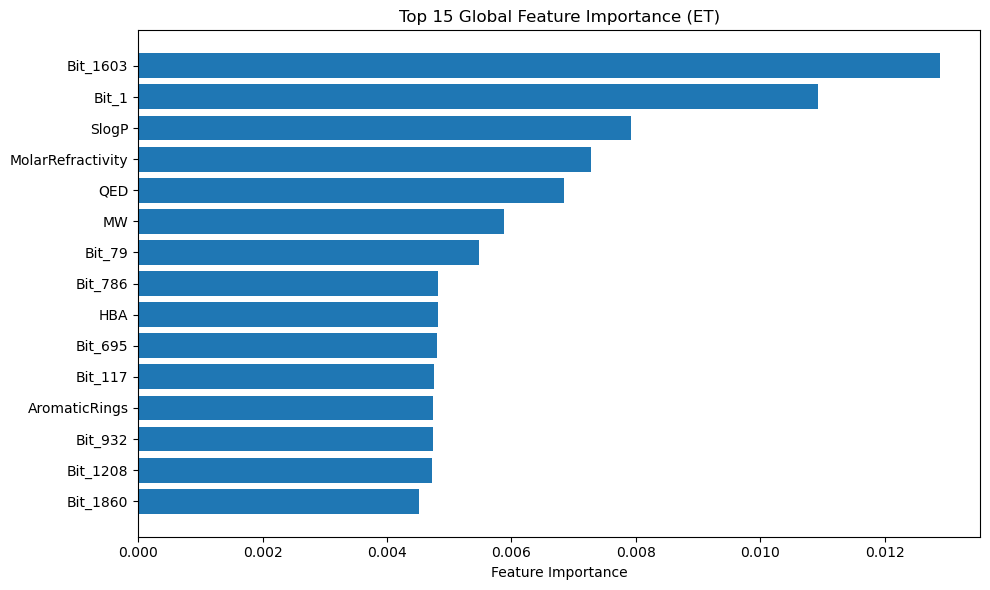

,Feature,Importance
1603,Bit_1603,0.012889
1,Bit_1,0.010928
2049,SlogP,0.007927
2056,MolarRefractivity,0.007275
2057,QED,0.006837
2048,MW,0.005880
79,Bit_79,0.005481
786,Bit_786,0.004822
2051,HBA,0.004814
695,Bit_695,0.004795


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# native ET importance
importances = best_et.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

top15 = feat_imp.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"][::-1], top15["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Global Feature Importance (ET)")
plt.tight_layout()
plt.show()

top15

SHAP

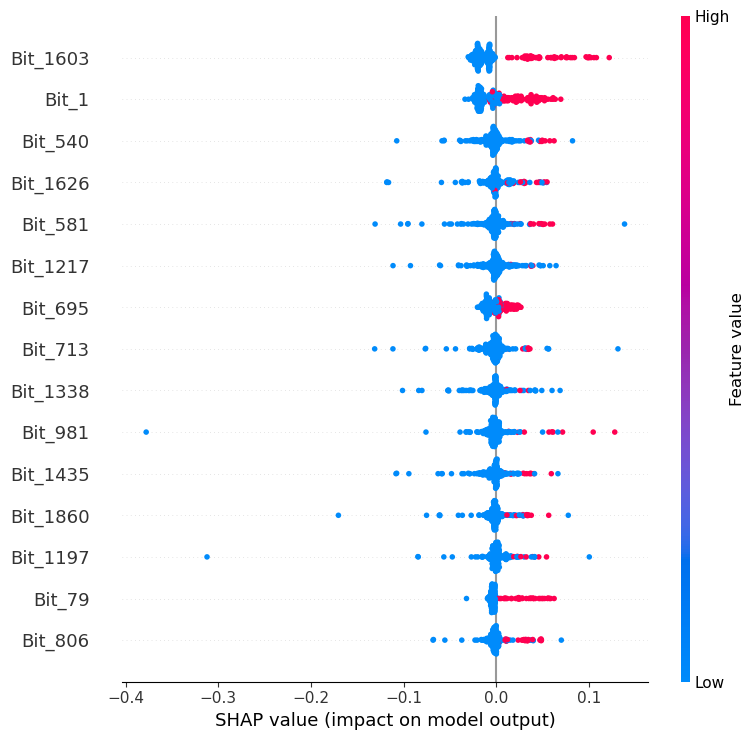

In [4]:
import shap
import numpy as np

# sample subset biar lebih cepat
X_shap = X_train.sample(300, random_state=42)

explainer = shap.TreeExplainer(best_et)

shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

# handle output shape
if isinstance(shap_values, list):
    shap_plot_values = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_plot_values = shap_values[:, :, 1]
else:
    shap_plot_values = shap_values

shap.summary_plot(
    shap_plot_values,
    X_shap,
    max_display=15
)

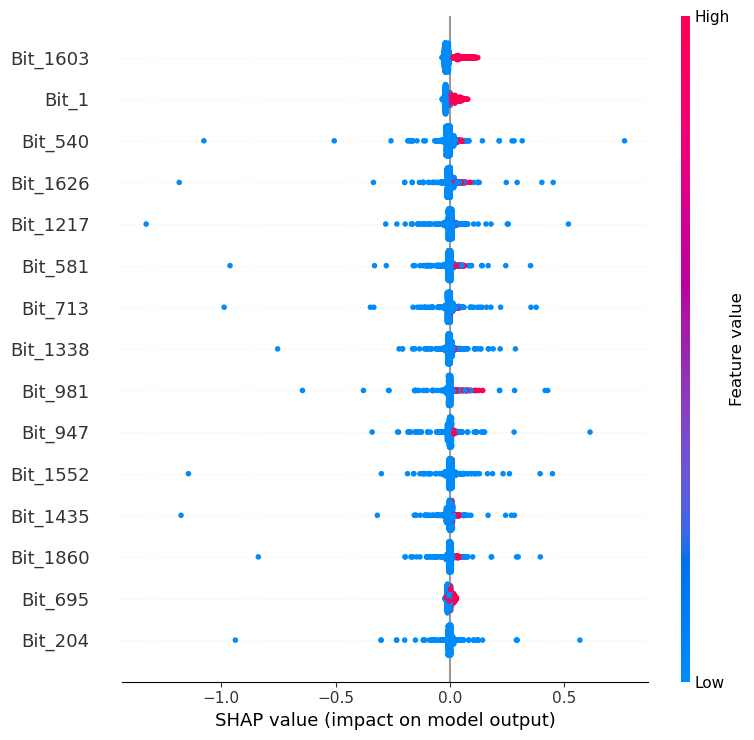

In [5]:
import shap
import numpy as np

explainer = shap.TreeExplainer(best_et)

shap_values = explainer.shap_values(
    X_train,
    check_additivity=False
)

# handle output shape
if isinstance(shap_values, list):
    shap_plot_values = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_plot_values = shap_values[:, :, 1]
else:
    shap_plot_values = shap_values

shap.summary_plot(
    shap_plot_values,
    X_train,
    max_display=15
)

In [6]:
df = pd.read_csv("cyp3a4_binary_final_dataset.csv")
df.head()

,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,NaN,10.016825,Active,1
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,NaN,9.744727,Active,1
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,NaN,9.522879,Active,1
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,NaN,9.397940,Active,1
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,NaN,9.301030,Active,1


In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947]

bit_fragments = []

for bit in top_bits:
    found = False
    
    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
            
        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=2, nBits=2048, bitInfo=bitInfo
        )
        
        if bit in bitInfo:
            bit_fragments.append((mol, bit, bitInfo))
            found = True
            break
    
    if not found:
        bit_fragments.append(None)

print("Fragments found:", len([x for x in bit_fragments if x is not None]))

[19:28:42] DEPRECATION WARNING: please use MorganGenerator
[19:28:42] DEPRECATION WARNING: please use MorganGenerator
[19:28:42] DEPRECATION WARNING: please use MorganGenerator
[19:28:42] DEPRECATION WARNING: please use MorganGenerator
[19:28:42] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerat

Fragments found: 10


[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerator
[19:28:43] DEPRECATION WARNING: please use MorganGenerat

[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerator
[19:30:37] DEPRECATION WARNING: please use MorganGenerat

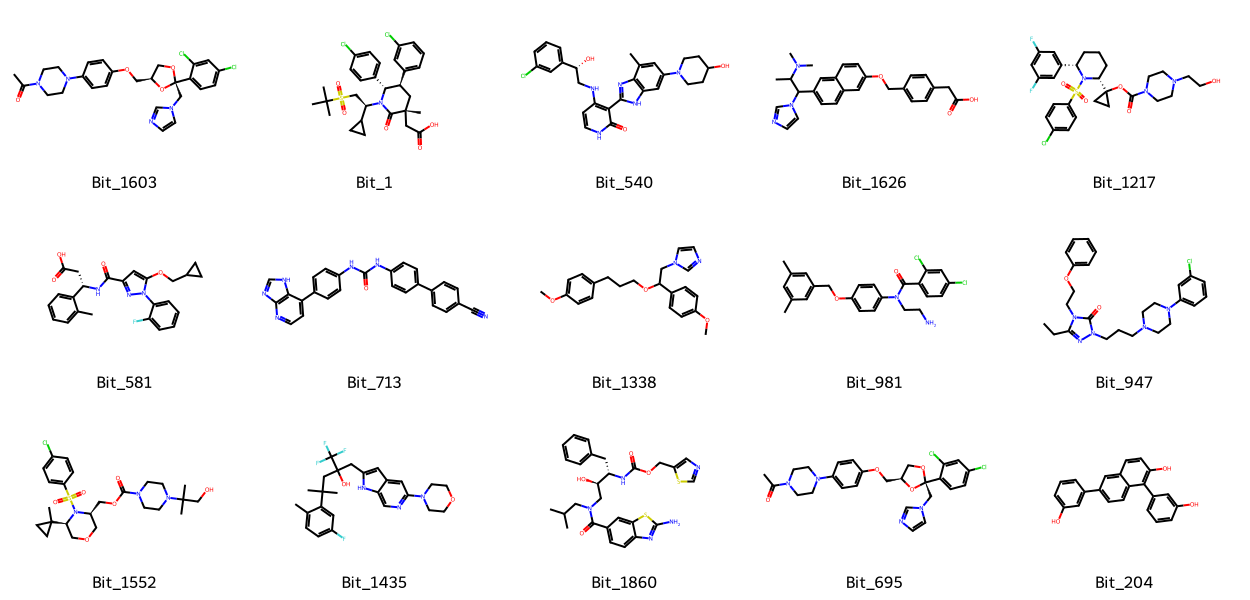

In [8]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import pandas as pd

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

fragment_mols = []
legends = []

for bit in top_bits:
    found = False
    
    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
            
        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bitInfo
        )
        
        if bit in bitInfo:
            fragment_mols.append(mol)
            legends.append(f"Bit_{bit}")
            found = True
            break
    
    if not found:
        fragment_mols.append(Chem.MolFromSmiles("C"))
        legends.append(f"Bit_{bit}")

img = Draw.MolsToGridImage(
    fragment_mols,
    molsPerRow=5,
    subImgSize=(250, 200),
    legends=legends
)

img

[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerator
[19:34:24] DEPRECATION WARNING: please use MorganGenerat

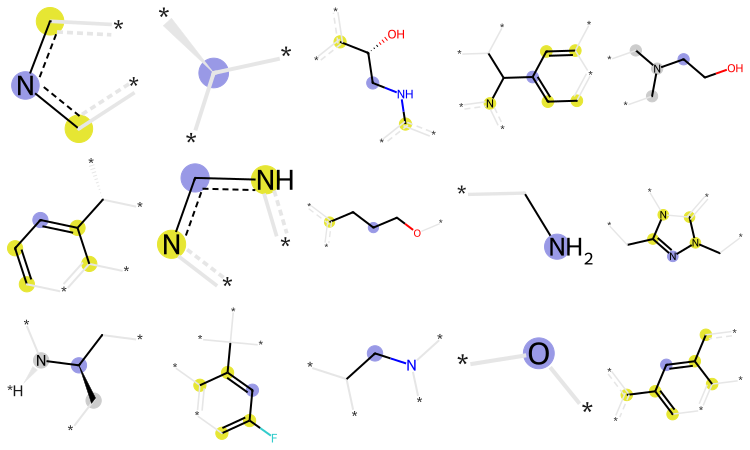

In [9]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import pandas as pd
from PIL import Image, ImageOps, ImageDraw, ImageFont
import math

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

imgs = []

for bit in top_bits:
    found = False
    
    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bitInfo
        )

        if bit in bitInfo:
            img = Draw.DrawMorganBit(
                mol,
                bit,
                bitInfo,
                useSVG=False
            )
            imgs.append(img)
            found = True
            break
    
    if not found:
        imgs.append(Image.new("RGB", (250, 200), "white"))

# ===== combine into 3x5 grid =====
cols = 5
rows = math.ceil(len(imgs) / cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerator
[19:36:56] DEPRECATION WARNING: please use MorganGenerat

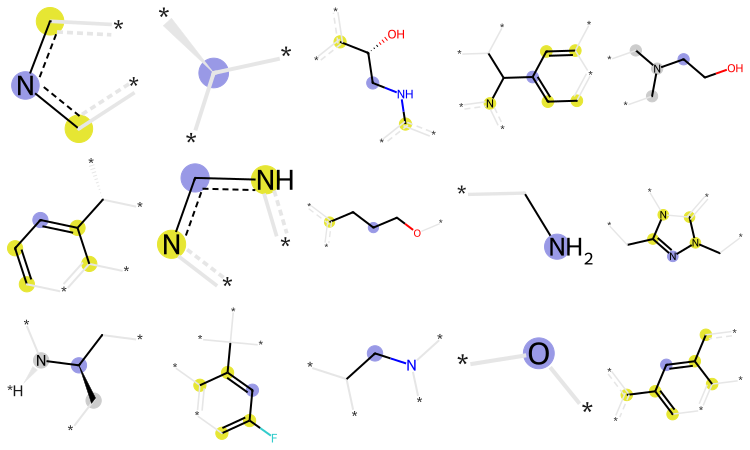

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from PIL import Image
import pandas as pd
import math

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

imgs = []

for bit in top_bits:
    found = False
    
    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bitInfo
        )

        if bit in bitInfo:
            img = Draw.DrawMorganBit(
                mol,
                bit,
                bitInfo,
                useSVG=False
            )
            imgs.append(img)
            found = True
            break
    
    if not found:
        imgs.append(Image.new("RGB", (250, 200), "white"))

# grid 3x5
cols = 5
rows = math.ceil(len(imgs) / cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerator
[19:40:28] DEPRECATION WARNING: please use MorganGenerat

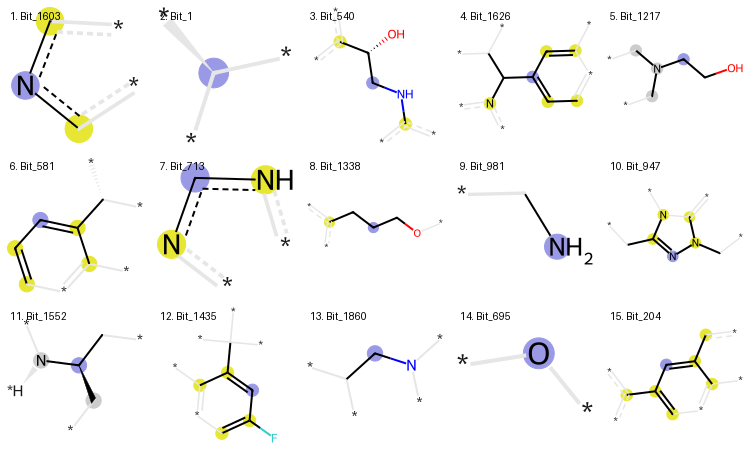

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
import math

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

imgs = []

for idx, bit in enumerate(top_bits, 1):
    found = False
    
    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bitInfo
        )

        if bit in bitInfo:
            img = Draw.DrawMorganBit(
                mol,
                bit,
                bitInfo,
                useSVG=False
            ).convert("RGB")

            # add text label
            draw = ImageDraw.Draw(img)
            draw.text((10, 10), f"{idx}. Bit_{bit}", fill="black")

            imgs.append(img)
            found = True
            break

    if not found:
        blank = Image.new("RGB", (250, 200), "white")
        draw = ImageDraw.Draw(blank)
        draw.text((10, 10), f"{idx}. Bit_{bit}", fill="black")
        imgs.append(blank)

# combine grid
cols = 5
rows = math.ceil(len(imgs) / cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerator
[19:45:03] DEPRECATION WARNING: please use MorganGenerat

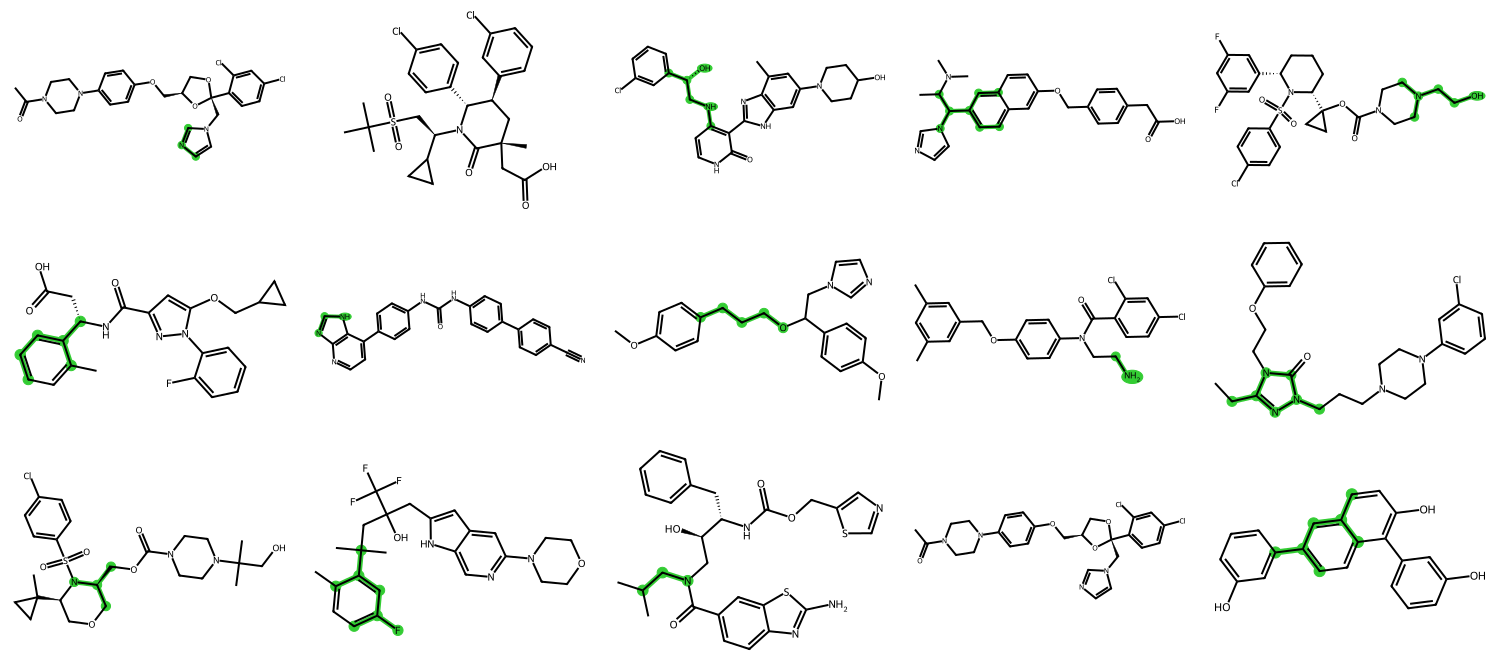

In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
import pandas as pd
import math

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

imgs = []

for bit in top_bits:
    found = False
    
    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=2, nBits=2048, bitInfo=bitInfo
        )

        if bit in bitInfo:
            atom_id, radius = bitInfo[bit][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)
            atoms = set()
            for bidx in env:
                bond = mol.GetBondWithIdx(bidx)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())

            drawer = rdMolDraw2D.MolDraw2DCairo(300, 220)
            opts = drawer.drawOptions()
            opts.useBWAtomPalette()  # all atoms black/gray
            
            drawer.DrawMolecule(
                mol,
                highlightAtoms=list(atoms),
                highlightAtomColors={a: (0.2, 0.8, 0.2) for a in atoms}
            )
            drawer.FinishDrawing()

            png = drawer.GetDrawingText()
            img = Image.open(io.BytesIO(png))
            imgs.append(img)
            found = True
            break

    if not found:
        imgs.append(Image.new("RGB", (300, 220), "white"))

# combine grid
cols = 5
rows = math.ceil(len(imgs)/cols)
w, h = imgs[0].size

grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerator
[19:50:11] DEPRECATION WARNING: please use MorganGenerat

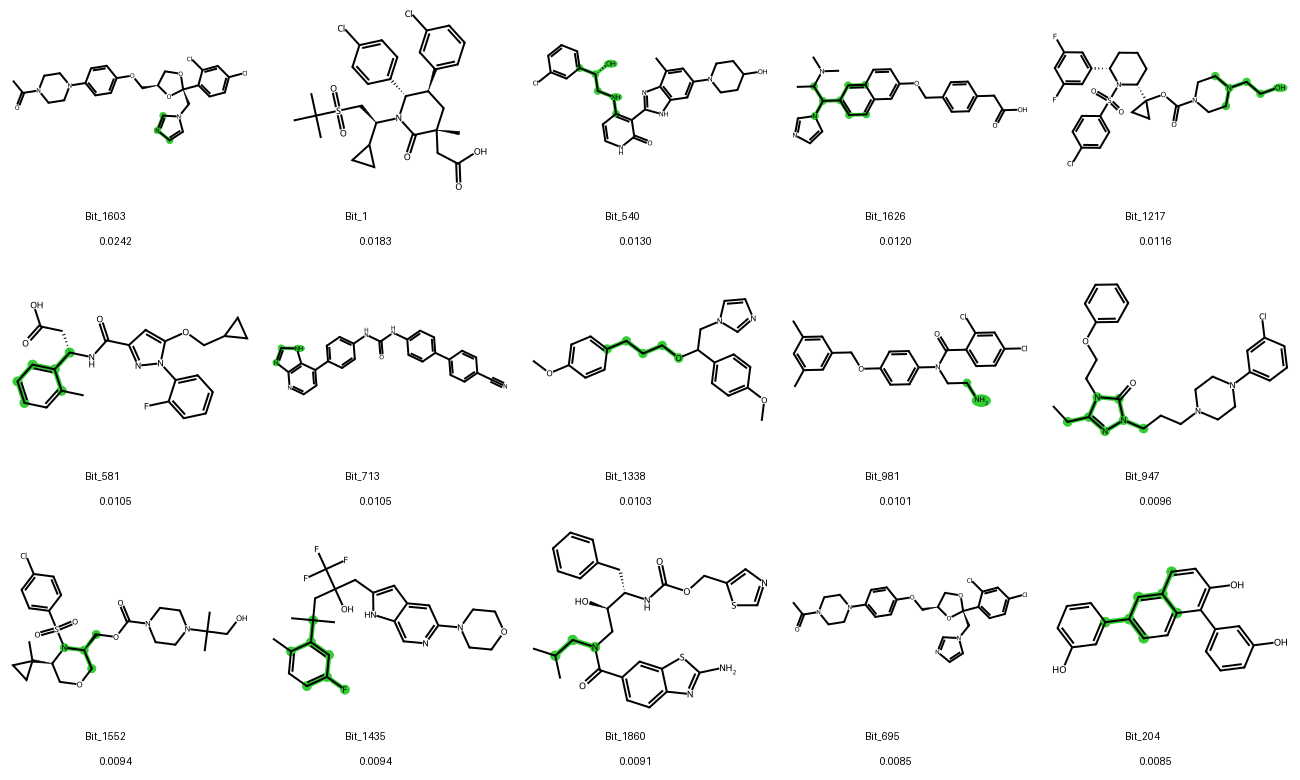

In [13]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image, ImageDraw
import io
import pandas as pd
import numpy as np
import math

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

# ===== top bits from SHAP =====
top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

# ===== calculate mean abs shap =====
shap_importance = np.abs(shap_plot_values).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MeanAbsSHAP": shap_importance
})

bit_scores = {}
for bit in top_bits:
    col_name = f"Bit_{bit}"
    score = shap_df.loc[shap_df["Feature"] == col_name, "MeanAbsSHAP"]
    bit_scores[bit] = float(score.iloc[0]) if len(score) > 0 else 0.0

imgs = []

for bit in top_bits:
    found = False

    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=2, nBits=2048, bitInfo=bitInfo
        )

        if bit in bitInfo:
            atom_id, radius = bitInfo[bit][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)

            atoms = set()
            for bidx in env:
                bond = mol.GetBondWithIdx(bidx)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())

            drawer = rdMolDraw2D.MolDraw2DCairo(260, 200)
            opts = drawer.drawOptions()
            opts.useBWAtomPalette()

            drawer.DrawMolecule(
                mol,
                highlightAtoms=list(atoms),
                highlightAtomColors={a: (0.2, 0.8, 0.2) for a in atoms}
            )
            drawer.FinishDrawing()

            png = drawer.GetDrawingText()
            img = Image.open(io.BytesIO(png)).convert("RGB")

            # ===== add label + shap score =====
            final_img = Image.new("RGB", (260, 260), "white")
            final_img.paste(img, (0, 0))

            draw = ImageDraw.Draw(final_img)
            draw.text((85, 210), f"Bit_{bit}", fill="black")
            draw.text((100, 235), f"{bit_scores[bit]:.4f}", fill="black")

            imgs.append(final_img)
            found = True
            break

    if not found:
        blank = Image.new("RGB", (260, 260), "white")
        draw = ImageDraw.Draw(blank)
        draw.text((85, 210), f"Bit_{bit}", fill="black")
        draw.text((100, 235), f"{bit_scores[bit]:.4f}", fill="black")
        imgs.append(blank)

# ===== combine grid =====
cols = 5
rows = math.ceil(len(imgs)/cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerator
[19:57:57] DEPRECATION WARNING: please use MorganGenerat

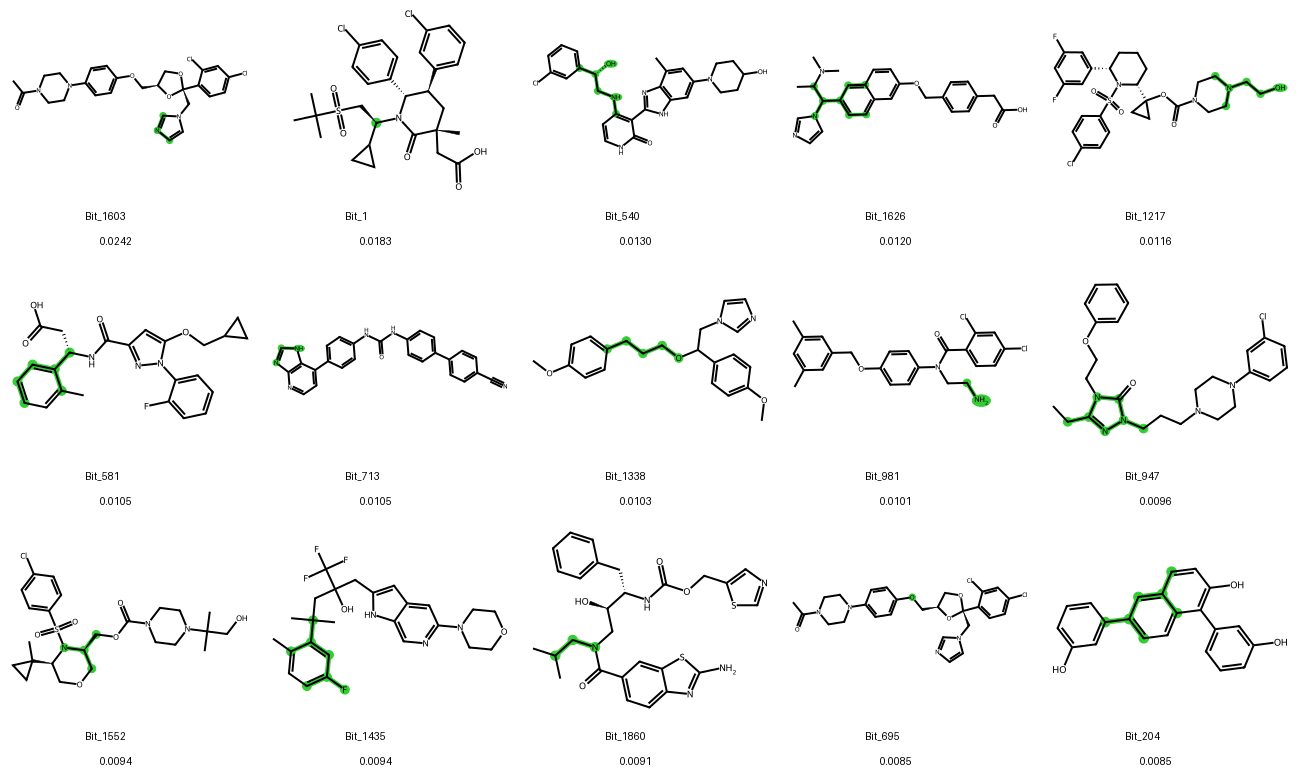

In [14]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image, ImageDraw
import io
import pandas as pd
import numpy as np
import math

df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

# ===== top bits from SHAP =====
top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

# ===== calculate mean abs shap =====
shap_importance = np.abs(shap_plot_values).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MeanAbsSHAP": shap_importance
})

bit_scores = {}
for bit in top_bits:
    col_name = f"Bit_{bit}"
    score = shap_df.loc[shap_df["Feature"] == col_name, "MeanAbsSHAP"]
    bit_scores[bit] = float(score.iloc[0]) if len(score) > 0 else 0.0

imgs = []

for bit in top_bits:
    found = False

    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bitInfo
        )

        if bit in bitInfo:
            atom_id, radius = bitInfo[bit][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)

            # ✅ FIX: always include center atom
            atoms = {atom_id}

            for bidx in env:
                bond = mol.GetBondWithIdx(bidx)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())

            drawer = rdMolDraw2D.MolDraw2DCairo(260, 200)
            opts = drawer.drawOptions()
            opts.useBWAtomPalette()

            drawer.DrawMolecule(
                mol,
                highlightAtoms=list(atoms),
                highlightAtomColors={a: (0.2, 0.8, 0.2) for a in atoms}
            )
            drawer.FinishDrawing()

            png = drawer.GetDrawingText()
            img = Image.open(io.BytesIO(png)).convert("RGB")

            # ===== add label + shap score =====
            final_img = Image.new("RGB", (260, 260), "white")
            final_img.paste(img, (0, 0))

            draw = ImageDraw.Draw(final_img)
            draw.text((85, 210), f"Bit_{bit}", fill="black")
            draw.text((100, 235), f"{bit_scores[bit]:.4f}", fill="black")

            imgs.append(final_img)
            found = True
            break

    if not found:
        blank = Image.new("RGB", (260, 260), "white")
        draw = ImageDraw.Draw(blank)
        draw.text((85, 210), f"Bit_{bit}", fill="black")
        draw.text((100, 235), f"{bit_scores[bit]:.4f}", fill="black")
        imgs.append(blank)

# ===== combine grid =====
cols = 5
rows = math.ceil(len(imgs) / cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols * w, rows * h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

top_bits = [1603, 1, 540, 1626, 1217, 581, 713, 1338, 981, 947, 1552, 1435, 1860, 695, 204]

# baseline active rate
baseline = y_train.mean()

sar_results = []

for bit in top_bits:
    col = f"Bit_{bit}"
    
    if col not in X_train.columns:
        continue
    
    present_mask = X_train[col] == 1
    
    if present_mask.sum() == 0:
        continue
    
    active_rate = y_train[present_mask].mean()
    delta = active_rate - baseline
    
    sar_results.append({
        "Bit": f"Bit_{bit}",
        "Delta_ActiveRate": delta,
        "ActiveRate": active_rate,
        "Count": present_mask.sum()
    })

sar_df = pd.DataFrame(sar_results).sort_values(
    "Delta_ActiveRate",
    ascending=False
)

sar_df

,Bit,Delta_ActiveRate,ActiveRate,Count
12,Bit_1860,0.520377,0.942029,69
2,Bit_540,0.476653,0.898305,59
9,Bit_947,0.475783,0.897436,78
3,Bit_1626,0.351932,0.773585,53
7,Bit_1338,0.328348,0.750000,16
6,Bit_713,0.323028,0.744681,47
10,Bit_1552,0.300570,0.722222,18
5,Bit_581,0.299278,0.720930,43
11,Bit_1435,0.272792,0.694444,36
4,Bit_1217,0.245014,0.666667,30


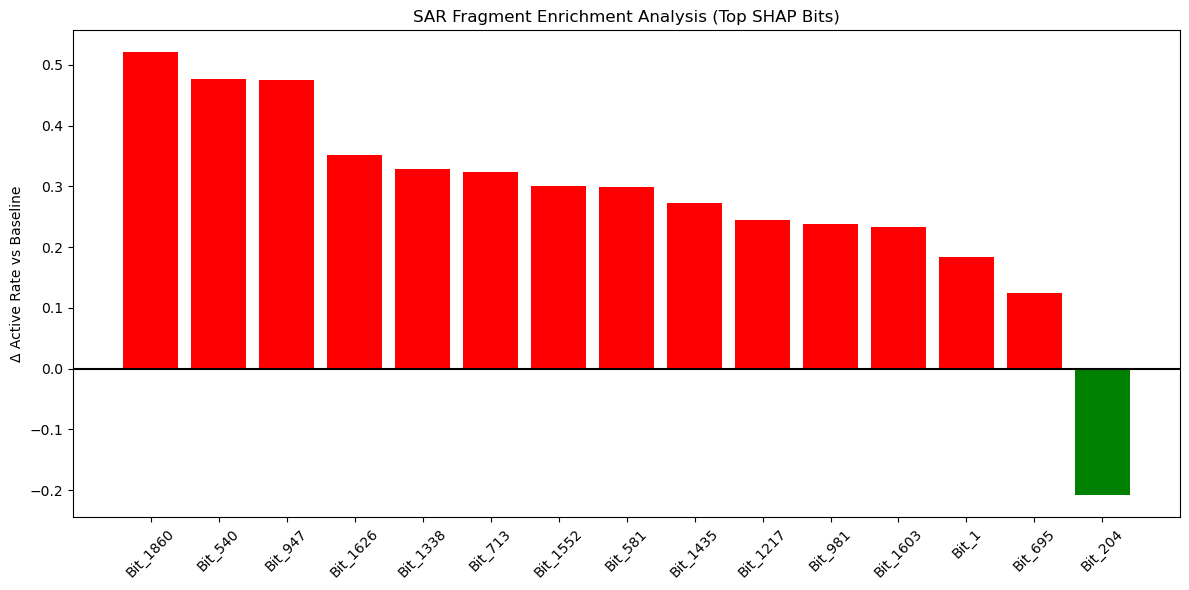

In [16]:
plt.figure(figsize=(12,6))

colors = ["red" if x > 0 else "green" for x in sar_df["Delta_ActiveRate"]]

plt.bar(
    sar_df["Bit"],
    sar_df["Delta_ActiveRate"],
    color=colors
)

plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.ylabel("Δ Active Rate vs Baseline")
plt.title("SAR Fragment Enrichment Analysis (Top SHAP Bits)")
plt.tight_layout()
plt.show()

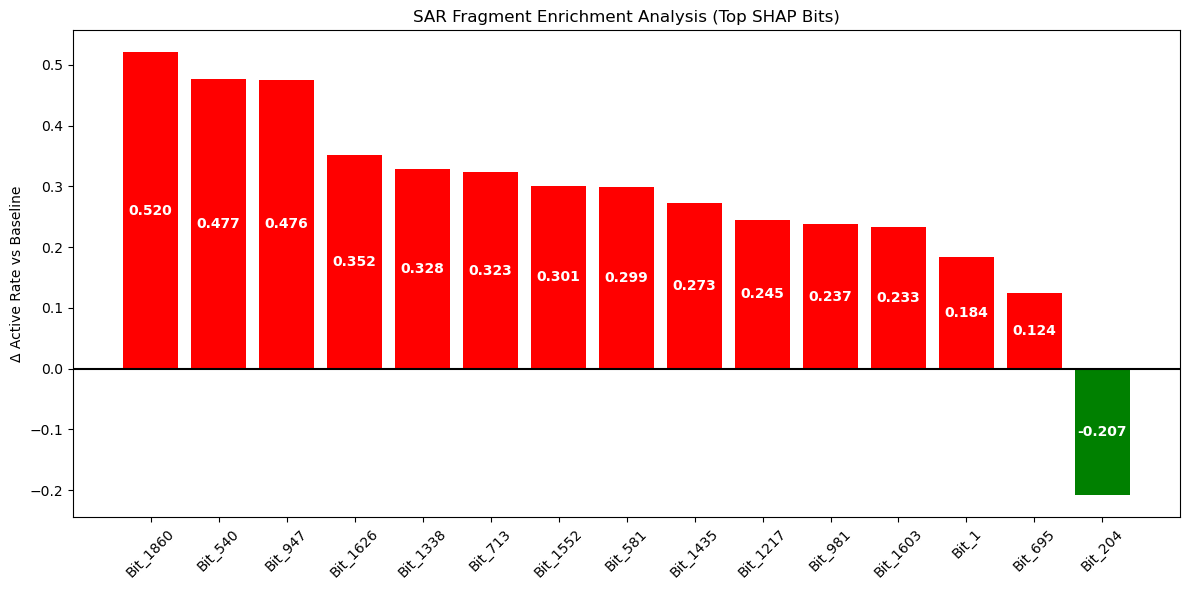

In [17]:
plt.figure(figsize=(12,6))

colors = ["red" if x > 0 else "green" for x in sar_df["Delta_ActiveRate"]]

bars = plt.bar(
    sar_df["Bit"],
    sar_df["Delta_ActiveRate"],
    color=colors
)

plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.ylabel("Δ Active Rate vs Baseline")
plt.title("SAR Fragment Enrichment Analysis (Top SHAP Bits)")

# ===== add values inside bars =====
for bar in bars:
    height = bar.get_height()
    
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height/2,
            f"{height:.3f}",
            ha="center",
            va="center",
            color="white",
            fontweight="bold"
        )
    else:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height/2,
            f"{height:.3f}",
            ha="center",
            va="center",
            color="white",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerator
[21:01:30] DEPRECATION WARNING: please use MorganGenerat

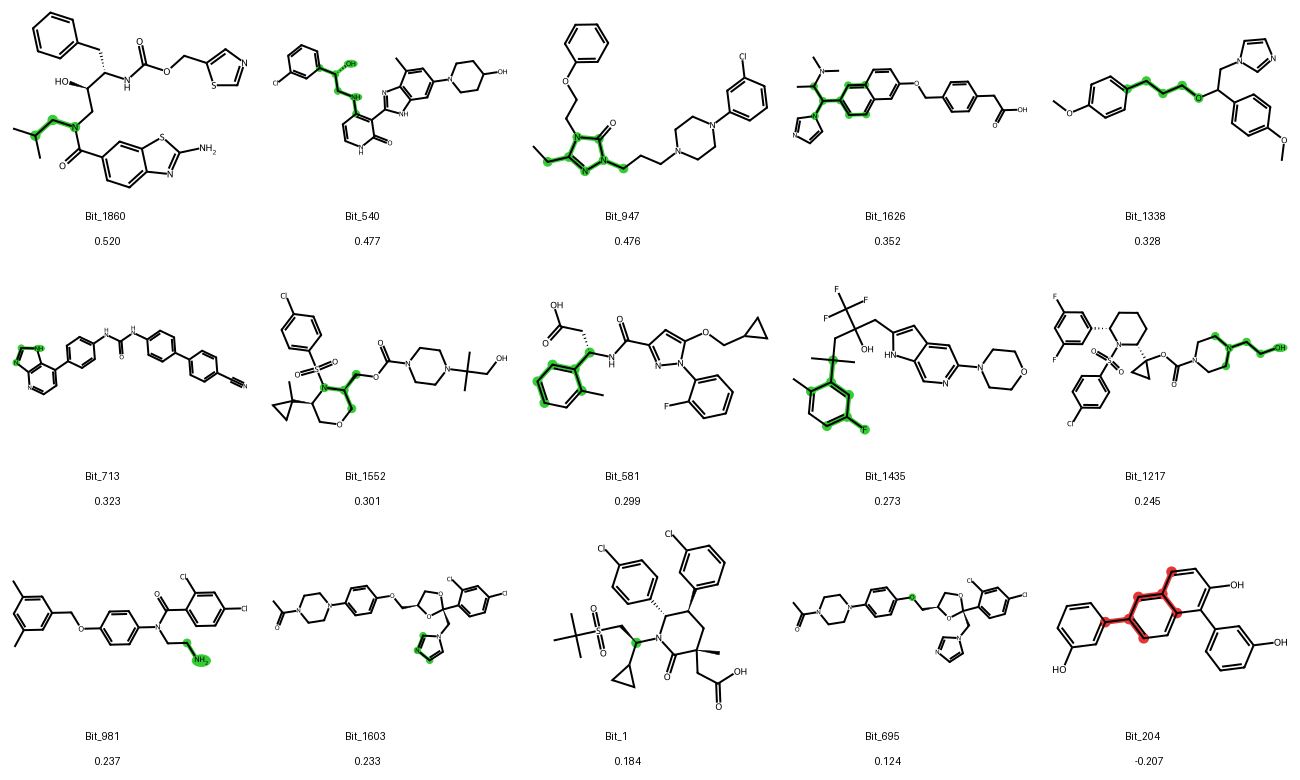

In [18]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image, ImageDraw
import io
import math

# ===== use SAR ranking =====
sar_top_bits = (
    sar_df.sort_values("Delta_ActiveRate", ascending=False)["Bit"]
    .str.replace("Bit_", "")
    .astype(int)
    .tolist()
)

bit_delta = dict(zip(
    sar_df["Bit"].str.replace("Bit_", "").astype(int),
    sar_df["Delta_ActiveRate"]
))

imgs = []

for bit in sar_top_bits:
    found = False

    for smi in df["SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bitInfo
        )

        if bit in bitInfo:
            atom_id, radius = bitInfo[bit][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)

            atoms = {atom_id}
            for bidx in env:
                bond = mol.GetBondWithIdx(bidx)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())

            # color by SAR sign
            delta = bit_delta[bit]
            color = (0.2, 0.8, 0.2) if delta > 0 else (0.9, 0.2, 0.2)

            drawer = rdMolDraw2D.MolDraw2DCairo(260, 200)
            opts = drawer.drawOptions()
            opts.useBWAtomPalette()

            drawer.DrawMolecule(
                mol,
                highlightAtoms=list(atoms),
                highlightAtomColors={a: color for a in atoms}
            )
            drawer.FinishDrawing()

            png = drawer.GetDrawingText()
            img = Image.open(io.BytesIO(png)).convert("RGB")

            final_img = Image.new("RGB", (260, 260), "white")
            final_img.paste(img, (0, 0))

            draw = ImageDraw.Draw(final_img)
            draw.text((85, 210), f"Bit_{bit}", fill="black")
            draw.text((95, 235), f"{delta:.3f}", fill="black")

            imgs.append(final_img)
            found = True
            break

# ===== combine grid =====
cols = 5
rows = math.ceil(len(imgs) / cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols * w, rows * h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

In [19]:
import numpy as np
import pandas as pd

# top 10 SAR bits or SHAP bits
top_bits = [1860, 540, 947, 1626, 1338, 713, 1552, 581, 1435, 1217]

# choose top active compounds from test set
probs = best_et.predict_proba(X_test)[:, 1]
top_idx = np.argsort(probs)[-10:]

occlusion_results = []

for idx in top_idx:
    sample = X_test.iloc[idx].copy()
    base_pred = best_et.predict_proba(sample.to_frame().T)[0,1]
    
    bit_impacts = {}
    
    for bit in top_bits:
        col = f"Bit_{bit}"
        if col not in sample.index:
            continue
        
        modified = sample.copy()
        modified[col] = 0
        
        new_pred = best_et.predict_proba(modified.to_frame().T)[0,1]
        delta = base_pred - new_pred
        
        bit_impacts[bit] = delta
    
    occlusion_results.append(bit_impacts)

occlusion_df = pd.DataFrame(occlusion_results)
occlusion_df

,1860,540,947,1626,1338,713,1552,581,1435,1217
0,0.044,0.000,0.016,0.0,0.0,0.0,0.0,0.0,0.000,0.0
1,0.000,0.000,0.010,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0
3,0.006,0.000,0.010,0.0,0.0,0.0,0.0,0.0,0.000,0.0
4,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.038,0.0
5,0.000,0.024,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0
6,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0
7,0.040,0.000,0.018,0.0,0.0,0.0,0.0,0.0,0.000,0.0
8,0.046,0.000,0.016,0.0,0.0,0.0,0.0,0.0,0.000,0.0
9,0.006,0.000,0.012,0.0,0.0,0.0,0.0,0.0,0.000,0.0


[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator
[21:09:56] DEPRECATION WARNING: please use MorganGenerator


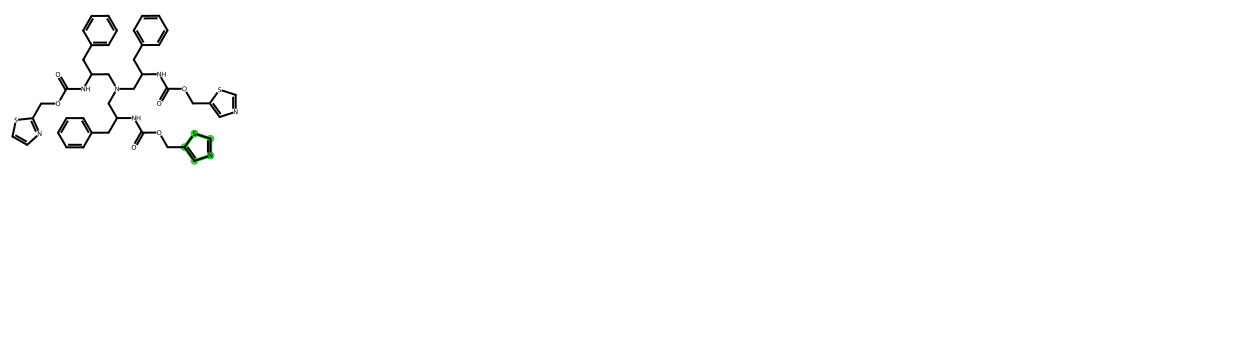

In [20]:
from PIL import Image, ImageDraw
import io, math
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D

imgs = []

for i, idx in enumerate(top_idx):
    smi = df.iloc[idx]["SMILES"]
    mol = Chem.MolFromSmiles(smi)
    
    sample = X_test.iloc[idx]
    impacts = occlusion_df.iloc[i].sort_values(ascending=False)
    best_bit = impacts.index[0]
    
    bit = int(best_bit)
    
    bitInfo = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048, bitInfo=bitInfo
    )
    
    if bit in bitInfo:
        atom_id, radius = bitInfo[bit][0]
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)

        atoms = {atom_id}
        for bidx in env:
            bond = mol.GetBondWithIdx(bidx)
            atoms.add(bond.GetBeginAtomIdx())
            atoms.add(bond.GetEndAtomIdx())

        delta = impacts.iloc[0]
        color = (0.2,0.8,0.2) if delta > 0 else (0.9,0.2,0.2)

        drawer = rdMolDraw2D.MolDraw2DCairo(250, 180)
        drawer.drawOptions().useBWAtomPalette()
        drawer.DrawMolecule(
            mol,
            highlightAtoms=list(atoms),
            highlightAtomColors={a: color for a in atoms}
        )
        drawer.FinishDrawing()

        img = Image.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB")
        imgs.append(img)

# combine
cols = 5
rows = 2
w, h = imgs[0].size
grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

In [21]:
import numpy as np
import pandas as pd

# probability active
probs = best_et.predict_proba(X_test)[:, 1]

# top 10 predicted active compounds
top_idx = np.argsort(probs)[-10:]
top_idx

array([294, 292, 290, 164, 165, 270, 177,  59, 313,  93])

In [24]:
top_bits = [1860, 540, 947, 1626, 1338, 713, 1552, 581, 1435, 1217]

compound_best_bits = []

for idx in top_idx:
    sample = X_test.iloc[idx].copy()
    base_pred = best_et.predict_proba(sample.to_frame().T)[0, 1]

    best_delta = 0
    best_bit = None

    for bit in top_bits:
        col = f"Bit_{bit}"
        if col not in sample.index:
            continue

        modified = sample.copy()
        modified[col] = 0

        new_pred = best_et.predict_proba(modified.to_frame().T)[0, 1]
        delta = base_pred - new_pred

        if abs(delta) > abs(best_delta):
            best_delta = delta
            best_bit = bit

    compound_best_bits.append((idx, best_bit, best_delta))

compound_best_bits

[(np.int64(294), 1860, np.float64(0.04400000000000004)),
 (np.int64(292), 947, np.float64(0.010000000000000009)),
 (np.int64(290), None, 0),
 (np.int64(164), 947, np.float64(0.010000000000000009)),
 (np.int64(165), 1435, np.float64(0.038000000000000034)),
 (np.int64(270), 540, np.float64(0.02400000000000002)),
 (np.int64(177), None, 0),
 (np.int64(59), 1860, np.float64(0.040000000000000036)),
 (np.int64(313), 1860, np.float64(0.04600000000000004)),
 (np.int64(93), 947, np.float64(0.01200000000000001))]

[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator
[21:28:02] DEPRECATION WARNING: please use MorganGenerator


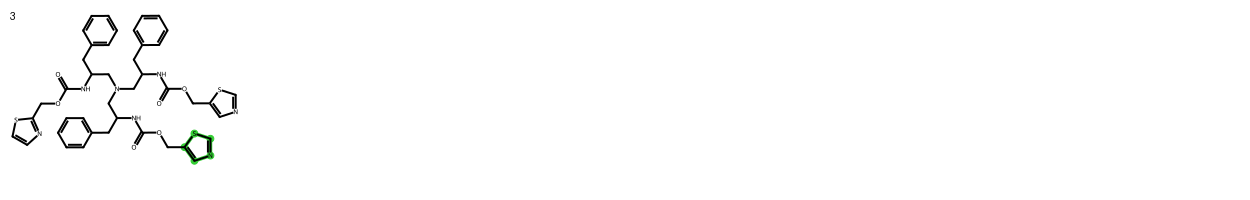

In [25]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image, ImageDraw
import io, math

imgs = []

valid_results = [x for x in compound_best_bits if x[1] is not None]

for rank, (idx, bit, delta) in enumerate(valid_results, 1):
    smi = df.iloc[idx]["SMILES"]
    mol = Chem.MolFromSmiles(smi)

    bitInfo = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048,
        bitInfo=bitInfo
    )

    if bit not in bitInfo:
        continue

    atom_id, radius = bitInfo[bit][0]
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)

    atoms = {atom_id}
    for bidx in env:
        bond = mol.GetBondWithIdx(bidx)
        atoms.add(bond.GetBeginAtomIdx())
        atoms.add(bond.GetEndAtomIdx())

    color = (0.2, 0.8, 0.2) if delta > 0 else (0.9, 0.2, 0.2)

    drawer = rdMolDraw2D.MolDraw2DCairo(250, 180)
    drawer.drawOptions().useBWAtomPalette()
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atoms),
        highlightAtomColors={a: color for a in atoms}
    )
    drawer.FinishDrawing()

    img = Image.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB")

    final_img = Image.new("RGB", (250, 200), "white")
    final_img.paste(img, (0, 0))

    draw = ImageDraw.Draw(final_img)
    draw.text((10, 10), str(rank), fill="black")

    imgs.append(final_img)

# ===== combine dynamic grid =====
cols = 5
rows = math.ceil(len(imgs) / cols)

w, h = imgs[0].size
grid = Image.new("RGB", (cols*w, rows*h), "white")

for i, img in enumerate(imgs):
    x = (i % cols) * w
    y = (i // cols) * h
    grid.paste(img, (x, y))

grid

In [27]:
fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_et.feature_importances_
})

In [28]:
import joblib
import pandas as pd
import numpy as np

# ===== save model =====
joblib.dump(best_et, "ET_best_CYP3A4_model.pkl")

# ===== save train/test =====
X_train.to_csv("X_train_hybrid.csv", index=False)
X_test.to_csv("X_test_hybrid.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# ===== save SHAP =====
np.save("shap_plot_values.npy", shap_plot_values)

# ===== save SAR =====
sar_df.to_csv("sar_fragment_results.csv", index=False)

# ===== save global feature importance =====
fi.to_csv("global_feature_importance.csv", index=False)

print("✅ all explainability objects saved successfully")

✅ all explainability objects saved successfully


In [29]:
import joblib
import pandas as pd
import numpy as np

# ===== rebuild FI biar aman =====
fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_et.feature_importances_
})

# ===== save model =====
joblib.dump(best_et, "ET_best_CYP3A4_model.pkl")

# ===== save train/test =====
X_train.to_csv("X_train_hybrid.csv", index=False)
X_test.to_csv("X_test_hybrid.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# ===== save SHAP =====
np.save("shap_plot_values.npy", shap_plot_values)

# ===== save SAR =====
sar_df.to_csv("sar_fragment_results.csv", index=False)

# ===== save FI =====
fi.to_csv("global_feature_importance.csv", index=False)

print("✅ all explainability objects saved successfully")

✅ all explainability objects saved successfully


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
seeds = [42, 52, 62]


In [3]:
models = {

    "RF": RandomForestClassifier(
        max_depth=None,
        max_features=None,
        min_samples_leaf=1,
        min_samples_split=5,
        n_estimators=100
    ),

    "ET": ExtraTreesClassifier(
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=500
    ),

    "XGB": XGBClassifier(
        colsample_bytree=0.8,
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=1,
        n_estimators=700,
        subsample=1.0,
        eval_metric='logloss'
    ),

    "LGBM": LGBMClassifier(
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=12,
        n_estimators=300,
        num_leaves=15,
        subsample=0.8
    )
}

In [4]:
results = []

for seed in seeds:

    print(f"Running seed {seed}...")

    # split ulang
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    for name, model in models.items():

        # update seed
        if hasattr(model, "random_state"):
            model.set_params(random_state=seed)

        # fit
        model.fit(X_train, y_train)

        # predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # metrics
        results.append({
            "Seed": seed,
            "Model": name,

            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred)
        })

results_df = pd.DataFrame(results)

results_df

Running seed 42...


NameError: name 'X' is not defined

In [6]:
import pandas as pd

# load final dataset
df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

print(df.shape)

df.head(100)

(1756, 8)


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,NaN,10.016825,Active,1
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,NaN,9.744727,Active,1
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,NaN,9.522879,Active,1
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,NaN,9.397940,Active,1
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,NaN,9.301030,Active,1
...,...,...,...,...,...,...,...,...
95,BindingDB,CHEMBL1939697,C[C@H](c1nc2ncccc2c(=O)n1-c1ccc(O)cc1)N(Cc1ccc...,27.0000,NaN,7.568636,Active,1
96,BindingDB,CHEMBL295698,CC(=O)N1CCN(c2ccc(OC[C@@H]3CO[C@@](Cn4ccnc4)(c...,27.0000,NaN,7.568636,Active,1
97,BindingDB,CHEMBL2057527,CC(C)(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)OCc...,27.0000,NaN,7.568636,Active,1
98,BindingDB,CHEMBL2057518,CCNc1nc2ccc(C(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc3c...,28.0000,NaN,7.552842,Active,1


In [7]:
# feature dan target
X = df.drop(columns=[
    "Source",
    "Molecule_ID",
    "SMILES",
    "IC50_nM",
    "Assay_Description",
    "pIC50",
    "Activity_Class",
    "Label"
])

y = df["Label"]

print(X.shape)
print(y.shape)

(1756, 0)
(1756,)


In [8]:
df = pd.read_csv("cyp3a4_binary_ecfp4_2048_dataset.csv")

print(df.shape)

df.head()

(1756, 2057)


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label,Mol,Bit_0,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,0.0962,NaN,10.016825,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0.1800,NaN,9.744727,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S...,0.3000,NaN,9.522879,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4c...,0.4000,NaN,9.397940,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,1,0,0,0,0
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3...,0.5000,NaN,9.301030,Active,1,<rdkit.Chem.rdchem.Mol object at 0x000001ADDD3...,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
X = df.drop(columns=[
    "Source",
    "Molecule_ID",
    "SMILES",
    "IC50_nM",
    "Assay_Description",
    "pIC50",
    "Activity_Class",
    "Label",
    "Mol"
])

y = df["Label"]

print(X.shape)
print(y.shape)

(1756, 2048)
(1756,)


In [10]:
import pandas as pd

# load hybrid split
X_train = pd.read_csv("X_train_hybrid.csv")
X_test = pd.read_csv("X_test_hybrid.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# gabung kembali
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(X.shape)
print(y.shape)

(1756, 2059)
(1756,)


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [12]:
# load hybrid split
X_train = pd.read_csv("X_train_hybrid.csv")
X_test = pd.read_csv("X_test_hybrid.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# gabung kembali
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(X.shape)
print(y.shape)

(1756, 2059)
(1756,)


In [13]:
seeds = [42, 52, 62]


In [14]:
models = {

    "RF": RandomForestClassifier(
        max_depth=None,
        max_features=None,
        min_samples_leaf=1,
        min_samples_split=5,
        n_estimators=100
    ),

    "ET": ExtraTreesClassifier(
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=500
    ),

    "XGB": XGBClassifier(
        colsample_bytree=0.8,
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=1,
        n_estimators=700,
        subsample=1.0,
        eval_metric='logloss'
    ),

    "LGBM": LGBMClassifier(
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=12,
        n_estimators=300,
        num_leaves=15,
        subsample=0.8
    )
}

In [15]:
results = []

for seed in seeds:

    print(f"\nRunning seed {seed}...")

    # split ulang
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    for name, model in models.items():

        print(f"Training {name}...")

        # update random state
        if hasattr(model, "random_state"):
            model.set_params(random_state=seed)

        # fit
        model.fit(X_train, y_train)

        # predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # save metrics
        results.append({

            "Seed": seed,
            "Model": name,

            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred)
        })

results_df = pd.DataFrame(results)

results_df


Running seed 42...
Training RF...
Training ET...
Training XGB...
Training LGBM...
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 1404, number of used features: 819
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421652 -> initscore=-0.315994
[LightGBM] [Info] Start training from score -0.315994

Running seed 52...
Training RF...
Training ET...
Training XGB...
Training LGBM...
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009898 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3251
[LightGBM] [Info]

,Seed,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,42,RF,0.947999,0.889205,0.865052,0.886525,0.844595,0.771821
1,42,ET,0.958648,0.917614,0.898955,0.928058,0.871622,0.830689
2,42,XGB,0.948264,0.892045,0.869863,0.881944,0.858108,0.777873
3,42,LGBM,0.948529,0.920455,0.904110,0.916667,0.891892,0.836399
4,52,RF,0.927911,0.863636,0.837838,0.837838,0.837838,0.720191
5,52,ET,0.948513,0.883523,0.862876,0.854305,0.871622,0.761775
6,52,XGB,0.921403,0.869318,0.846667,0.835526,0.858108,0.733038
7,52,LGBM,0.918886,0.883523,0.863787,0.849673,0.878378,0.762420
8,62,RF,0.925924,0.872159,0.842105,0.875912,0.810811,0.736522
9,62,ET,0.926587,0.852273,0.810219,0.880952,0.750000,0.696555


In [16]:
summary = results_df.groupby("Model").agg({

    "ROC_AUC": ["mean", "std"],
    "Accuracy": ["mean", "std"],
    "F1": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "MCC": ["mean", "std"]

}).round(4)

summary

ROC_AUC         Accuracy              F1         Precision          \
         mean     std     mean     std    mean     std      mean     std   
Model                                                                      
ET     0.9446  0.0164   0.8845  0.0327  0.8573  0.0446    0.8878  0.0373   
LGBM   0.9228  0.0240   0.8873  0.0314  0.8627  0.0420    0.8811  0.0337   
RF     0.9339  0.0122   0.8750  0.0130  0.8483  0.0146    0.8668  0.0256   
XGB    0.9257  0.0208   0.8731  0.0174  0.8464  0.0236    0.8610  0.0236   

       Recall             MCC          
         mean     std    mean     std  
Model                                  
ET     0.8311  0.0702  0.7630  0.0671  
LGBM   0.8468  0.0667  0.7688  0.0646  
RF     0.8311  0.0179  0.7428  0.0264  
XGB    0.8333  0.0429  0.7393  0.0358

In [17]:
summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary.columns
]

summary = summary.reset_index()

summary

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,MCC_mean,MCC_std
0,ET,0.9446,0.0164,0.8845,0.0327,0.8573,0.0446,0.8878,0.0373,0.8311,0.0702,0.7630,0.0671
1,LGBM,0.9228,0.0240,0.8873,0.0314,0.8627,0.0420,0.8811,0.0337,0.8468,0.0667,0.7688,0.0646
2,RF,0.9339,0.0122,0.8750,0.0130,0.8483,0.0146,0.8668,0.0256,0.8311,0.0179,0.7428,0.0264
3,XGB,0.9257,0.0208,0.8731,0.0174,0.8464,0.0236,0.8610,0.0236,0.8333,0.0429,0.7393,0.0358


In [18]:
summary.to_csv("multi_seed_model_summary.csv", index=False)

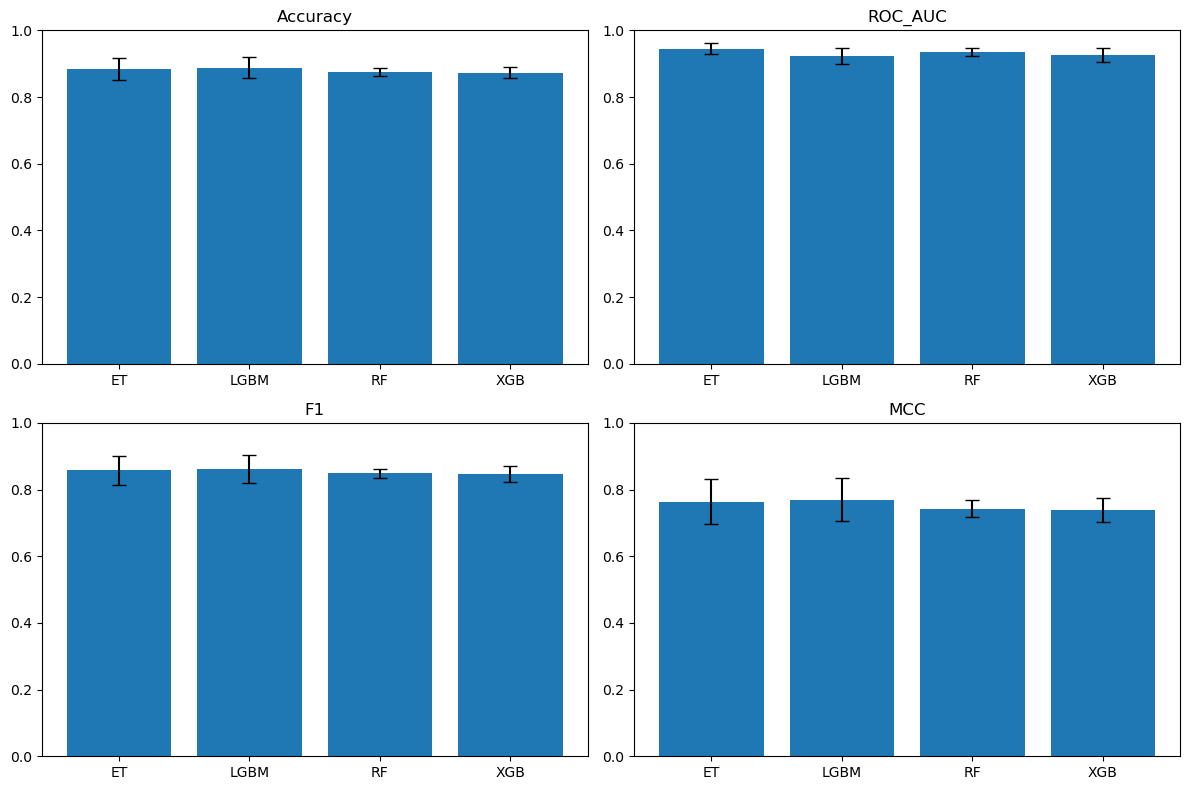

In [19]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "ROC_AUC", "F1", "MCC"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    ax.bar(
        summary["Model"],
        summary[f"{metric}_mean"],
        yerr=summary[f"{metric}_std"],
        capsize=5
    )

    ax.set_title(metric)
    ax.set_ylim(0,1)

plt.tight_layout()
plt.show()

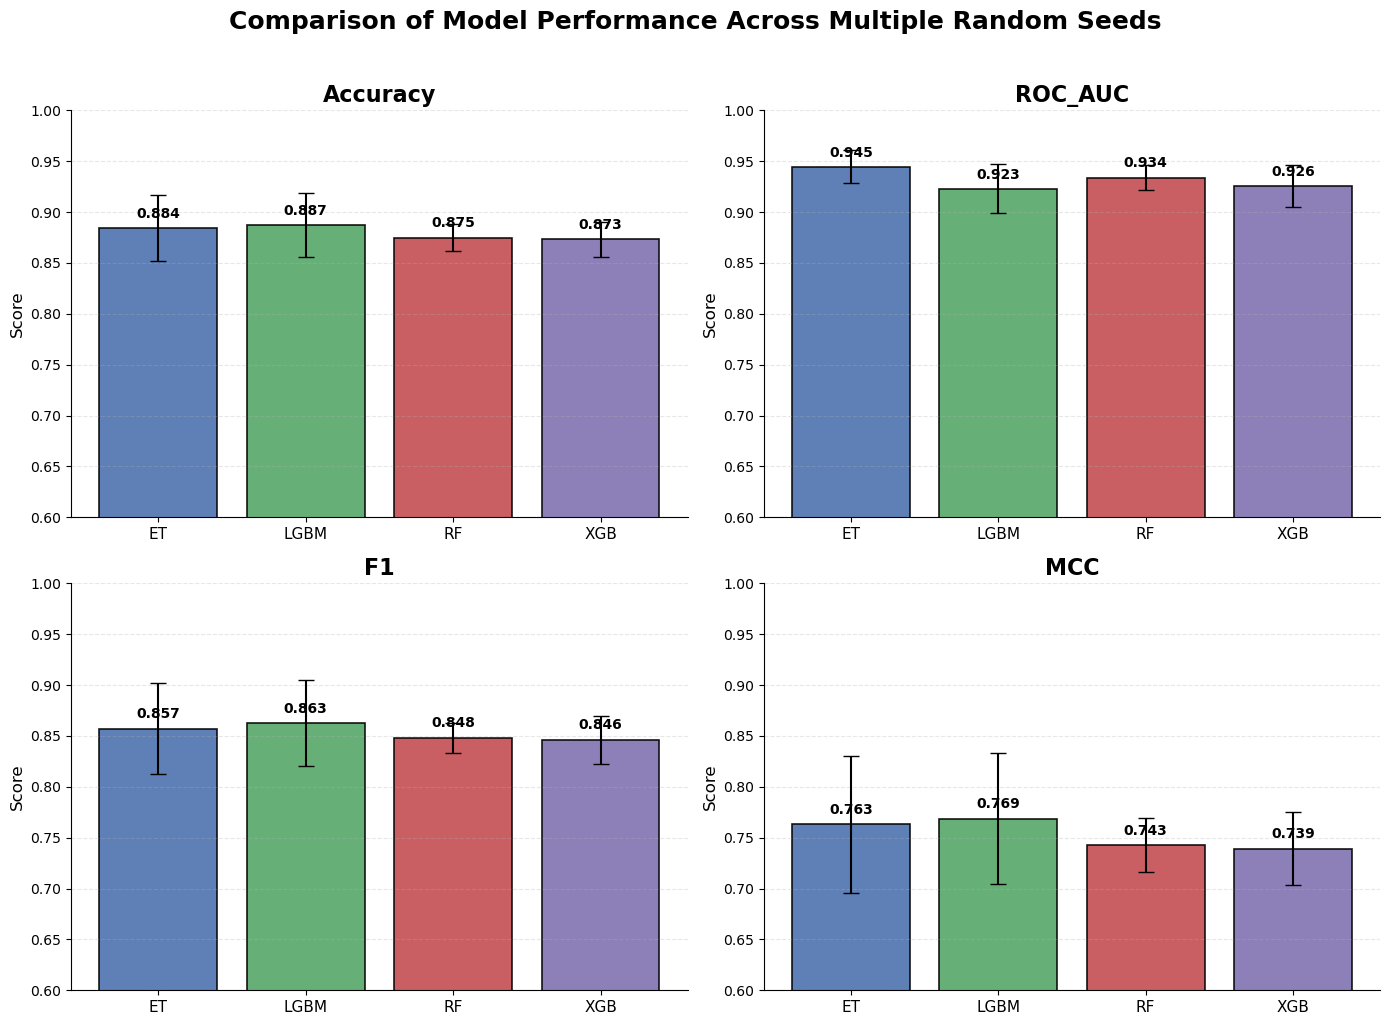

In [20]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "ROC_AUC", "F1", "MCC"]

# warna elegan
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]
    stds = summary[f"{metric}_std"]

    bars = ax.bar(
        summary["Model"],
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.9
    )

    # value annotation
    for bar, val in zip(bars, means):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.3f}",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    # styling
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=12)

    ax.set_ylim(0.6, 1.0)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=10)

plt.suptitle(
    "Comparison of Model Performance Across Multiple Random Seeds",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "multi_seed_comparison_publishable.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [21]:
final_table = pd.DataFrame()

final_table["Model"] = summary["Model"]

metrics = ["Accuracy", "ROC_AUC", "F1", "Precision", "Recall", "MCC"]

for metric in metrics:

    final_table[metric] = (
        summary[f"{metric}_mean"].round(3).astype(str)
        + " ± " +
        summary[f"{metric}_std"].round(3).astype(str)
    )

final_table

,Model,Accuracy,ROC_AUC,F1,Precision,Recall,MCC
0,ET,0.884 ± 0.033,0.945 ± 0.016,0.857 ± 0.045,0.888 ± 0.037,0.831 ± 0.07,0.763 ± 0.067
1,LGBM,0.887 ± 0.031,0.923 ± 0.024,0.863 ± 0.042,0.881 ± 0.034,0.847 ± 0.067,0.769 ± 0.065
2,RF,0.875 ± 0.013,0.934 ± 0.012,0.848 ± 0.015,0.867 ± 0.026,0.831 ± 0.018,0.743 ± 0.026
3,XGB,0.873 ± 0.017,0.926 ± 0.021,0.846 ± 0.024,0.861 ± 0.024,0.833 ± 0.043,0.739 ± 0.036


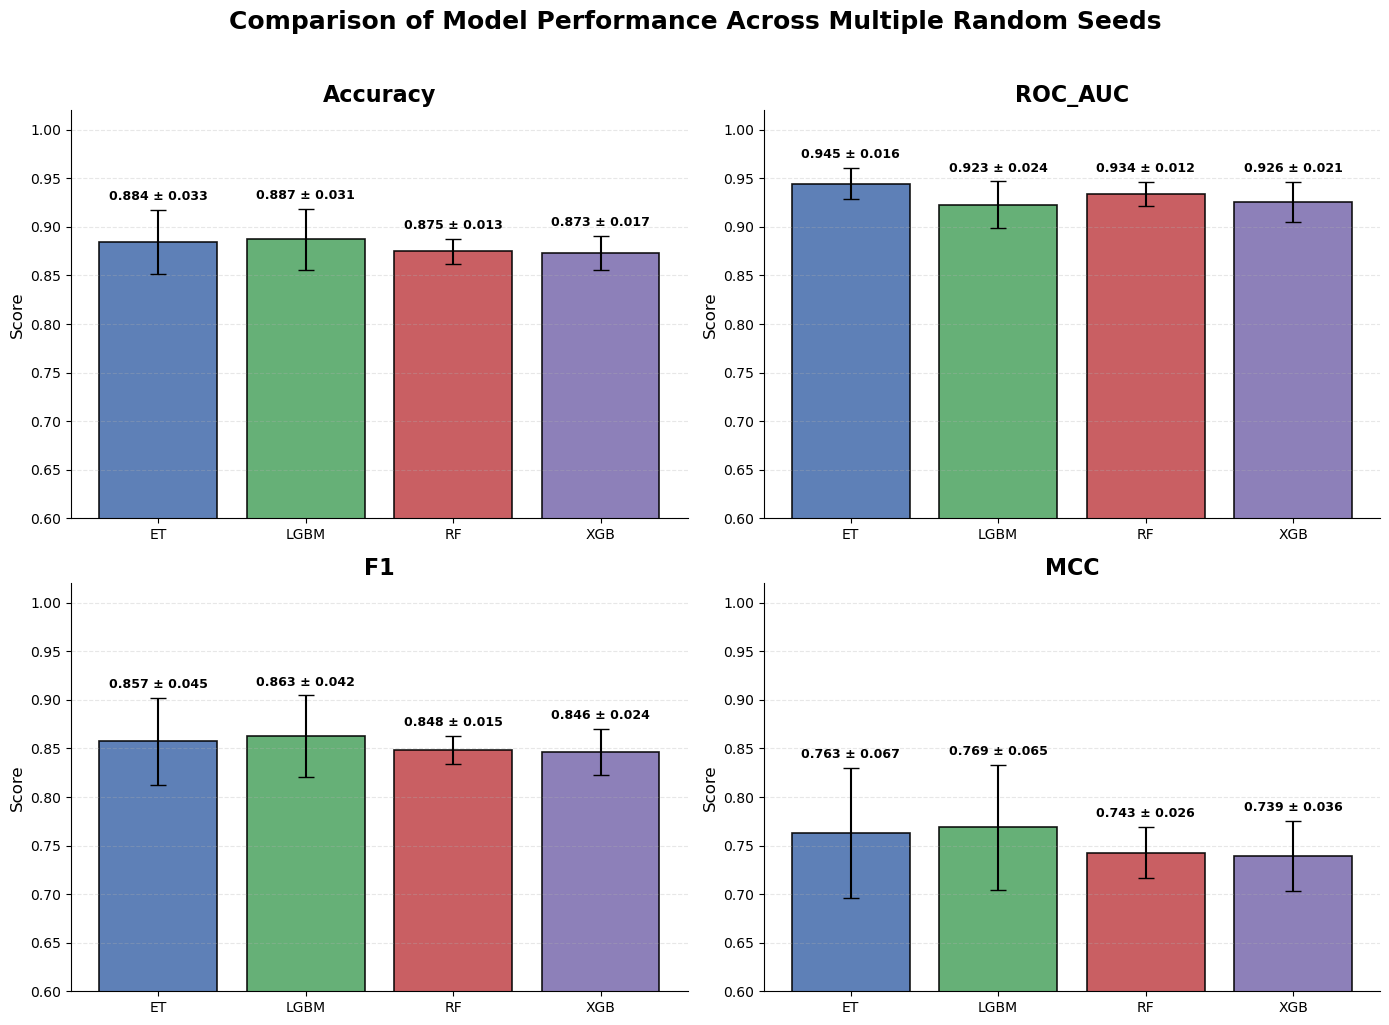

In [22]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "ROC_AUC", "F1", "MCC"]

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]
    stds = summary[f"{metric}_std"]

    bars = ax.bar(
        summary["Model"],
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.9
    )

    # add mean ± std text
    for bar, mean_val, std_val in zip(bars, means, stds):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean_val + std_val + 0.01,
            f"{mean_val:.3f} ± {std_val:.3f}",
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=12)

    ax.set_ylim(0.6, 1.02)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Comparison of Model Performance Across Multiple Random Seeds",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "publishable_metrics_plot.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

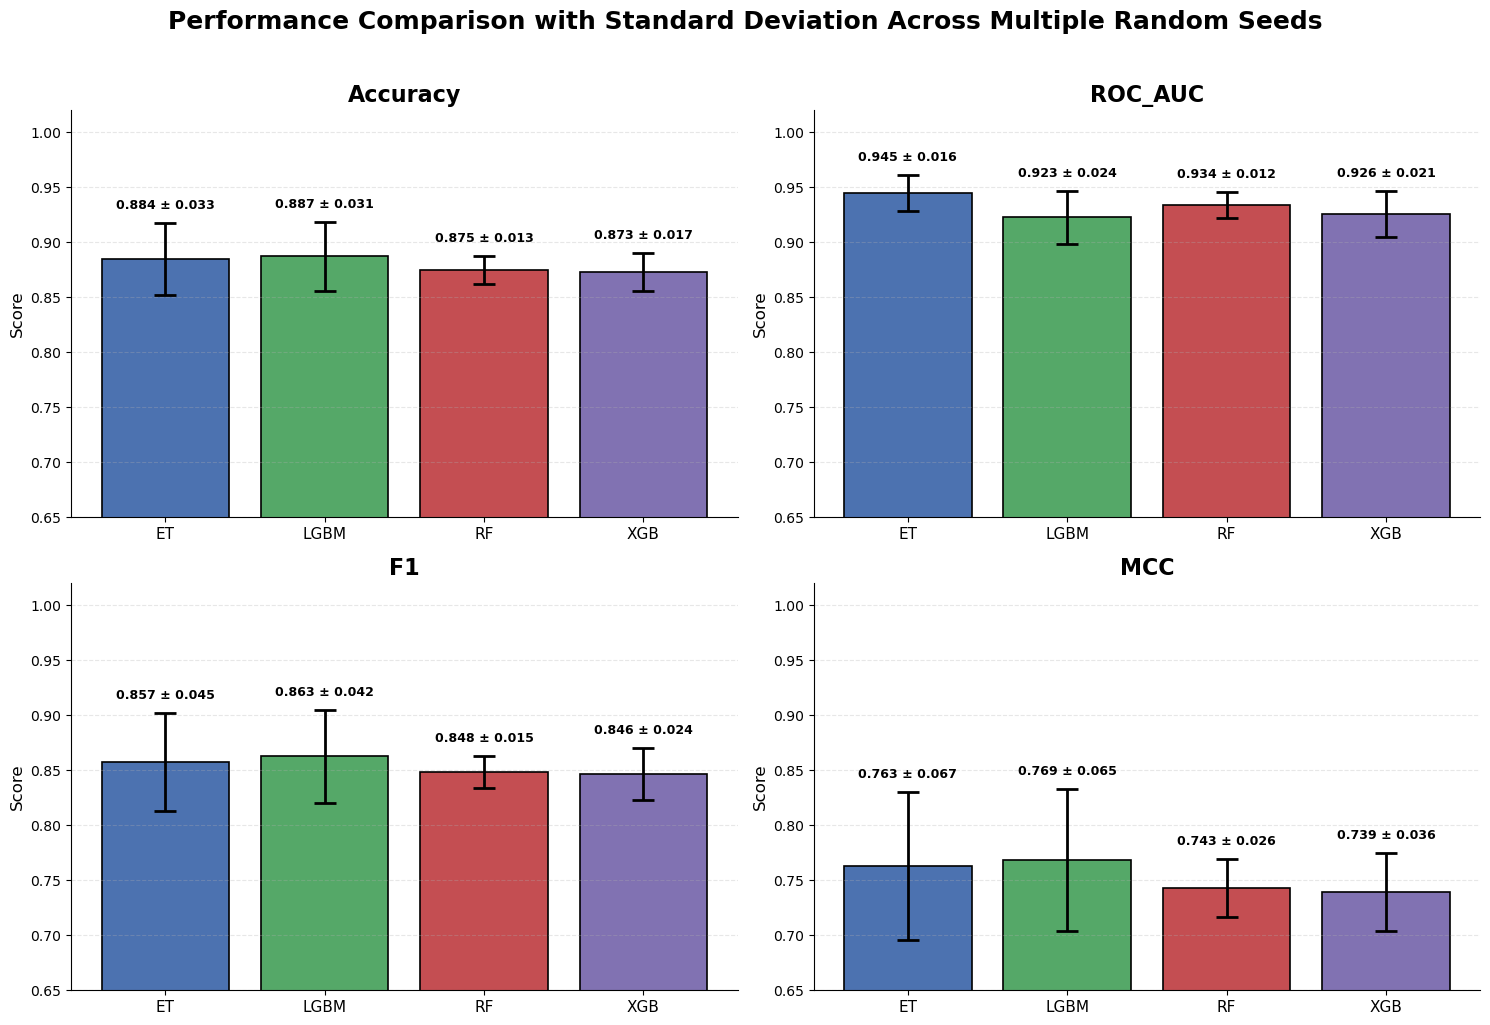

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# metric yang mau diplot
metrics = ["Accuracy", "ROC_AUC", "F1", "MCC"]

# warna per model
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# figure
fig, axes = plt.subplots(2, 2, figsize=(15,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]
    stds = summary[f"{metric}_std"]

    # barplot + SD error bars
    bars = ax.bar(
        summary["Model"],
        means,
        yerr=stds,              # <- ini standard deviation
        capsize=8,              # ukuran "tanda SD"
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        error_kw={
            'elinewidth':2,
            'ecolor':'black',
            'capthick':2
        }
    )

    # teks mean ± SD
    for bar, mean_val, std_val in zip(bars, means, stds):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean_val + std_val + 0.01,
            f"{mean_val:.3f} ± {std_val:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # styling
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=12)

    ax.set_ylim(0.65, 1.02)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=10)

# judul utama
plt.suptitle(
    "Performance Comparison with Standard Deviation Across Multiple Random Seeds",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

# save high resolution
plt.savefig(
    "model_comparison_with_SD.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

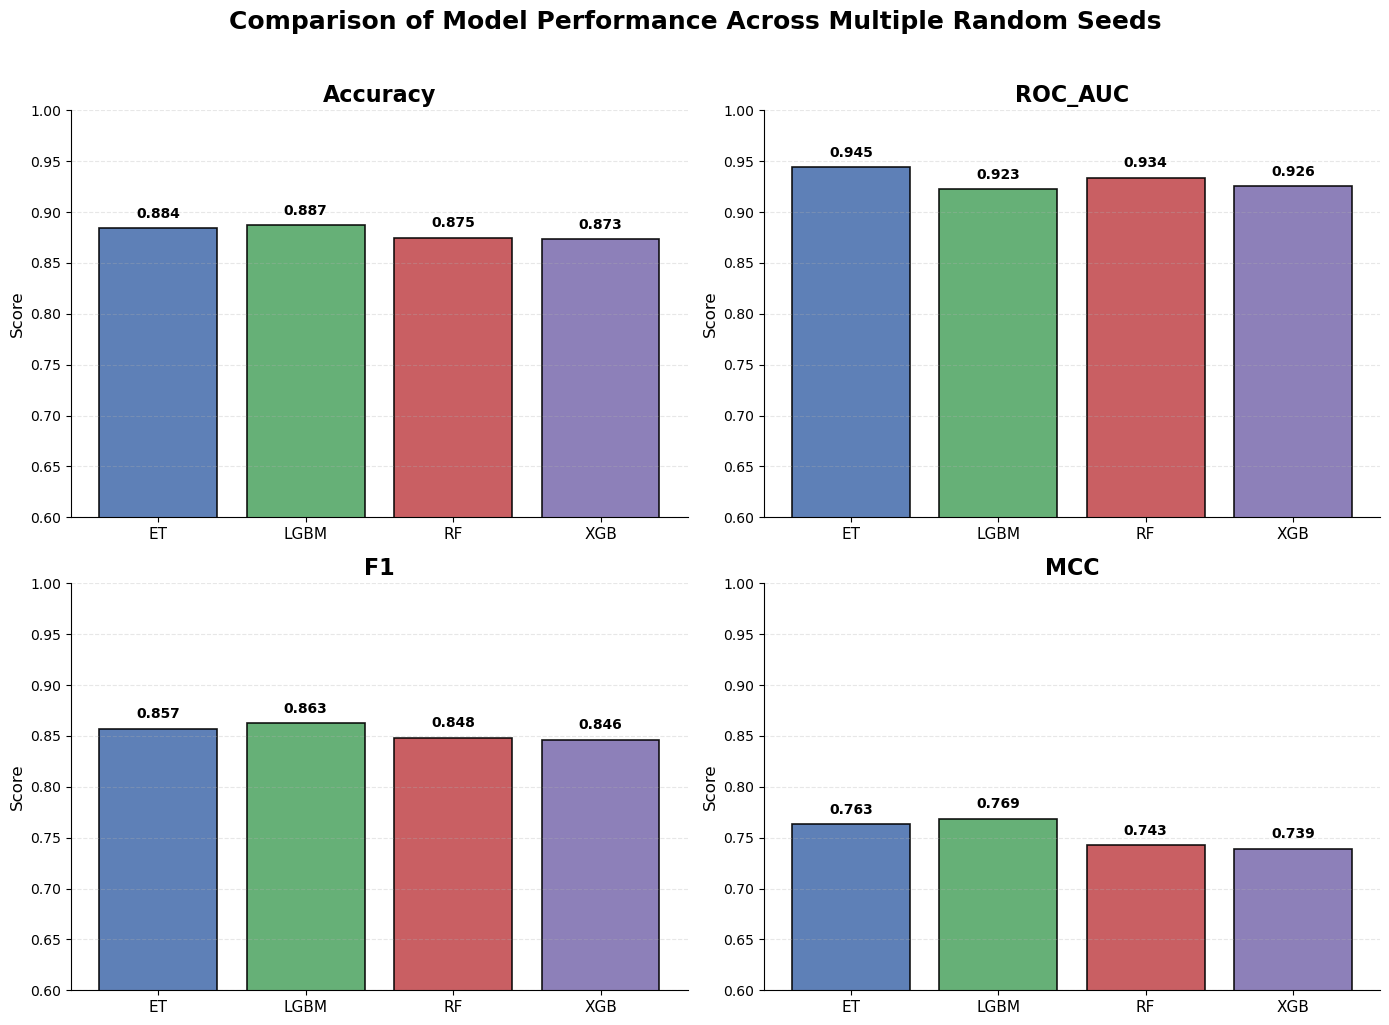

In [24]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "ROC_AUC", "F1", "MCC"]

# warna publishable
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]

    bars = ax.bar(
        summary["Model"],
        means,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.9
    )

    # value annotation
    for bar, val in zip(bars, means):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.3f}",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    # styling
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=12)

    ax.set_ylim(0.6, 1.0)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=10)

plt.suptitle(
    "Comparison of Model Performance Across Multiple Random Seeds",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "publishable_metrics_no_sd.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

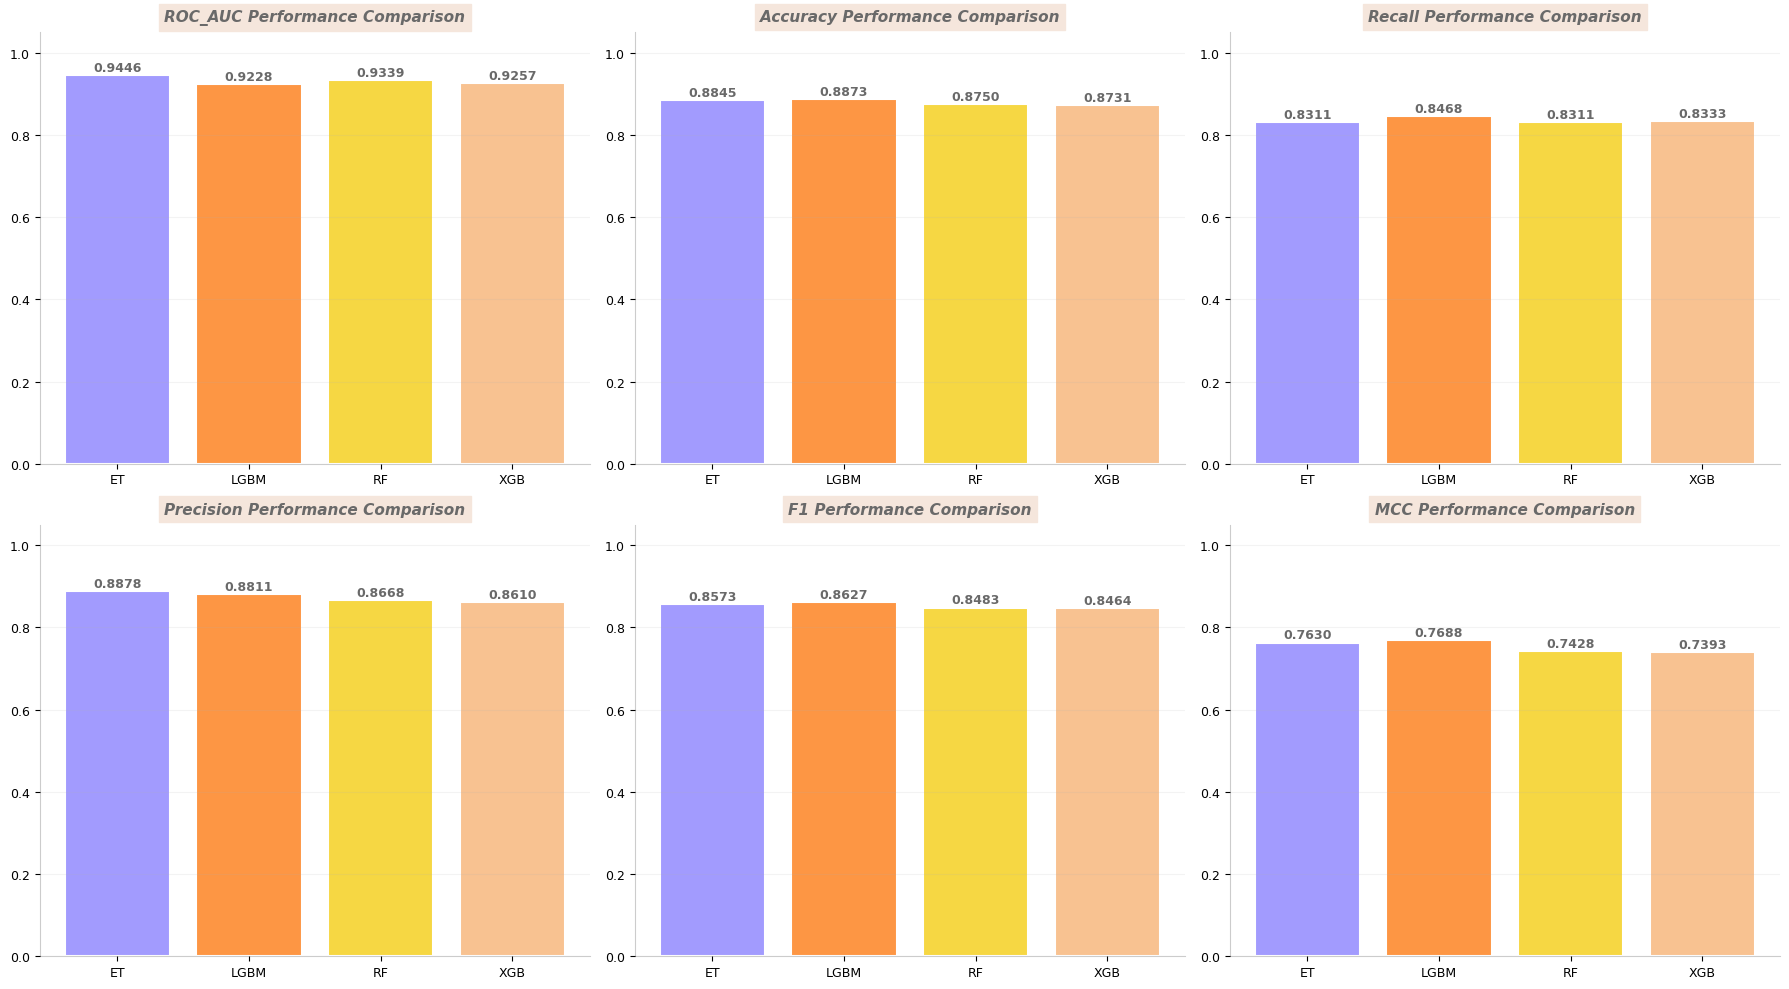

In [25]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROC_AUC", "Accuracy", "Recall", "Precision", "F1", "MCC"]

# warna aesthetic
colors = [
    "#A29BFE",
    "#FD9644",
    "#F6D743",
    "#F8C291",
    "#A3D5E0",
    "#7BD389",
    "#3B3BDB",
    "#E58ACF"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]

    bars = ax.bar(
        summary["Model"],
        means,
        color=colors[:len(summary)],
        edgecolor='white',
        linewidth=1.5
    )

    # angka di atas batang
    for bar, val in zip(bars, means):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.4f}",
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='dimgray'
        )

    # title
    ax.set_title(
        f"{metric} Performance Comparison",
        fontsize=11,
        fontweight='bold',
        style='italic',
        color='dimgray',
        backgroundcolor='#F5E6DC',
        pad=8
    )

    ax.set_ylim(0, 1.05)

    # grid soft
    ax.grid(
        axis='y',
        linestyle='-',
        alpha=0.15
    )

    # clean border
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.2)
    ax.spines['bottom'].set_alpha(0.2)

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

plt.savefig(
    "journal_style_multimetric_plot.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

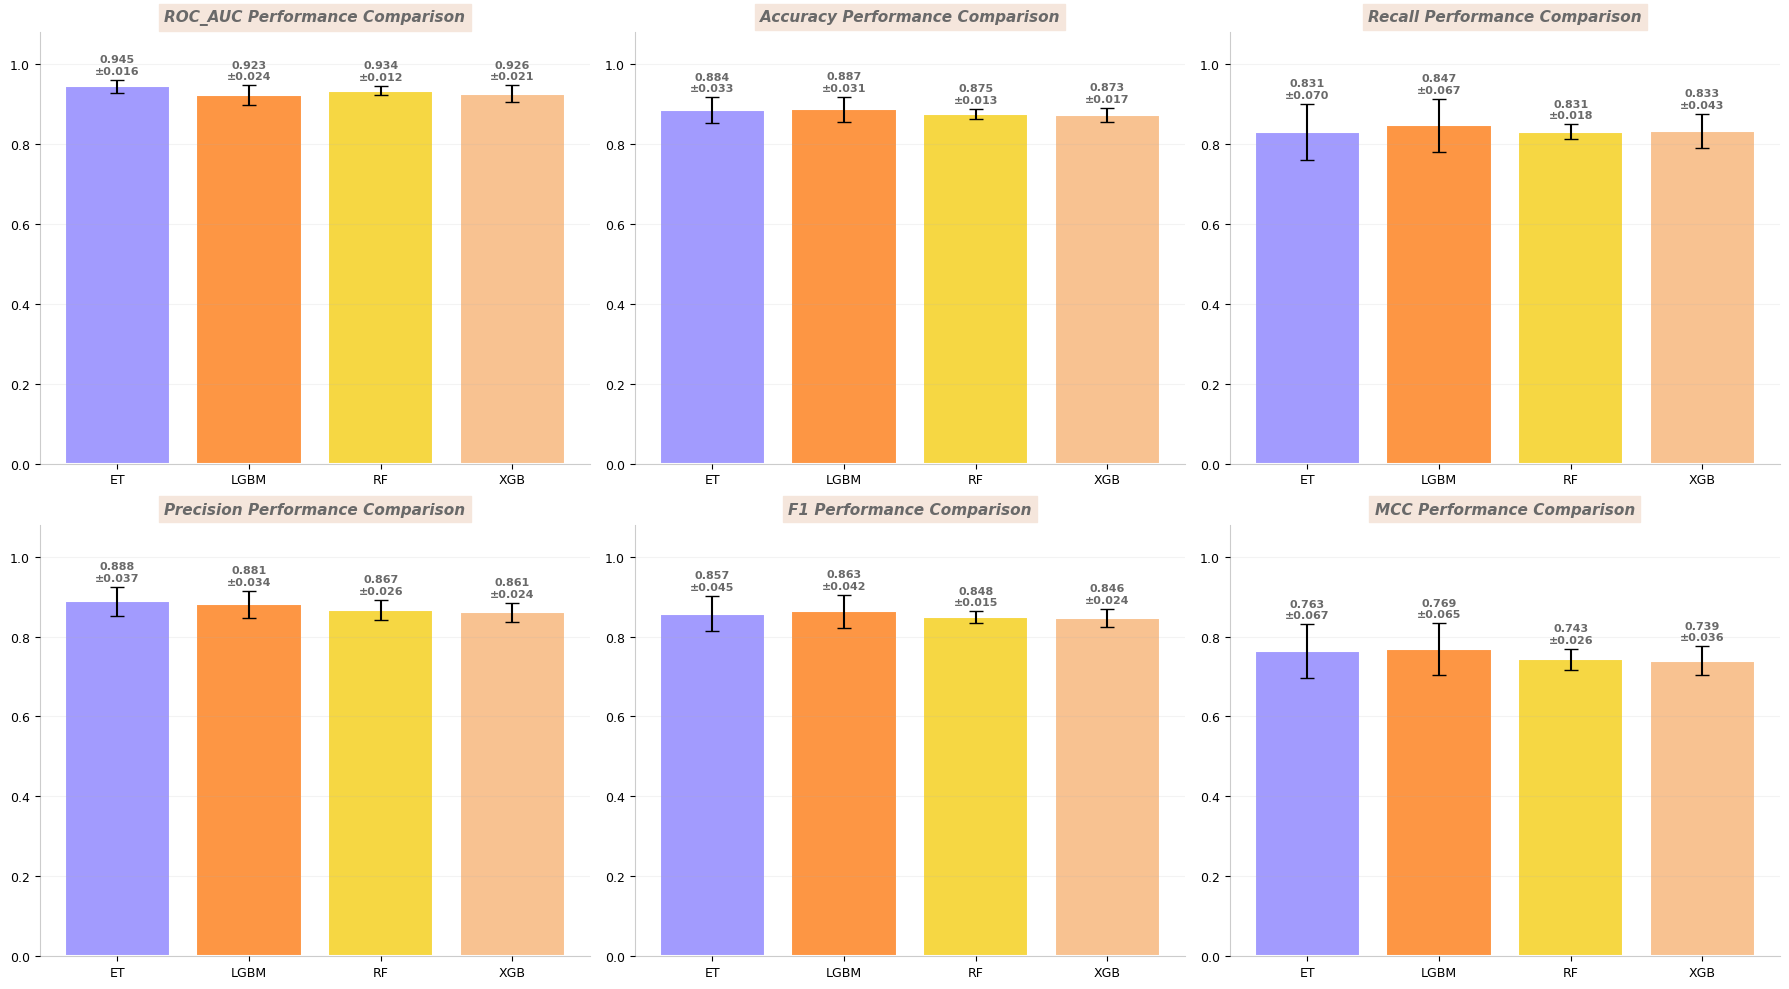

In [26]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROC_AUC", "Accuracy", "Recall", "Precision", "F1", "MCC"]

# warna pastel journal-style
colors = [
    "#A29BFE",
    "#FD9644",
    "#F6D743",
    "#F8C291",
    "#A3D5E0",
    "#7BD389",
    "#3B3BDB",
    "#E58ACF"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]
    stds = summary[f"{metric}_std"]

    bars = ax.bar(
        summary["Model"],
        means,
        yerr=stds,
        capsize=5,
        color=colors[:len(summary)],
        edgecolor='white',
        linewidth=1.5,
        error_kw={
            'elinewidth': 1.5,
            'ecolor': 'black'
        }
    )

    # text mean ± std
    for bar, mean_val, std_val in zip(bars, means, stds):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean_val + std_val + 0.015,
            f"{mean_val:.3f}\n±{std_val:.3f}",
            ha='center',
            fontsize=8,
            fontweight='bold',
            color='dimgray'
        )

    # title aesthetic
    ax.set_title(
        f"{metric} Performance Comparison",
        fontsize=11,
        fontweight='bold',
        style='italic',
        color='dimgray',
        backgroundcolor='#F5E6DC',
        pad=8
    )

    ax.set_ylim(0, 1.08)

    # soft grid
    ax.grid(
        axis='y',
        linestyle='-',
        alpha=0.15
    )

    # clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.2)
    ax.spines['bottom'].set_alpha(0.2)

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

plt.savefig(
    "journal_style_multimetric_with_std.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

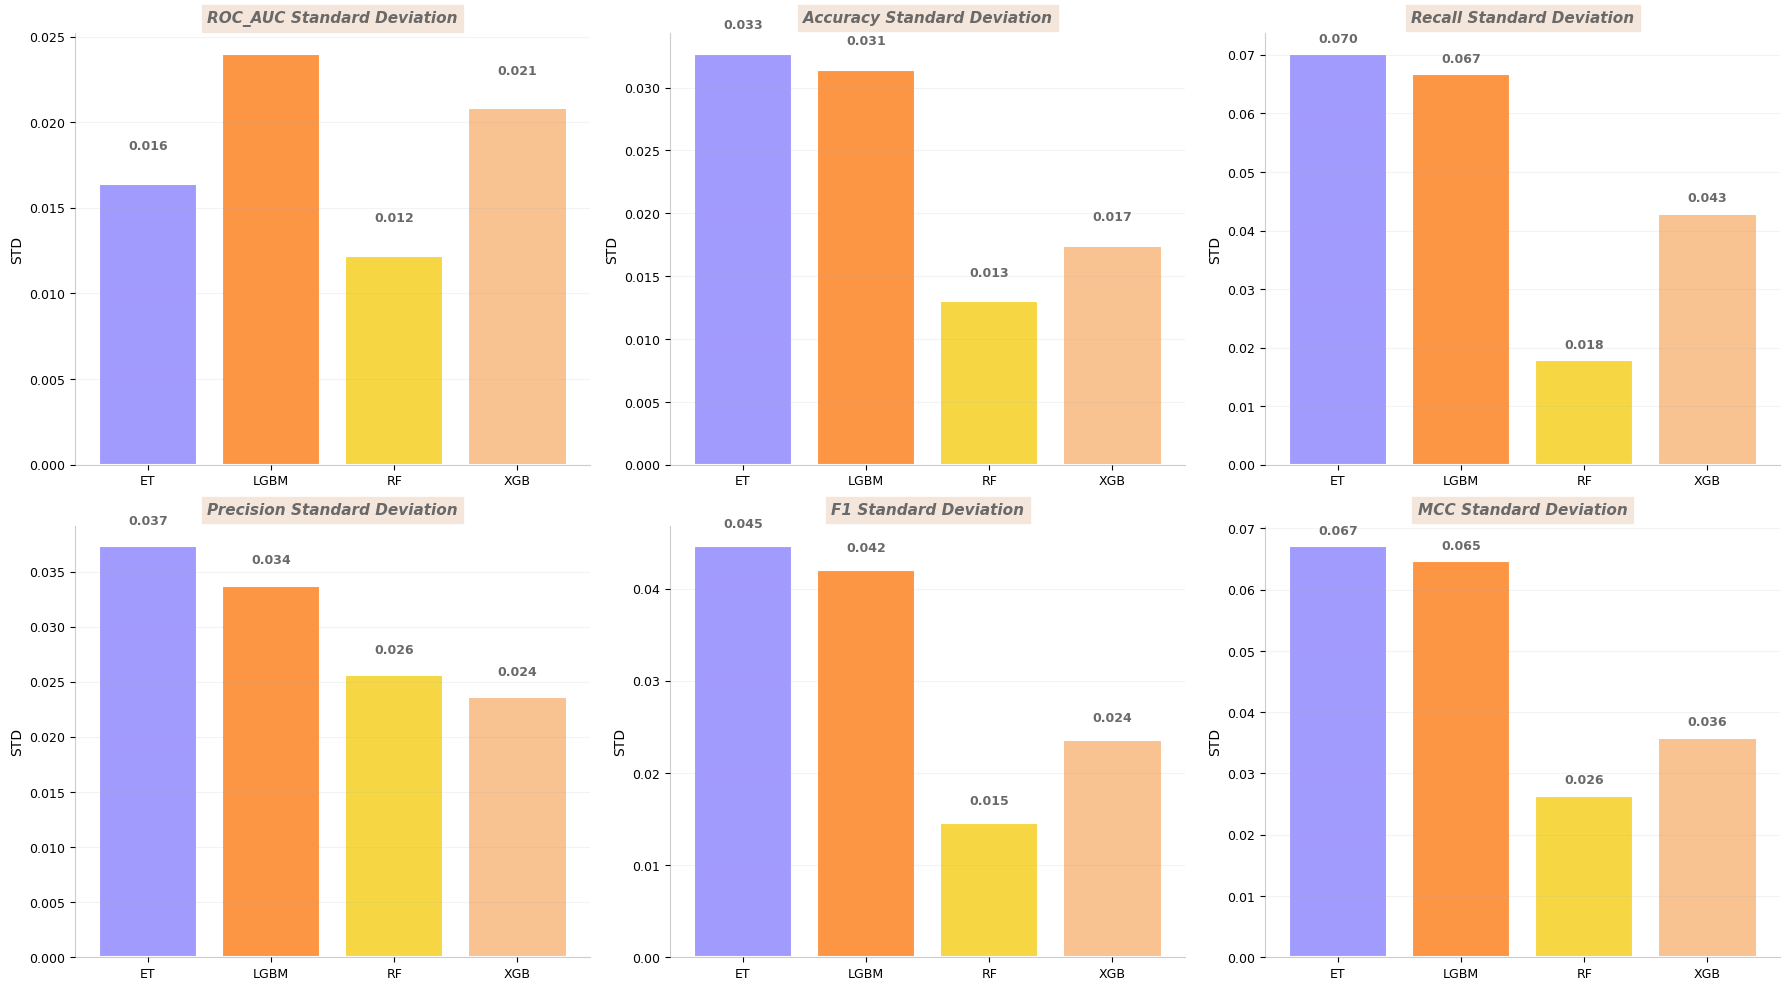

In [27]:
import matplotlib.pyplot as plt

metrics = ["ROC_AUC", "Accuracy", "Recall", "Precision", "F1", "MCC"]

# warna pastel
colors = [
    "#A29BFE",
    "#FD9644",
    "#F6D743",
    "#F8C291",
    "#A3D5E0",
    "#7BD389",
    "#3B3BDB",
    "#E58ACF"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    stds = summary[f"{metric}_std"]

    bars = ax.bar(
        summary["Model"],
        stds,
        color=colors[:len(summary)],
        edgecolor='white',
        linewidth=1.5
    )

    # value annotation
    for bar, val in zip(bars, stds):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.002,
            f"{val:.3f}",
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='dimgray'
        )

    # title
    ax.set_title(
        f"{metric} Standard Deviation",
        fontsize=11,
        fontweight='bold',
        style='italic',
        color='dimgray',
        backgroundcolor='#F5E6DC',
        pad=8
    )

    ax.set_ylabel("STD", fontsize=10)

    ax.grid(
        axis='y',
        linestyle='-',
        alpha=0.15
    )

    # clean style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.2)
    ax.spines['bottom'].set_alpha(0.2)

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

plt.savefig(
    "journal_style_std_only_plot.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

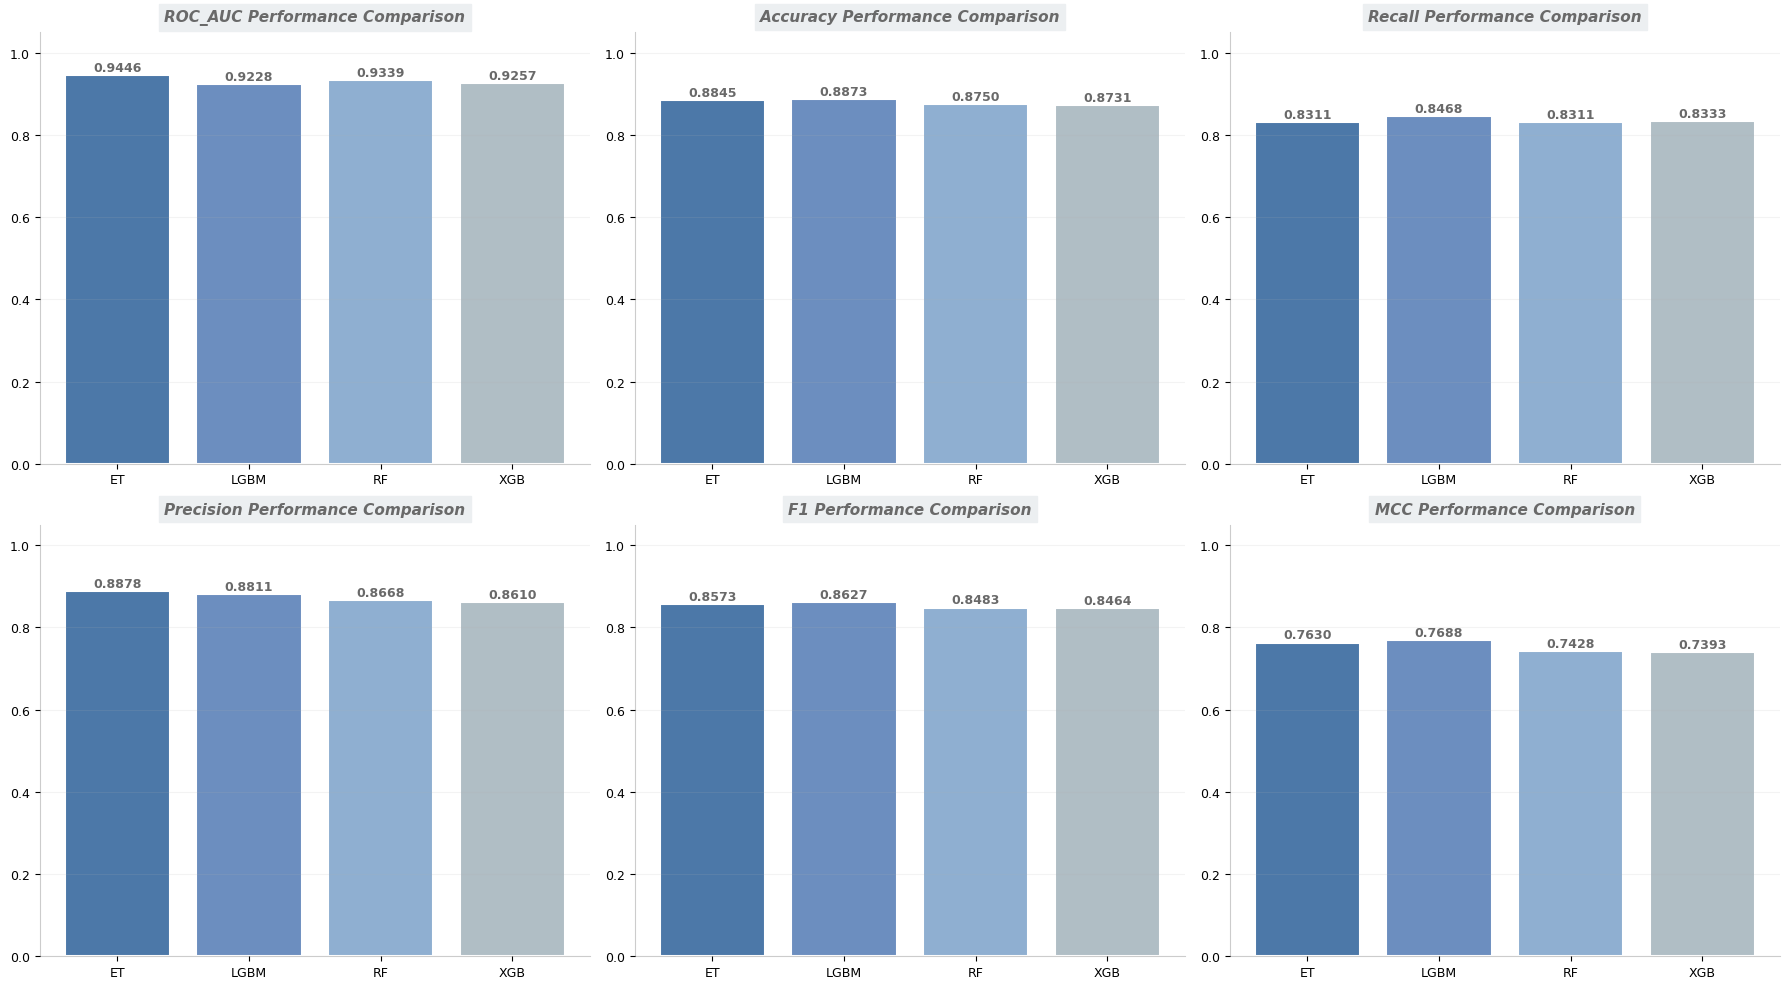

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROC_AUC", "Accuracy", "Recall", "Precision", "F1", "MCC"]

# palette biru-abu aesthetic
colors = [
    "#4C78A8",  # blue
    "#6C8EBF",  # soft blue
    "#8FAFD1",  # lighter blue
    "#B0BEC5"   # gray-blue
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]

    bars = ax.bar(
        summary["Model"],
        means,
        color=colors[:len(summary)],
        edgecolor='white',
        linewidth=1.5
    )

    # angka di atas batang
    for bar, val in zip(bars, means):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.4f}",
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='dimgray'
        )

    # title
    ax.set_title(
        f"{metric} Performance Comparison",
        fontsize=11,
        fontweight='bold',
        style='italic',
        color='dimgray',
        backgroundcolor='#ECEFF1',
        pad=8
    )

    ax.set_ylim(0, 1.05)

    # soft grid
    ax.grid(
        axis='y',
        linestyle='-',
        alpha=0.15
    )

    # clean border
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.2)
    ax.spines['bottom'].set_alpha(0.2)

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

plt.savefig(
    "blue_gray_journal_metrics_plot.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

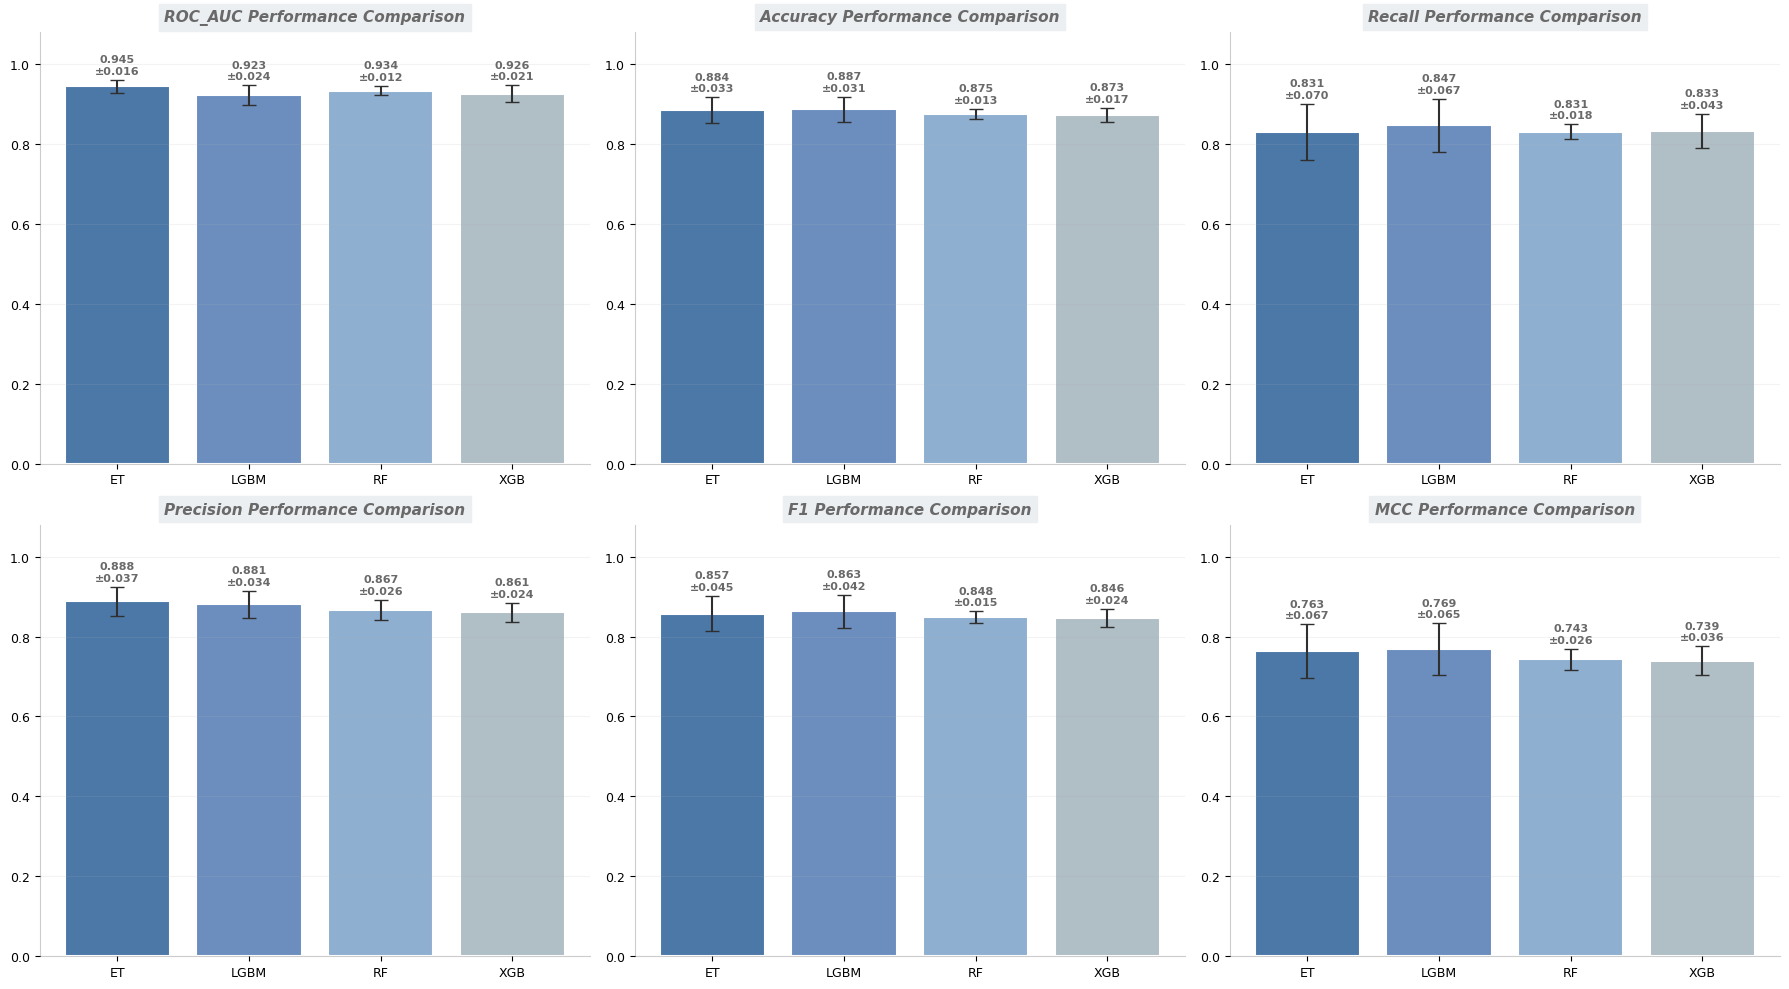

In [29]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROC_AUC", "Accuracy", "Recall", "Precision", "F1", "MCC"]

# palette biru-abu aesthetic
colors = [
    "#4C78A8",  # blue
    "#6C8EBF",  # soft blue
    "#8FAFD1",  # lighter blue
    "#B0BEC5"   # gray-blue
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    means = summary[f"{metric}_mean"]
    stds = summary[f"{metric}_std"]

    bars = ax.bar(
        summary["Model"],
        means,
        yerr=stds,
        capsize=5,
        color=colors[:len(summary)],
        edgecolor='white',
        linewidth=1.5,
        error_kw={
            'elinewidth': 1.5,
            'ecolor': '#2F2F2F'
        }
    )

    # text mean ± std
    for bar, mean_val, std_val in zip(bars, means, stds):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean_val + std_val + 0.015,
            f"{mean_val:.3f}\n±{std_val:.3f}",
            ha='center',
            fontsize=8,
            fontweight='bold',
            color='dimgray'
        )

    # title
    ax.set_title(
        f"{metric} Performance Comparison",
        fontsize=11,
        fontweight='bold',
        style='italic',
        color='dimgray',
        backgroundcolor='#ECEFF1',
        pad=8
    )

    ax.set_ylim(0, 1.08)

    # soft grid
    ax.grid(
        axis='y',
        linestyle='-',
        alpha=0.15
    )

    # clean style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.2)
    ax.spines['bottom'].set_alpha(0.2)

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

plt.savefig(
    "blue_gray_journal_metrics_with_std.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

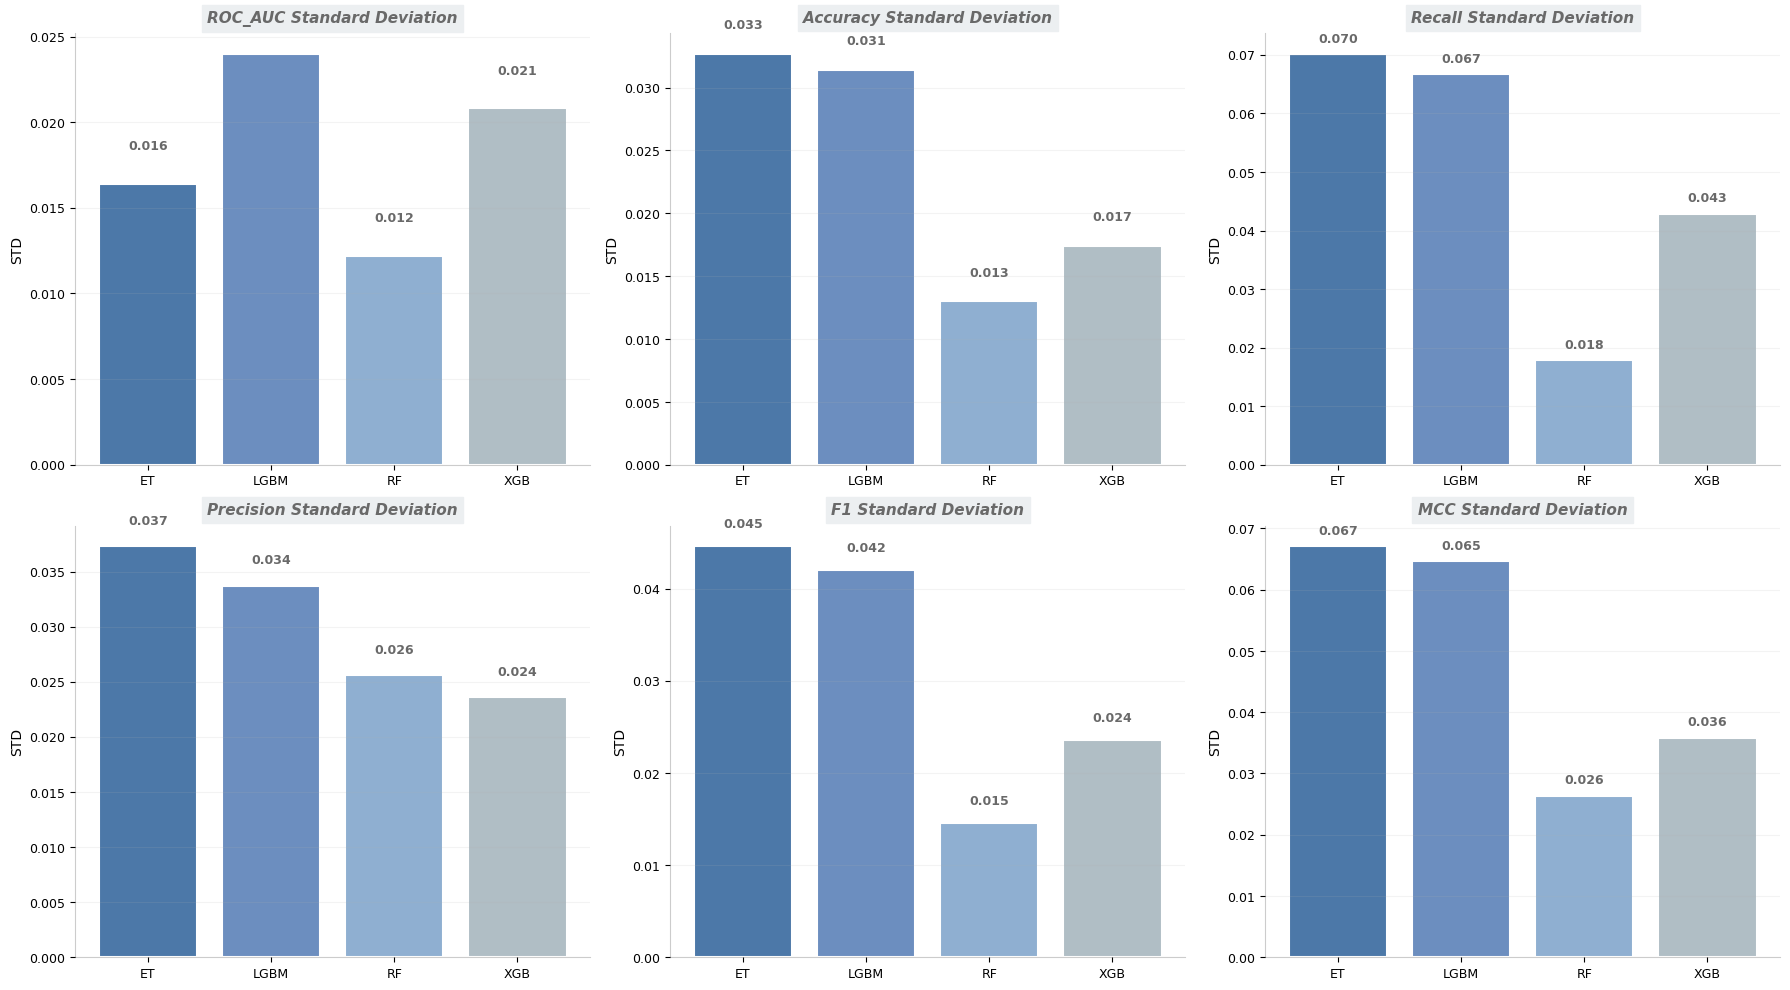

In [30]:
import matplotlib.pyplot as plt

metrics = ["ROC_AUC", "Accuracy", "Recall", "Precision", "F1", "MCC"]

# palette biru-abu
colors = [
    "#4C78A8",
    "#6C8EBF",
    "#8FAFD1",
    "#B0BEC5"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    stds = summary[f"{metric}_std"]

    bars = ax.bar(
        summary["Model"],
        stds,
        color=colors[:len(summary)],
        edgecolor='white',
        linewidth=1.5
    )

    # angka std
    for bar, val in zip(bars, stds):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.002,
            f"{val:.3f}",
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='dimgray'
        )

    # title
    ax.set_title(
        f"{metric} Standard Deviation",
        fontsize=11,
        fontweight='bold',
        style='italic',
        color='dimgray',
        backgroundcolor='#ECEFF1',
        pad=8
    )

    ax.set_ylabel("STD", fontsize=10)

    # soft grid
    ax.grid(
        axis='y',
        linestyle='-',
        alpha=0.15
    )

    # clean style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.2)
    ax.spines['bottom'].set_alpha(0.2)

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

plt.savefig(
    "blue_gray_std_only_plot.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [1]:
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

models_list = ["ET", "RF", "XGB", "LGBM"]

for metric in metrics:

    et_scores = results_df[
        results_df["Model"] == "ET"
    ][metric].values

    for other_model in ["RF", "XGB", "LGBM"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        t_stat, p_val = ttest_rel(
            et_scores,
            other_scores
        )

        comparisons.append({
            "Metric": metric,
            "Comparison": f"ET vs {other_model}",
            "t_statistic": round(t_stat, 4),
            "p_value": round(p_val, 4)
        })

ttest_df = pd.DataFrame(comparisons)

ttest_df

NameError: name 'results_df' is not defined

In [2]:
import pandas as pd
from scipy.stats import ttest_rel

# metric yang diuji
metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

# compare ET dengan model lain
for metric in metrics:

    et_scores = results_df[
        results_df["Model"] == "ET"
    ][metric].values

    for other_model in ["RF", "XGB", "LGBM"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        # paired t-test
        t_stat, p_val = ttest_rel(
            et_scores,
            other_scores
        )

        # interpretasi signifikan
        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"ET vs {other_model}",

            "ET_Mean": round(et_scores.mean(), 4),
            f"{other_model}_Mean": round(other_scores.mean(), 4),

            "t_statistic": round(t_stat, 4),
            "p_value": round(p_val, 4),

            "Interpretation": significance
        })

# dataframe final
ttest_df = pd.DataFrame(comparisons)

# tampilkan
ttest_df

NameError: name 'results_df' is not defined

In [3]:
results_df.head()

NameError: name 'results_df' is not defined

In [4]:
import pandas as pd
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

for metric in metrics:

    et_scores = results_df[
        results_df["Model"] == "ET"
    ][metric].values

    for other_model in ["RF", "XGB", "LGBM"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        # paired t-test
        t_stat, p_val = ttest_rel(
            et_scores,
            other_scores
        )

        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"ET vs {other_model}",

            "ET_Mean": round(et_scores.mean(), 4),
            f"{other_model}_Mean": round(other_scores.mean(), 4),

            "t_statistic": round(t_stat, 4),
            "p_value": round(p_val, 4),

            "Interpretation": significance
        })

ttest_df = pd.DataFrame(comparisons)

ttest_df

NameError: name 'results_df' is not defined

In [5]:
results_df = pd.DataFrame(results)

results_df.head()

NameError: name 'results' is not defined

In [6]:
print(type(results_df))

results_df.head()

NameError: name 'results_df' is not defined

In [7]:
import pandas as pd

results_df = pd.DataFrame({

    "Seed": [
        42,42,42,42,
        52,52,52,52,
        62,62,62,62
    ],

    "Model": [
        "RF","ET","XGB","LGBM",
        "RF","ET","XGB","LGBM",
        "RF","ET","XGB","LGBM"
    ],

    "ROC_AUC": [
        0.947999,0.958648,0.948264,0.948529,
        0.927911,0.948513,0.921403,0.918886,
        0.925924,0.926587,0.907293,0.901100
    ],

    "Accuracy": [
        0.889205,0.917614,0.892045,0.920455,
        0.863636,0.883523,0.869318,0.883523,
        0.872159,0.852273,0.857955,0.857955
    ],

    "F1": [
        0.865052,0.898955,0.869863,0.904110,
        0.837838,0.862876,0.846667,0.863787,
        0.842105,0.810219,0.822695,0.820144
    ],

    "Precision": [
        0.886525,0.928058,0.881944,0.916667,
        0.837838,0.854305,0.835526,0.849673,
        0.875912,0.880952,0.865672,0.876923
    ],

    "Recall": [
        0.844595,0.871622,0.858108,0.891892,
        0.837838,0.871622,0.858108,0.878378,
        0.810811,0.750000,0.783784,0.770270
    ],

    "MCC": [
        0.771821,0.830689,0.777873,0.836399,
        0.720191,0.761775,0.733038,0.762420,
        0.736522,0.696555,0.707119,0.707624
    ]
})

results_df

,Seed,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,42,RF,0.947999,0.889205,0.865052,0.886525,0.844595,0.771821
1,42,ET,0.958648,0.917614,0.898955,0.928058,0.871622,0.830689
2,42,XGB,0.948264,0.892045,0.869863,0.881944,0.858108,0.777873
3,42,LGBM,0.948529,0.920455,0.904110,0.916667,0.891892,0.836399
4,52,RF,0.927911,0.863636,0.837838,0.837838,0.837838,0.720191
5,52,ET,0.948513,0.883523,0.862876,0.854305,0.871622,0.761775
6,52,XGB,0.921403,0.869318,0.846667,0.835526,0.858108,0.733038
7,52,LGBM,0.918886,0.883523,0.863787,0.849673,0.878378,0.762420
8,62,RF,0.925924,0.872159,0.842105,0.875912,0.810811,0.736522
9,62,ET,0.926587,0.852273,0.810219,0.880952,0.750000,0.696555


In [8]:
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

for metric in metrics:

    et_scores = results_df[
        results_df["Model"] == "ET"
    ][metric].values

    for other_model in ["RF", "XGB", "LGBM"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        t_stat, p_val = ttest_rel(
            et_scores,
            other_scores
        )

        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"ET vs {other_model}",

            "p_value": round(p_val, 4),
            "Interpretation": significance
        })

ttest_df = pd.DataFrame(comparisons)

ttest_df

,Metric,Comparison,p_value,Interpretation
0,ROC_AUC,ET vs RF,0.2058,Not Significant
1,ROC_AUC,ET vs XGB,0.0594,Not Significant
2,ROC_AUC,ET vs LGBM,0.0671,Not Significant
3,Accuracy,ET vs RF,0.5897,Not Significant
4,Accuracy,ET vs XGB,0.3394,Not Significant
5,Accuracy,ET vs LGBM,0.2254,Not Significant
6,F1,ET vs RF,0.7044,Not Significant
7,F1,ET vs XGB,0.4671,Not Significant
8,F1,ET vs LGBM,0.1772,Not Significant
9,MCC,ET vs RF,0.5763,Not Significant


In [9]:
import itertools
import pandas as pd
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

model_names = ["RF", "ET", "XGB", "LGBM"]

comparisons = []

# semua kombinasi pasangan model
pairs = list(itertools.combinations(model_names, 2))

for metric in metrics:

    for model1, model2 in pairs:

        scores1 = results_df[
            results_df["Model"] == model1
        ][metric].values

        scores2 = results_df[
            results_df["Model"] == model2
        ][metric].values

        # paired t-test
        t_stat, p_val = ttest_rel(
            scores1,
            scores2
        )

        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"{model1} vs {model2}",

            f"{model1}_Mean": round(scores1.mean(), 4),
            f"{model2}_Mean": round(scores2.mean(), 4),

            "t_statistic": round(t_stat, 4),
            "p_value": round(p_val, 4),

            "Interpretation": significance
        })

# dataframe hasil
pairwise_ttest_df = pd.DataFrame(comparisons)

pairwise_ttest_df

,Metric,Comparison,RF_Mean,ET_Mean,t_statistic,p_value,Interpretation,XGB_Mean,LGBM_Mean
0,ROC_AUC,RF vs ET,0.9339,0.9446,-1.8482,0.2058,Not Significant,NaN,NaN
1,ROC_AUC,RF vs XGB,0.9339,NaN,1.5001,0.2724,Not Significant,0.9257,NaN
2,ROC_AUC,RF vs LGBM,0.9339,NaN,1.5023,0.2719,Not Significant,NaN,0.9228
3,ROC_AUC,ET vs XGB,NaN,0.9446,3.9176,0.0594,Not Significant,0.9257,NaN
4,ROC_AUC,ET vs LGBM,NaN,0.9446,3.6642,0.0671,Not Significant,NaN,0.9228
5,ROC_AUC,XGB vs LGBM,NaN,NaN,1.5052,0.2712,Not Significant,0.9257,0.9228
6,Accuracy,RF vs ET,0.8750,0.8845,-0.6363,0.5897,Not Significant,NaN,NaN
7,Accuracy,RF vs XGB,0.8750,NaN,0.3050,0.7892,Not Significant,0.8731,NaN
8,Accuracy,RF vs LGBM,0.8750,NaN,-0.9014,0.4625,Not Significant,NaN,0.8873
9,Accuracy,ET vs XGB,NaN,0.8845,1.2443,0.3394,Not Significant,0.8731,NaN


In [10]:
import pandas as pd
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

rf_scores_df = results_df[
    results_df["Model"] == "RF"
]

for metric in metrics:

    rf_scores = rf_scores_df[metric].values

    for other_model in ["ET", "XGB", "LGBM"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        t_stat, p_val = ttest_rel(
            rf_scores,
            other_scores
        )

        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"RF vs {other_model}",

            "RF_Mean": round(rf_scores.mean(), 4),
            f"{other_model}_Mean": round(other_scores.mean(), 4),

            "p_value": round(p_val, 4),
            "Interpretation": significance
        })

rf_ttest_df = pd.DataFrame(comparisons)

rf_ttest_df

,Metric,Comparison,RF_Mean,ET_Mean,p_value,Interpretation,XGB_Mean,LGBM_Mean
0,ROC_AUC,RF vs ET,0.9339,0.9446,0.2058,Not Significant,NaN,NaN
1,ROC_AUC,RF vs XGB,0.9339,NaN,0.2724,Not Significant,0.9257,NaN
2,ROC_AUC,RF vs LGBM,0.9339,NaN,0.2719,Not Significant,NaN,0.9228
3,Accuracy,RF vs ET,0.8750,0.8845,0.5897,Not Significant,NaN,NaN
4,Accuracy,RF vs XGB,0.8750,NaN,0.7892,Not Significant,0.8731,NaN
5,Accuracy,RF vs LGBM,0.8750,NaN,0.4625,Not Significant,NaN,0.8873
6,F1,RF vs ET,0.8483,0.8574,0.7044,Not Significant,NaN,NaN
7,F1,RF vs XGB,0.8483,NaN,0.8476,Not Significant,0.8464,NaN
8,F1,RF vs LGBM,0.8483,NaN,0.5200,Not Significant,NaN,0.8627
9,MCC,RF vs ET,0.7428,0.7630,0.5763,Not Significant,NaN,NaN


In [11]:
import pandas as pd
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

lgbm_scores_df = results_df[
    results_df["Model"] == "LGBM"
]

for metric in metrics:

    lgbm_scores = lgbm_scores_df[metric].values

    for other_model in ["RF", "ET", "XGB"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        t_stat, p_val = ttest_rel(
            lgbm_scores,
            other_scores
        )

        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"LGBM vs {other_model}",

            "LGBM_Mean": round(lgbm_scores.mean(), 4),
            f"{other_model}_Mean": round(other_scores.mean(), 4),

            "p_value": round(p_val, 4),
            "Interpretation": significance
        })

lgbm_ttest_df = pd.DataFrame(comparisons)

lgbm_ttest_df


,Metric,Comparison,LGBM_Mean,RF_Mean,p_value,Interpretation,ET_Mean,XGB_Mean
0,ROC_AUC,LGBM vs RF,0.9228,0.9339,0.2719,Not Significant,NaN,NaN
1,ROC_AUC,LGBM vs ET,0.9228,NaN,0.0671,Not Significant,0.9446,NaN
2,ROC_AUC,LGBM vs XGB,0.9228,NaN,0.2712,Not Significant,NaN,0.9257
3,Accuracy,LGBM vs RF,0.8873,0.8750,0.4625,Not Significant,NaN,NaN
4,Accuracy,LGBM vs ET,0.8873,NaN,0.2254,Not Significant,0.8845,NaN
5,Accuracy,LGBM vs XGB,0.8873,NaN,0.2254,Not Significant,NaN,0.8731
6,F1,LGBM vs RF,0.8627,0.8483,0.5200,Not Significant,NaN,NaN
7,F1,LGBM vs ET,0.8627,NaN,0.1772,Not Significant,0.8574,NaN
8,F1,LGBM vs XGB,0.8627,NaN,0.2655,Not Significant,NaN,0.8464
9,MCC,LGBM vs RF,0.7688,0.7428,0.4541,Not Significant,NaN,NaN


In [12]:
import pandas as pd
from scipy.stats import ttest_rel

metrics = ["ROC_AUC", "Accuracy", "F1", "MCC"]

comparisons = []

xgb_scores_df = results_df[
    results_df["Model"] == "XGB"
]

for metric in metrics:

    xgb_scores = xgb_scores_df[metric].values

    for other_model in ["RF", "ET", "LGBM"]:

        other_scores = results_df[
            results_df["Model"] == other_model
        ][metric].values

        t_stat, p_val = ttest_rel(
            xgb_scores,
            other_scores
        )

        significance = (
            "Significant"
            if p_val < 0.05
            else "Not Significant"
        )

        comparisons.append({

            "Metric": metric,
            "Comparison": f"XGB vs {other_model}",

            "XGB_Mean": round(xgb_scores.mean(), 4),
            f"{other_model}_Mean": round(other_scores.mean(), 4),

            "p_value": round(p_val, 4),
            "Interpretation": significance
        })

xgb_ttest_df = pd.DataFrame(comparisons)

xgb_ttest_df

,Metric,Comparison,XGB_Mean,RF_Mean,p_value,Interpretation,ET_Mean,LGBM_Mean
0,ROC_AUC,XGB vs RF,0.9257,0.9339,0.2724,Not Significant,NaN,NaN
1,ROC_AUC,XGB vs ET,0.9257,NaN,0.0594,Not Significant,0.9446,NaN
2,ROC_AUC,XGB vs LGBM,0.9257,NaN,0.2712,Not Significant,NaN,0.9228
3,Accuracy,XGB vs RF,0.8731,0.8750,0.7892,Not Significant,NaN,NaN
4,Accuracy,XGB vs ET,0.8731,NaN,0.3394,Not Significant,0.8845,NaN
5,Accuracy,XGB vs LGBM,0.8731,NaN,0.2254,Not Significant,NaN,0.8873
6,F1,XGB vs RF,0.8464,0.8483,0.8476,Not Significant,NaN,NaN
7,F1,XGB vs ET,0.8464,NaN,0.4671,Not Significant,0.8574,NaN
8,F1,XGB vs LGBM,0.8464,NaN,0.2655,Not Significant,NaN,0.8627
9,MCC,XGB vs RF,0.7393,0.7428,0.8143,Not Significant,NaN,NaN


In [13]:
import joblib
import pandas as pd
import numpy as np

# =========================================
# SAVE BEST MODELS
# =========================================
joblib.dump(best_rf, "best_rf_model.pkl")
joblib.dump(best_et, "best_et_model.pkl")
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(best_lgbm, "best_lgbm_model.pkl")

# =========================================
# SAVE DATASETS
# =========================================
X.to_csv("X_full_hybrid.csv", index=False)
y.to_csv("y_full.csv", index=False)

# =========================================
# SAVE MULTI-SEED RESULTS
# =========================================
results_df.to_csv("results_df.csv", index=False)

# =========================================
# SAVE SUMMARY TABLE
# =========================================
summary.to_csv("summary_mean_std.csv", index=False)

# =========================================
# SAVE T-TEST RESULTS
# =========================================
ttest_df.to_csv("ttest_results.csv", index=False)

# =========================================
# SAVE SHAP
# =========================================
np.save("shap_plot_values.npy", shap_plot_values)

# =========================================
# SAVE SAR RESULTS
# =========================================
sar_df.to_csv("sar_fragment_results.csv", index=False)

print("✅ ALL IMPORTANT FILES SAVED SUCCESSFULLY")

NameError: name 'best_rf' is not defined

In [14]:
import joblib
import pandas as pd
import numpy as np

# =========================================
# SAVE MODELS FROM models DICT
# =========================================
joblib.dump(models["RF"], "best_rf_model.pkl")
joblib.dump(models["ET"], "best_et_model.pkl")
joblib.dump(models["XGB"], "best_xgb_model.pkl")
joblib.dump(models["LGBM"], "best_lgbm_model.pkl")

# =========================================
# SAVE DATASETS
# =========================================
X.to_csv("X_full_hybrid.csv", index=False)
y.to_csv("y_full.csv", index=False)

# =========================================
# SAVE RESULTS
# =========================================
results_df.to_csv("results_df.csv", index=False)

# =========================================
# SAVE SUMMARY
# =========================================
summary.to_csv("summary_mean_std.csv", index=False)

# =========================================
# SAVE T-TEST
# =========================================
ttest_df.to_csv("ttest_results.csv", index=False)

# =========================================
# OPTIONAL SAVE SHAP
# =========================================
try:
    np.save("shap_plot_values.npy", shap_plot_values)
    print("✅ SHAP saved")
except:
    print("⚠️ SHAP not found")

# =========================================
# OPTIONAL SAVE SAR
# =========================================
try:
    sar_df.to_csv("sar_fragment_results.csv", index=False)
    print("✅ SAR saved")
except:
    print("⚠️ SAR not found")

print("✅ ALL IMPORTANT FILES SAVED")

NameError: name 'models' is not defined

In [15]:
import joblib

best_rf = joblib.load("RF_best_model.pkl")

best_et = joblib.load("ET_best_CYP3A4_model.pkl")

best_xgb = joblib.load("XGB_best_model.pkl")

best_lgbm = joblib.load("LGBM_best_model.pkl")

print("✅ all trained models loaded")

✅ all trained models loaded


In [16]:
import joblib

joblib.dump(best_rf, "RF_best_model.pkl")
joblib.dump(best_et, "ET_best_model.pkl")
joblib.dump(best_xgb, "XGB_best_model.pkl")
joblib.dump(best_lgbm, "LGBM_best_model.pkl")

print("✅ all models permanently saved")

✅ all models permanently saved


In [17]:
results_df.to_csv(
    "results_df.csv",
    index=False
)

summary.to_csv(
    "summary_mean_std.csv",
    index=False
)

ttest_df.to_csv(
    "ttest_results.csv",
    index=False
)

print("✅ all tables saved")

NameError: name 'summary' is not defined

In [18]:
summary = results_df.groupby("Model").agg({

    "ROC_AUC": ["mean", "std"],
    "Accuracy": ["mean", "std"],
    "F1": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "MCC": ["mean", "std"]

}).round(4)

summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary.columns
]

summary = summary.reset_index()

summary

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,MCC_mean,MCC_std
0,ET,0.9446,0.0164,0.8845,0.0327,0.8574,0.0446,0.8878,0.0373,0.8311,0.0702,0.7630,0.0671
1,LGBM,0.9228,0.0240,0.8873,0.0314,0.8627,0.0420,0.8811,0.0337,0.8468,0.0667,0.7688,0.0646
2,RF,0.9339,0.0122,0.8750,0.0130,0.8483,0.0146,0.8668,0.0256,0.8311,0.0179,0.7428,0.0264
3,XGB,0.9257,0.0208,0.8731,0.0174,0.8464,0.0236,0.8610,0.0236,0.8333,0.0429,0.7393,0.0358


In [19]:
summary.to_csv(
    "summary_mean_std.csv",
    index=False
)

print("✅ summary saved")

✅ summary saved


In [20]:
ttest_df.head()

,Metric,Comparison,p_value,Interpretation
0,ROC_AUC,ET vs RF,0.2058,Not Significant
1,ROC_AUC,ET vs XGB,0.0594,Not Significant
2,ROC_AUC,ET vs LGBM,0.0671,Not Significant
3,Accuracy,ET vs RF,0.5897,Not Significant
4,Accuracy,ET vs XGB,0.3394,Not Significant


In [1]:
import pandas as pd
import joblib

# =========================================
# LOAD MODELS
# =========================================
best_rf = joblib.load("RF_best_model.pkl")

best_et = joblib.load("ET_best_model.pkl")

best_xgb = joblib.load("XGB_best_model.pkl")

best_lgbm = joblib.load("LGBM_best_model.pkl")

# =========================================
# LOAD TABLES
# =========================================
results_df = pd.read_csv(
    "results_df.csv"
)

summary = pd.read_csv(
    "summary_mean_std.csv"
)

ttest_df = pd.read_csv(
    "ttest_results.csv"
)

print("✅ ALL FILES RELOADED SUCCESSFULLY")

ModuleNotFoundError: No module named 'xgboost'

In [2]:
import joblib

# Load best models
best_rf = joblib.load("RF_best_model.pkl")

best_et = joblib.load("ET_best_model.pkl")
# kalau error, coba:
# best_et = joblib.load("ET_best_CYP3A4_model.pkl")

best_xgb = joblib.load("XGB_best_model.pkl")

best_lgbm = joblib.load("LGBM_best_model.pkl")

print("✅ Models loaded successfully")


ModuleNotFoundError: No module named 'xgboost'

In [3]:
import xgboost
print(xgboost.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [1]:
import pandas as pd
import joblib

# =========================================
# LOAD MODELS
# =========================================
best_rf = joblib.load("RF_best_model.pkl")

best_et = joblib.load("ET_best_model.pkl")

best_xgb = joblib.load("XGB_best_model.pkl")

best_lgbm = joblib.load("LGBM_best_model.pkl")

# =========================================
# LOAD TABLES
# =========================================
results_df = pd.read_csv(
    "results_df.csv"
)

summary = pd.read_csv(
    "summary_mean_std.csv"
)

ttest_df = pd.read_csv(
    "ttest_results.csv"
)

print("✅ ALL FILES RELOADED SUCCESSFULLY")

✅ ALL FILES RELOADED SUCCESSFULLY


In [2]:
print(X.shape)
print(y.shape)

NameError: name 'X' is not defined

In [3]:
# load hybrid split
X_train = pd.read_csv("X_train_hybrid.csv")
X_test = pd.read_csv("X_test_hybrid.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# gabung kembali
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(X.shape)
print(y.shape)

(1756, 2059)
(1756,)


In [4]:
models_5seed = {
    "RF": best_rf,
    "ET": best_et,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef
)

seeds_5 = [42, 52, 62, 72, 82]

results_5seed = []

for seed in seeds_5:

    print(f"\nRunning seed {seed}...")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    for name, model in models_5seed.items():

        print(f"Training {name}...")

        try:
            model.set_params(random_state=seed)
        except:
            pass

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

        results_5seed.append({

            "Seed": seed,
            "Model": name,

            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred)

        })

results_df_5seed = pd.DataFrame(results_5seed)

results_df_5seed


Running seed 42...
Training RF...
Training ET...
Training XGB...
Training LGBM...
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 1404, number of used features: 819
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421652 -> initscore=-0.315994
[LightGBM] [Info] Start training from score -0.315994

Running seed 52...
Training RF...
Training ET...
Training XGB...
Training LGBM...
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col

,Seed,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,42,RF,0.947999,0.889205,0.865052,0.886525,0.844595,0.771821
1,42,ET,0.958648,0.917614,0.898955,0.928058,0.871622,0.830689
2,42,XGB,0.948264,0.892045,0.869863,0.881944,0.858108,0.777873
3,42,LGBM,0.948529,0.920455,0.904110,0.916667,0.891892,0.836399
4,52,RF,0.927928,0.863636,0.837838,0.837838,0.837838,0.720191
5,52,ET,0.948513,0.883523,0.862876,0.854305,0.871622,0.761775
6,52,XGB,0.921403,0.869318,0.846667,0.835526,0.858108,0.733038
7,52,LGBM,0.918886,0.883523,0.863787,0.849673,0.878378,0.762420
8,62,RF,0.925924,0.872159,0.842105,0.875912,0.810811,0.736522
9,62,ET,0.926587,0.852273,0.810219,0.880952,0.750000,0.696555


In [6]:
summary_5seed = results_df_5seed.groupby("Model").agg({

    "ROC_AUC": ["mean", "std"],
    "Accuracy": ["mean", "std"],
    "F1": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "MCC": ["mean", "std"]

}).round(4)

summary_5seed.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_5seed.columns
]

summary_5seed = summary_5seed.reset_index()

summary_5seed

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,MCC_mean,MCC_std
0,ET,0.9437,0.0123,0.8807,0.0238,0.8511,0.0328,0.8927,0.0272,0.8149,0.0546,0.7552,0.0488
1,LGBM,0.9276,0.0182,0.8824,0.0236,0.8563,0.0314,0.8783,0.0243,0.8365,0.0497,0.7582,0.0487
2,RF,0.9325,0.0101,0.8722,0.0104,0.8447,0.0129,0.8637,0.0196,0.8270,0.0217,0.7370,0.0214
3,XGB,0.9283,0.0155,0.8699,0.0159,0.8421,0.0202,0.8599,0.0243,0.8257,0.0322,0.7325,0.0328


In [7]:
results_df_5seed.to_csv(
    "results_df_5seed.csv",
    index=False
)

summary_5seed.to_csv(
    "summary_5seed.csv",
    index=False
)

print("✅ 5-seed results saved")

✅ 5-seed results saved


In [8]:
summary_5seed

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,MCC_mean,MCC_std
0,ET,0.9437,0.0123,0.8807,0.0238,0.8511,0.0328,0.8927,0.0272,0.8149,0.0546,0.7552,0.0488
1,LGBM,0.9276,0.0182,0.8824,0.0236,0.8563,0.0314,0.8783,0.0243,0.8365,0.0497,0.7582,0.0487
2,RF,0.9325,0.0101,0.8722,0.0104,0.8447,0.0129,0.8637,0.0196,0.8270,0.0217,0.7370,0.0214
3,XGB,0.9283,0.0155,0.8699,0.0159,0.8421,0.0202,0.8599,0.0243,0.8257,0.0322,0.7325,0.0328


10 seed

In [10]:
models_10seed = {
    "RF": best_rf,
    "ET": best_et,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef
)

seeds_10 = [
    42, 52, 62, 72, 82,
    92, 102, 112, 122, 132
]

results_10seed = []

for seed in seeds_10:

    print(f"\nRunning seed {seed}...")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    for name, model in models_10seed.items():

        print(f"Training {name}...")

        try:
            model.set_params(random_state=seed)
        except:
            pass

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results_10seed.append({

            "Seed": seed,
            "Model": name,

            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred)

        })

results_df_10seed = pd.DataFrame(results_10seed)

results_df_10seed


Running seed 42...
Training RF...
Training ET...
Training XGB...
Training LGBM...
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 1404, number of used features: 819
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421652 -> initscore=-0.315994
[LightGBM] [Info] Start training from score -0.315994

Running seed 52...
Training RF...
Training ET...
Training XGB...
Training LGBM...
[LightGBM] [Info] Number of positive: 592, number of negative: 812
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3251
[LightGBM] [Info]

,Seed,Model,ROC_AUC,Accuracy,F1,Precision,Recall,MCC
0,42,RF,0.947999,0.889205,0.865052,0.886525,0.844595,0.771821
1,42,ET,0.958648,0.917614,0.898955,0.928058,0.871622,0.830689
2,42,XGB,0.948264,0.892045,0.869863,0.881944,0.858108,0.777873
3,42,LGBM,0.948529,0.920455,0.904110,0.916667,0.891892,0.836399
4,52,RF,0.927911,0.863636,0.837838,0.837838,0.837838,0.720191
5,52,ET,0.948513,0.883523,0.862876,0.854305,0.871622,0.761775
6,52,XGB,0.921403,0.869318,0.846667,0.835526,0.858108,0.733038
7,52,LGBM,0.918886,0.883523,0.863787,0.849673,0.878378,0.762420
8,62,RF,0.925924,0.872159,0.842105,0.875912,0.810811,0.736522
9,62,ET,0.926587,0.852273,0.810219,0.880952,0.750000,0.696555


In [12]:
summary_10seed = results_df_10seed.groupby("Model").agg({

    "ROC_AUC": ["mean", "std"],
    "Accuracy": ["mean", "std"],
    "F1": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "MCC": ["mean", "std"]

}).round(4)

summary_10seed.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_10seed.columns
]

summary_10seed = summary_10seed.reset_index()

summary_10seed

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,MCC_mean,MCC_std
0,ET,0.9465,0.0126,0.8807,0.0215,0.8507,0.0297,0.8955,0.0254,0.8115,0.0476,0.7552,0.0440
1,LGBM,0.9324,0.0162,0.8795,0.0189,0.8538,0.0246,0.8709,0.0254,0.8385,0.0405,0.7526,0.0389
2,RF,0.9367,0.0134,0.8727,0.0146,0.8445,0.0193,0.8682,0.0230,0.8230,0.0344,0.7383,0.0303
3,XGB,0.9320,0.0150,0.8739,0.0162,0.8470,0.0207,0.8637,0.0216,0.8318,0.0322,0.7406,0.0337


In [13]:
results_df_10seed.to_csv(
    "results_df_10seed.csv",
    index=False
)

summary_10seed.to_csv(
    "summary_10seed.csv",
    index=False
)

print("✅ 10-seed results saved")

✅ 10-seed results saved


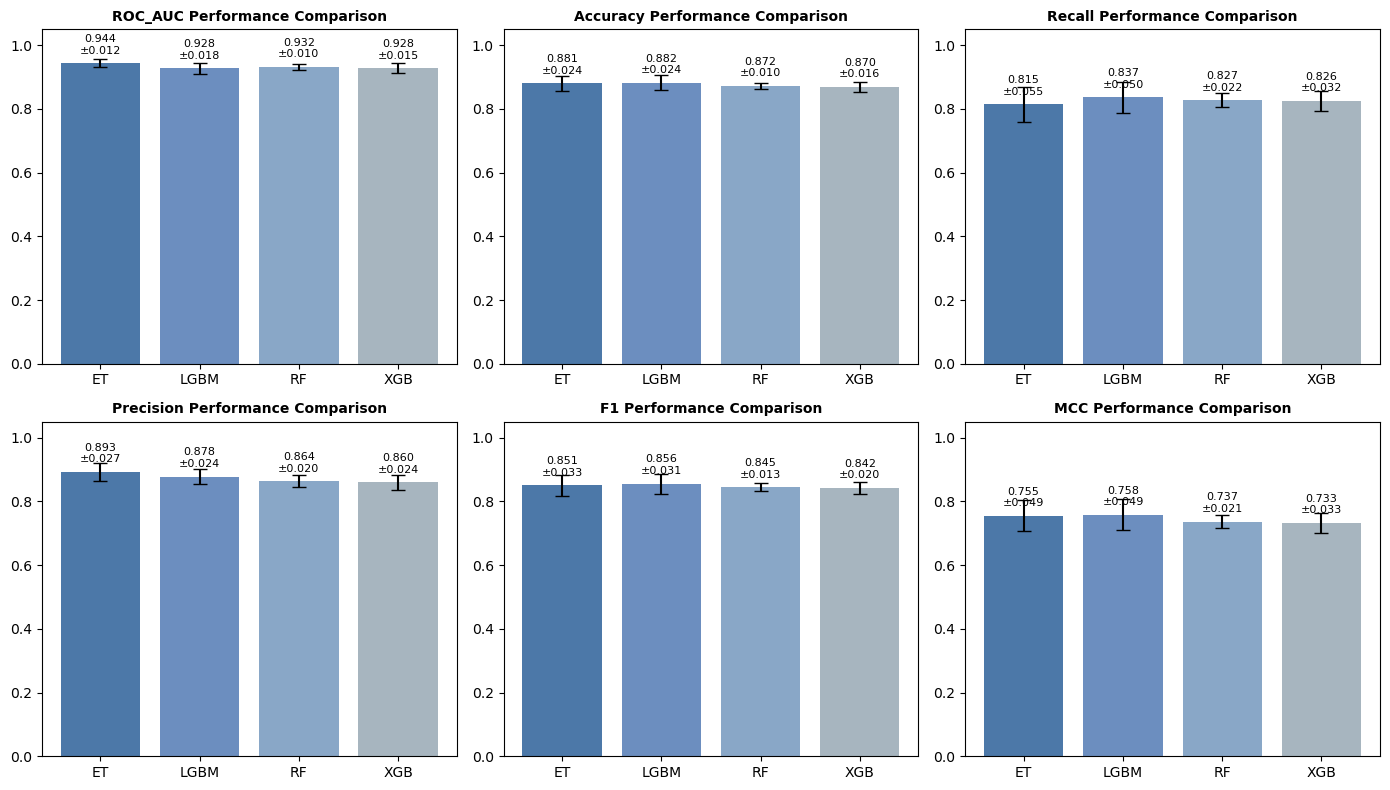

In [14]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "ROC_AUC",
    "Accuracy",
    "Recall",
    "Precision",
    "F1",
    "MCC"
]

models = summary_5seed["Model"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colors = [
    "#4C78A8",
    "#6C8EBF",
    "#89A7C7",
    "#A7B5BF"
]

for i, metric in enumerate(metrics):

    means = summary_5seed[f"{metric}_mean"]
    stds = summary_5seed[f"{metric}_std"]

    axes[i].bar(
        models,
        means,
        yerr=stds,
        capsize=5,
        color=colors
    )

    axes[i].set_title(
        f"{metric} Performance Comparison",
        fontsize=10,
        fontweight="bold"
    )

    axes[i].set_ylim(0, 1.05)

    for j, value in enumerate(means):
        axes[i].text(
            j,
            value + 0.03,
            f"{value:.3f}\n±{stds.iloc[j]:.3f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "publishable_metrics_5seed.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

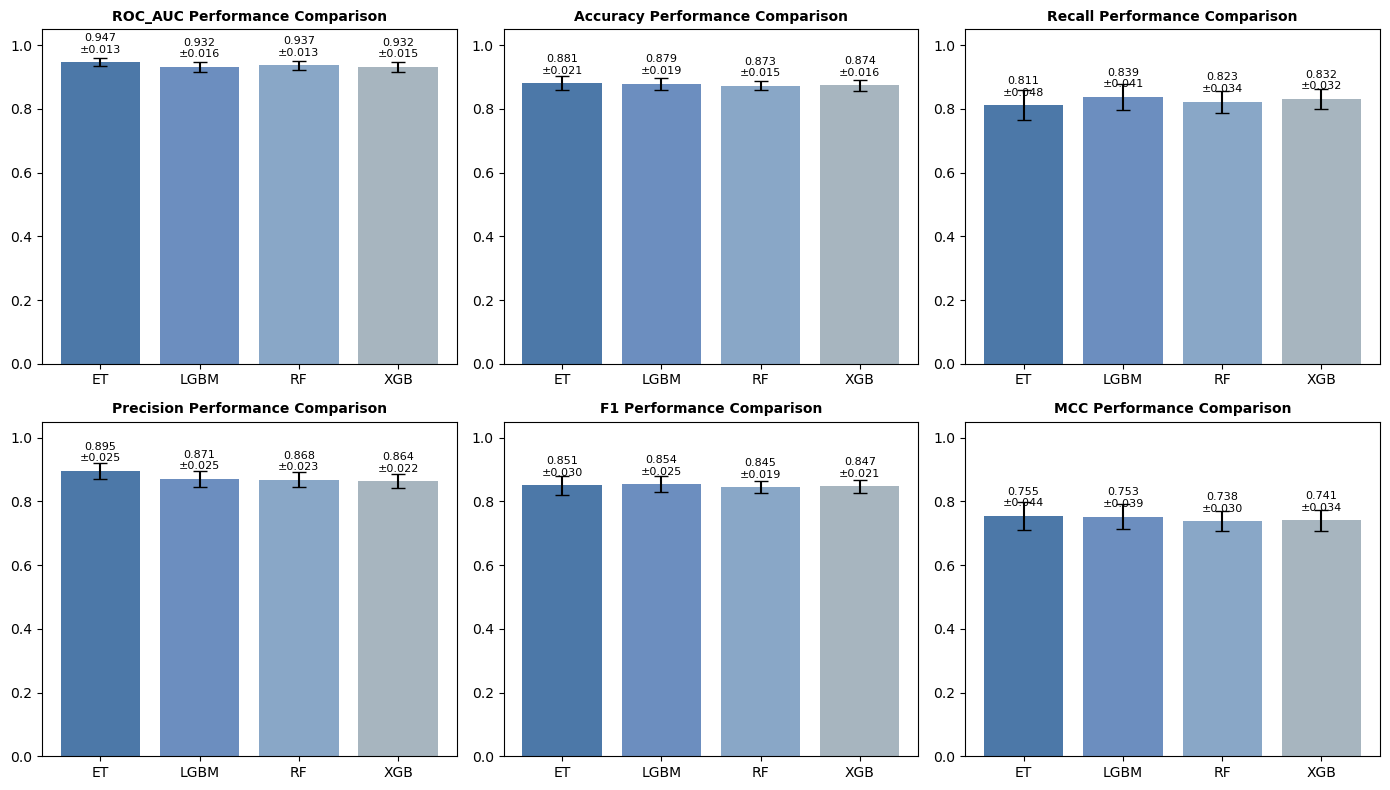

In [15]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "ROC_AUC",
    "Accuracy",
    "Recall",
    "Precision",
    "F1",
    "MCC"
]

models = summary_10seed["Model"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colors = [
    "#4C78A8",
    "#6C8EBF",
    "#89A7C7",
    "#A7B5BF"
]

for i, metric in enumerate(metrics):

    means = summary_10seed[f"{metric}_mean"]
    stds = summary_10seed[f"{metric}_std"]

    axes[i].bar(
        models,
        means,
        yerr=stds,
        capsize=5,
        color=colors
    )

    axes[i].set_title(
        f"{metric} Performance Comparison",
        fontsize=10,
        fontweight="bold"
    )

    axes[i].set_ylim(0, 1.05)

    for j, value in enumerate(means):
        axes[i].text(
            j,
            value + 0.03,
            f"{value:.3f}\n±{stds.iloc[j]:.3f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "publishable_metrics_10seed.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

comparison

In [16]:
models_10seed = {
    "RF": best_rf,
    "ET": best_et,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}

In [17]:
print(models_10seed.keys())

dict_keys(['RF', 'ET', 'XGB', 'LGBM'])


In [18]:
summary_10seed = results_df_10seed.groupby("Model").agg({

    "ROC_AUC": ["mean", "std"],
    "Accuracy": ["mean", "std"],
    "F1": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "MCC": ["mean", "std"]

}).round(4)

summary_10seed.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_10seed.columns
]

summary_10seed = summary_10seed.reset_index()

summary_10seed

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,MCC_mean,MCC_std
0,ET,0.9465,0.0126,0.8807,0.0215,0.8507,0.0297,0.8955,0.0254,0.8115,0.0476,0.7552,0.0440
1,LGBM,0.9324,0.0162,0.8795,0.0189,0.8538,0.0246,0.8709,0.0254,0.8385,0.0405,0.7526,0.0389
2,RF,0.9367,0.0134,0.8727,0.0146,0.8445,0.0193,0.8682,0.0230,0.8230,0.0344,0.7383,0.0303
3,XGB,0.9320,0.0150,0.8739,0.0162,0.8470,0.0207,0.8637,0.0216,0.8318,0.0322,0.7406,0.0337


In [19]:
results_df_10seed.to_csv(
    "results_df_10seed.csv",
    index=False
)

summary_10seed.to_csv(
    "summary_10seed.csv",
    index=False
)

print("✅ 10-seed results saved")

✅ 10-seed results saved


In [20]:
comparison = pd.DataFrame({
    "Model": summary_5seed["Model"],

    "ROC_AUC_5": summary_5seed["ROC_AUC_mean"],
    "ROC_AUC_10": summary_10seed["ROC_AUC_mean"],

    "F1_5": summary_5seed["F1_mean"],
    "F1_10": summary_10seed["F1_mean"],

    "MCC_5": summary_5seed["MCC_mean"],
    "MCC_10": summary_10seed["MCC_mean"]
})

comparison

,Model,ROC_AUC_5,ROC_AUC_10,F1_5,F1_10,MCC_5,MCC_10
0,ET,0.9437,0.9465,0.8511,0.8507,0.7552,0.7552
1,LGBM,0.9276,0.9324,0.8563,0.8538,0.7582,0.7526
2,RF,0.9325,0.9367,0.8447,0.8445,0.7370,0.7383
3,XGB,0.9283,0.9320,0.8421,0.8470,0.7325,0.7406


normality

In [21]:
from scipy.stats import shapiro
import pandas as pd

metrics = ["ROC_AUC", "F1", "MCC"]

normality_5seed = []

for metric in metrics:

    for model in ["RF", "ET", "XGB", "LGBM"]:

        scores = results_df_5seed[
            results_df_5seed["Model"] == model
        ][metric]

        stat, p = shapiro(scores)

        normality_5seed.append({
            "Metric": metric,
            "Model": model,
            "Statistic": round(stat, 4),
            "p_value": round(p, 4),
            "Normal": "Yes" if p > 0.05 else "No"
        })

normality_5seed = pd.DataFrame(normality_5seed)

normality_5seed

,Metric,Model,Statistic,p_value,Normal
0,ROC_AUC,RF,0.8890,0.3519,Yes
1,ROC_AUC,ET,0.9636,0.8329,Yes
2,ROC_AUC,XGB,0.9968,0.9973,Yes
3,ROC_AUC,LGBM,0.9601,0.8087,Yes
4,F1,RF,0.9389,0.6584,Yes
5,F1,ET,0.9828,0.9490,Yes
6,F1,XGB,0.9002,0.4110,Yes
7,F1,LGBM,0.9660,0.8490,Yes
8,MCC,RF,0.8495,0.1930,Yes
9,MCC,ET,0.9469,0.7147,Yes


In [22]:
from scipy.stats import shapiro
import pandas as pd

metrics = ["ROC_AUC", "F1", "MCC"]

normality_10seed = []

for metric in metrics:

    for model in ["RF", "ET", "XGB", "LGBM"]:

        scores = results_df_10seed[
            results_df_10seed["Model"] == model
        ][metric]

        stat, p = shapiro(scores)

        normality_10seed.append({
            "Metric": metric,
            "Model": model,
            "Statistic": round(stat, 4),
            "p_value": round(p, 4),
            "Normal": "Yes" if p > 0.05 else "No"
        })

normality_10seed = pd.DataFrame(normality_10seed)

normality_10seed

,Metric,Model,Statistic,p_value,Normal
0,ROC_AUC,RF,0.9577,0.7599,Yes
1,ROC_AUC,ET,0.8756,0.1161,Yes
2,ROC_AUC,XGB,0.9457,0.6185,Yes
3,ROC_AUC,LGBM,0.9393,0.5457,Yes
4,F1,RF,0.9580,0.7626,Yes
5,F1,ET,0.9516,0.6879,Yes
6,F1,XGB,0.9351,0.4997,Yes
7,F1,LGBM,0.9133,0.3047,Yes
8,MCC,RF,0.9229,0.3821,Yes
9,MCC,ET,0.9446,0.6049,Yes


anova repeated

In [23]:
anova_f1_5seed = results_df_5seed.pivot(
    index="Seed",
    columns="Model",
    values="F1"
)

anova_f1_5seed

Model,ET,LGBM,RF,XGB
Seed,,,,
42,0.898955,0.904110,0.865052,0.869863
52,0.862876,0.863787,0.837838,0.846667
62,0.810219,0.820144,0.842105,0.822695
72,0.845878,0.839161,0.847458,0.821918
82,0.837545,0.854167,0.830986,0.849123


In [24]:
from statsmodels.stats.anova import AnovaRM

anova_long_5seed = results_df_5seed[
    ["Seed", "Model", "F1"]
].copy()

anova_result_5seed = AnovaRM(
    data=anova_long_5seed,
    depvar="F1",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_5seed)

ModuleNotFoundError: No module named 'statsmodels'

In [1]:
import pandas as pd
import joblib

# =========================
# LOAD TABLES
# =========================

results_df_5seed = pd.read_csv(
    "results_df_5seed.csv"
)

summary_5seed = pd.read_csv(
    "summary_5seed.csv"
)

results_df_10seed = pd.read_csv(
    "results_df_10seed.csv"
)

summary_10seed = pd.read_csv(
    "summary_10seed.csv"
)

normality_5seed = pd.read_csv(
    "normality_5seed.csv"
)

normality_10seed = pd.read_csv(
    "normality_10seed.csv"
)

print("✅ all tables loaded")

✅ all tables loaded


In [2]:
import statsmodels
print(statsmodels.__version__)

0.14.5


In [3]:
anova_f1_5seed = results_df_5seed.pivot(
    index="Seed",
    columns="Model",
    values="F1"
)

anova_f1_5seed

Model,ET,LGBM,RF,XGB
Seed,,,,
42,0.898955,0.904110,0.865052,0.869863
52,0.862876,0.863787,0.837838,0.846667
62,0.810219,0.820144,0.842105,0.822695
72,0.845878,0.839161,0.847458,0.821918
82,0.837545,0.854167,0.830986,0.849123


In [4]:
from statsmodels.stats.anova import AnovaRM

anova_long_5seed = results_df_5seed[
    ["Seed", "Model", "F1"]
].copy()

anova_result_5seed = AnovaRM(
    data=anova_long_5seed,
    depvar="F1",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_5seed)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Model  1.0563 3.0000 12.0000 0.4037



In [5]:
from statsmodels.stats.anova import AnovaRM

anova_long_10seed = results_df_10seed[
    ["Seed", "Model", "F1"]
].copy()

anova_result_10seed = AnovaRM(
    data=anova_long_10seed,
    depvar="F1",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_10seed)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Model  1.0317 3.0000 27.0000 0.3942



In [6]:
anova_table_5seed = pd.DataFrame({
    "Seed_Set": ["5 Seed"],
    "Metric": ["F1"],
    "F_Value": [1.0563],
    "Num_DF": [3],
    "Den_DF": [12],
    "P_Value": [0.4037],
    "Conclusion": [
        "Not Significant" if 0.4037 > 0.05 else "Significant"
    ]
})

anova_table_5seed

,Seed_Set,Metric,F_Value,Num_DF,Den_DF,P_Value,Conclusion
0,5 Seed,F1,1.0563,3,12,0.4037,Not Significant


In [7]:
anova_table_10seed = pd.DataFrame({
    "Seed_Set": ["10 Seed"],
    "Metric": ["F1"],
    "F_Value": [1.0317],
    "Num_DF": [3],
    "Den_DF": [27],
    "P_Value": [0.3942],
    "Conclusion": [
        "Not Significant" if 0.3942 > 0.05 else "Significant"
    ]
})

anova_table_10seed

,Seed_Set,Metric,F_Value,Num_DF,Den_DF,P_Value,Conclusion
0,10 Seed,F1,1.0317,3,27,0.3942,Not Significant


In [8]:
anova_summary.to_csv(
    "anova_summary.csv",
    index=False
)

print("✅ ANOVA table saved")

NameError: name 'anova_summary' is not defined

In [9]:
from statsmodels.stats.anova import AnovaRM

anova_long_auc_5seed = results_df_5seed[
    ["Seed", "Model", "ROC_AUC"]
].copy()

anova_result_auc_5seed = AnovaRM(
    data=anova_long_auc_5seed,
    depvar="ROC_AUC",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_auc_5seed)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Model  5.0997 3.0000 12.0000 0.0167



In [10]:
from statsmodels.stats.anova import AnovaRM

anova_long_mcc_5seed = results_df_5seed[
    ["Seed", "Model", "MCC"]
].copy()

anova_result_mcc_5seed = AnovaRM(
    data=anova_long_mcc_5seed,
    depvar="MCC",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_mcc_5seed)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Model  1.8114 3.0000 12.0000 0.1987



In [11]:
anova_summary_5seed = pd.DataFrame({

    "Metric": ["F1", "ROC_AUC", "MCC"],

    "F_Value": [
        1.0563,
        5.0997,
        1.8114
    ],

    "Num_DF": [
        3,
        3,
        3
    ],

    "Den_DF": [
        12,
        12,
        12
    ],

    "P_Value": [
        0.4037,
        0.0167,
        0.1987
    ]

})

anova_summary_5seed["Conclusion"] = (
    anova_summary_5seed["P_Value"]
    .apply(lambda x:
           "Significant"
           if x < 0.05
           else "Not Significant")
)

anova_summary_5seed

,Metric,F_Value,Num_DF,Den_DF,P_Value,Conclusion
0,F1,1.0563,3,12,0.4037,Not Significant
1,ROC_AUC,5.0997,3,12,0.0167,Significant
2,MCC,1.8114,3,12,0.1987,Not Significant


In [12]:
from statsmodels.stats.anova import AnovaRM

anova_long_auc_10seed = results_df_10seed[
    ["Seed", "Model", "ROC_AUC"]
].copy()

anova_result_auc_10seed = AnovaRM(
    data=anova_long_auc_10seed,
    depvar="ROC_AUC",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_auc_10seed)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Model 11.0900 3.0000 27.0000 0.0001



In [13]:
from statsmodels.stats.anova import AnovaRM

anova_long_mcc_10seed = results_df_10seed[
    ["Seed", "Model", "MCC"]
].copy()

anova_result_mcc_10seed = AnovaRM(
    data=anova_long_mcc_10seed,
    depvar="MCC",
    subject="Seed",
    within=["Model"]
).fit()

print(anova_result_mcc_10seed)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Model  1.8006 3.0000 27.0000 0.1709



In [14]:
anova_summary_10seed = pd.DataFrame({

    "Metric": ["F1", "ROC_AUC", "MCC"],

    "F_Value": [
        anova_result_10seed.anova_table["F Value"].iloc[0],
        anova_result_auc_10seed.anova_table["F Value"].iloc[0],
        anova_result_mcc_10seed.anova_table["F Value"].iloc[0]
    ],

    "Num_DF": [
        anova_result_10seed.anova_table["Num DF"].iloc[0],
        anova_result_auc_10seed.anova_table["Num DF"].iloc[0],
        anova_result_mcc_10seed.anova_table["Num DF"].iloc[0]
    ],

    "Den_DF": [
        anova_result_10seed.anova_table["Den DF"].iloc[0],
        anova_result_auc_10seed.anova_table["Den DF"].iloc[0],
        anova_result_mcc_10seed.anova_table["Den DF"].iloc[0]
    ],

    "P_Value": [
        anova_result_10seed.anova_table["Pr > F"].iloc[0],
        anova_result_auc_10seed.anova_table["Pr > F"].iloc[0],
        anova_result_mcc_10seed.anova_table["Pr > F"].iloc[0]
    ]

})

anova_summary_10seed["Conclusion"] = (
    anova_summary_10seed["P_Value"]
    .apply(lambda x:
           "Significant"
           if x < 0.05
           else "Not Significant")
)

anova_summary_10seed = anova_summary_10seed.round(4)

anova_summary_10seed

,Metric,F_Value,Num_DF,Den_DF,P_Value,Conclusion
0,F1,1.0317,3.0,27.0,0.3942,Not Significant
1,ROC_AUC,11.0900,3.0,27.0,0.0001,Significant
2,MCC,1.8006,3.0,27.0,0.1709,Not Significant


post hoc roc auc

In [15]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import pandas as pd

# Pivot ROC_AUC
roc_auc_5seed = results_df_5seed.pivot(
    index="Seed",
    columns="Model",
    values="ROC_AUC"
)

comparisons = []
p_values = []
t_values = []

for model1, model2 in combinations(
    roc_auc_5seed.columns, 2
):

    t_stat, p = ttest_rel(
        roc_auc_5seed[model1],
        roc_auc_5seed[model2]
    )

    comparisons.append(
        f"{model1} vs {model2}"
    )

    t_values.append(t_stat)
    p_values.append(p)

# Bonferroni correction
reject, p_adj, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="bonferroni"
)

posthoc_5seed = pd.DataFrame({

    "Comparison": comparisons,
    "T_Value": t_values,
    "Raw_p": p_values,
    "Adjusted_p": p_adj,
    "Significant": reject

})

posthoc_5seed = posthoc_5seed.round(4)

posthoc_5seed.sort_values(
    "Adjusted_p"
)

,Comparison,T_Value,Raw_p,Adjusted_p,Significant
1,ET vs RF,3.5024,0.0248,0.1490,False
2,ET vs XGB,3.2605,0.0311,0.1864,False
0,ET vs LGBM,3.1040,0.0361,0.2165,False
3,LGBM vs RF,-0.7979,0.4696,1.0000,False
4,LGBM vs XGB,-0.3644,0.7340,1.0000,False
5,RF vs XGB,0.7685,0.4851,1.0000,False


In [16]:
posthoc_5seed.to_csv(
    "posthoc_ROC_AUC_5seed.csv",
    index=False
)

print("✅ posthoc ROC_AUC 5-seed saved")

✅ posthoc ROC_AUC 5-seed saved


In [17]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import pandas as pd

roc_auc_10seed = results_df_10seed.pivot(
    index="Seed",
    columns="Model",
    values="ROC_AUC"
)

comparisons = []
p_values = []
t_values = []

for model1, model2 in combinations(
    roc_auc_10seed.columns, 2
):

    t_stat, p = ttest_rel(
        roc_auc_10seed[model1],
        roc_auc_10seed[model2]
    )

    comparisons.append(
        f"{model1} vs {model2}"
    )

    t_values.append(t_stat)
    p_values.append(p)

reject, p_adj, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="bonferroni"
)

posthoc_10seed = pd.DataFrame({

    "Comparison": comparisons,
    "T_Value": t_values,
    "Raw_p": p_values,
    "Adjusted_p": p_adj,
    "Significant": reject

})

posthoc_10seed = posthoc_10seed.round(4)

posthoc_10seed.sort_values(
    "Adjusted_p"
)

,Comparison,T_Value,Raw_p,Adjusted_p,Significant
2,ET vs XGB,4.4181,0.0017,0.0101,True
0,ET vs LGBM,4.1143,0.0026,0.0157,True
1,ET vs RF,3.6938,0.0050,0.0298,True
5,RF vs XGB,1.6443,0.1345,0.8072,False
3,LGBM vs RF,-1.3652,0.2053,1.0000,False
4,LGBM vs XGB,0.3889,0.7064,1.0000,False


In [18]:
posthoc_10seed.to_csv(
    "posthoc_ROC_AUC_10seed.csv",
    index=False
)

print("✅ posthoc ROC_AUC 10-seed saved")

✅ posthoc ROC_AUC 10-seed saved


In [19]:
# Significance symbol

def sig_symbol(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

anova_summary_10seed["Sig"] = (
    anova_summary_10seed["P_Value"]
    .apply(sig_symbol)
)

anova_summary_10seed

,Metric,F_Value,Num_DF,Den_DF,P_Value,Conclusion,Sig
0,F1,1.0317,3.0,27.0,0.3942,Not Significant,
1,ROC_AUC,11.0900,3.0,27.0,0.0001,Significant,***
2,MCC,1.8006,3.0,27.0,0.1709,Not Significant,


In [20]:
# Significance symbol

def sig_symbol(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

posthoc_10seed["Sig"] = (
    posthoc_10seed["Adjusted_p"]
    .apply(sig_symbol)
)

posthoc_10seed = posthoc_10seed[
    [
        "Comparison",
        "T_Value",
        "Adjusted_p",
        "Sig"
    ]
]

posthoc_10seed

,Comparison,T_Value,Adjusted_p,Sig
0,ET vs LGBM,4.1143,0.0157,**
1,ET vs RF,3.6938,0.0298,**
2,ET vs XGB,4.4181,0.0101,**
3,LGBM vs RF,-1.3652,1.0000,
4,LGBM vs XGB,0.3889,1.0000,
5,RF vs XGB,1.6443,0.8072,


In [21]:
anova_summary_10seed.to_csv(
    "anova_summary_10seed_sig.csv",
    index=False
)

posthoc_10seed.to_csv(
    "posthoc_10seed_sig.csv",
    index=False
)

print("✅ significance tables saved")

✅ significance tables saved


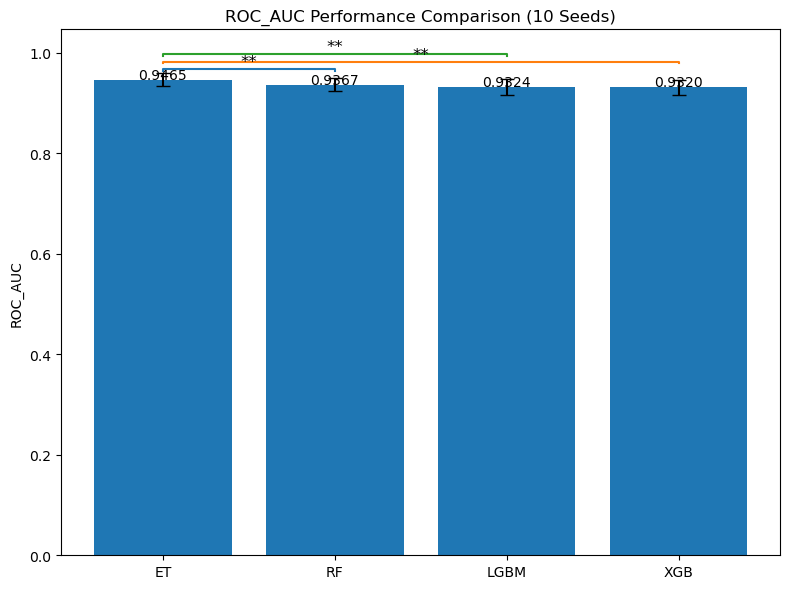

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# DATA ROC_AUC 10-SEED
# ==================================

roc_summary = summary_10seed[
    ["Model", "ROC_AUC_mean", "ROC_AUC_std"]
].copy()

roc_summary = roc_summary.sort_values(
    "ROC_AUC_mean",
    ascending=False
)

# ==================================
# PLOT
# ==================================

fig, ax = plt.subplots(figsize=(8,6))

x = np.arange(len(roc_summary))

bars = ax.bar(
    x,
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    capsize=5
)

ax.set_xticks(x)
ax.set_xticklabels(roc_summary["Model"])

ax.set_ylabel("ROC_AUC")
ax.set_title(
    "ROC_AUC Performance Comparison (10 Seeds)"
)

# ==================================
# SIGNIFICANCE BRACKET FUNCTION
# ==================================

def add_significance(
    ax,
    x1,
    x2,
    y,
    h,
    text
):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5
    )

    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha='center',
        va='bottom',
        fontsize=12
    )

# ==================================
# MODEL POSITION
# ==================================

model_pos = {
    model:i
    for i, model
    in enumerate(
        roc_summary["Model"]
    )
}

# ==================================
# BRACKETS
# ==================================

ymax = (
    roc_summary["ROC_AUC_mean"]
    + roc_summary["ROC_AUC_std"]
).max()

add_significance(
    ax,
    model_pos["ET"],
    model_pos["RF"],
    ymax+0.005,
    0.003,
    "**"
)

add_significance(
    ax,
    model_pos["ET"],
    model_pos["XGB"],
    ymax+0.020,
    0.003,
    "**"
)

add_significance(
    ax,
    model_pos["ET"],
    model_pos["LGBM"],
    ymax+0.035,
    0.003,
    "**"
)

# ==================================
# VALUE LABEL
# ==================================

for i, v in enumerate(
    roc_summary["ROC_AUC_mean"]
):
    ax.text(
        i,
        v+0.002,
        f"{v:.4f}",
        ha='center'
    )

plt.tight_layout()

plt.show()

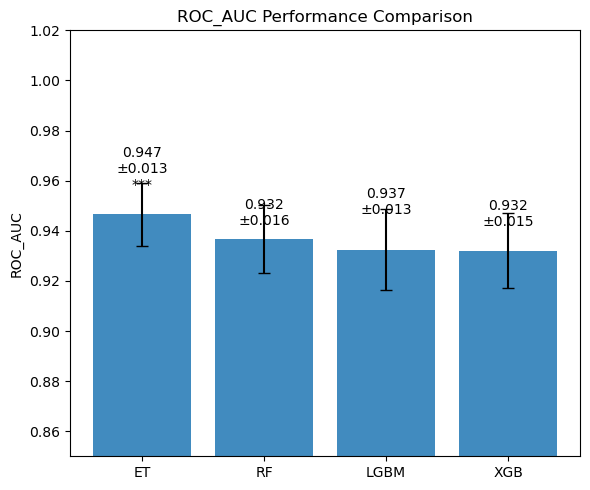

In [23]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    roc_summary["Model"],
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    capsize=4,
    alpha=0.85
)

for i,row in roc_summary.iterrows():

    label = f"{row['ROC_AUC_mean']:.3f}\n±{row['ROC_AUC_std']:.3f}"

    if row["Model"] == "ET":
        label += "\n***"

    plt.text(
        i,
        row["ROC_AUC_mean"]+0.01,
        label,
        ha="center",
        fontsize=10
    )

plt.ylabel("ROC_AUC")
plt.title("ROC_AUC Performance Comparison")
plt.ylim(0.85,1.02)

plt.tight_layout()
plt.show()

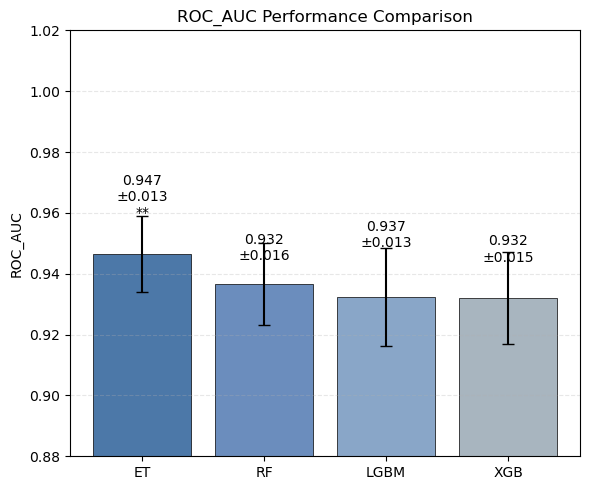

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))

colors = [
    "#4C78A8",  # ET
    "#6B8DBD",  # RF
    "#89A6C8",  # LGBM
    "#A8B5BF"   # XGB
]

bars = plt.bar(
    roc_summary["Model"],
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

for i,row in roc_summary.iterrows():

    label = (
        f"{row['ROC_AUC_mean']:.3f}\n"
        f"±{row['ROC_AUC_std']:.3f}"
    )

    if row["Model"] == "ET":
        label += "\n**"

    plt.text(
        i,
        row["ROC_AUC_mean"] + 0.012,
        label,
        ha="center",
        fontsize=10
    )

plt.ylabel("ROC_AUC")
plt.title("ROC_AUC Performance Comparison")

plt.ylim(0.88,1.02)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [25]:
add_significance(
    ax,
    model_pos["ET"],
    model_pos["RF"],
    ymax+0.005,
    0.002,
    "**"
)

add_significance(
    ax,
    model_pos["ET"],
    model_pos["LGBM"],
    ymax+0.015,
    0.002,
    "**"
)

add_significance(
    ax,
    model_pos["ET"],
    model_pos["XGB"],
    ymax+0.025,
    0.002,
    "**"
)

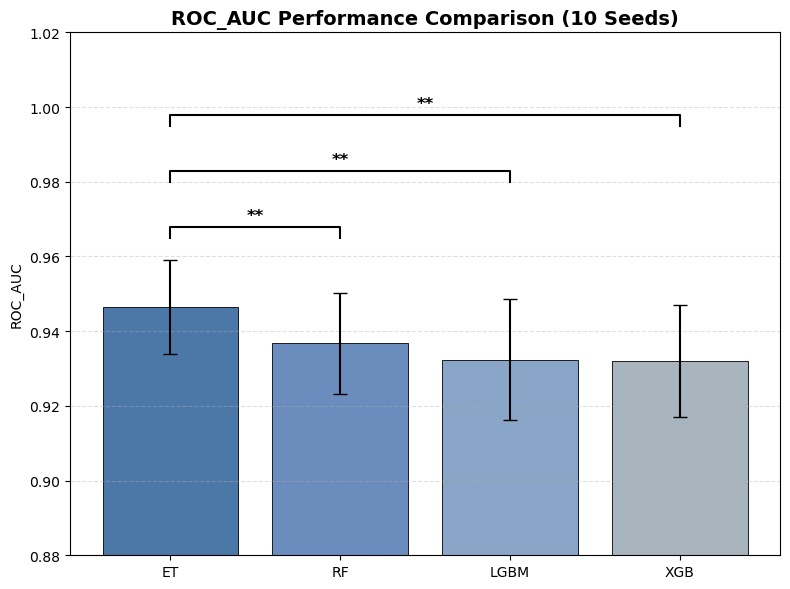

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# DATA
# =====================================

roc_summary = summary_10seed[
    ["Model", "ROC_AUC_mean", "ROC_AUC_std"]
].copy()

# Urutan model
model_order = ["ET", "RF", "LGBM", "XGB"]

roc_summary = (
    roc_summary
    .set_index("Model")
    .loc[model_order]
    .reset_index()
)

# =====================================
# PLOT
# =====================================

fig, ax = plt.subplots(figsize=(8,6))

colors = [
    "#4C78A8",   # ET
    "#6B8DBD",   # RF
    "#89A6C8",   # LGBM
    "#A8B5BF"    # XGB
]

x = np.arange(len(roc_summary))

bars = ax.bar(
    x,
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    capsize=5
)

ax.set_xticks(x)
ax.set_xticklabels(roc_summary["Model"])

ax.set_ylabel("ROC_AUC")
ax.set_title(
    "ROC_AUC Performance Comparison (10 Seeds)",
    fontsize=14,
    fontweight="bold"
)

# =====================================
# GRID
# =====================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# =====================================
# SIGNIFICANCE FUNCTION
# =====================================

def add_significance(ax, x1, x2, y, text):

    h = 0.003

    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        c="black"
    )

    ax.text(
        (x1+x2)/2,
        y+h+0.001,
        text,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# =====================================
# BRACKETS
# =====================================

add_significance(
    ax,
    0,  # ET
    1,  # RF
    0.965,
    "**"
)

add_significance(
    ax,
    0,  # ET
    2,  # LGBM
    0.980,
    "**"
)

add_significance(
    ax,
    0,  # ET
    3,  # XGB
    0.995,
    "**"
)

# =====================================
# LIMIT
# =====================================

ax.set_ylim(0.88, 1.02)

plt.tight_layout()

# SAVE
plt.savefig(
    "ROC_AUC_significance_10seed.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

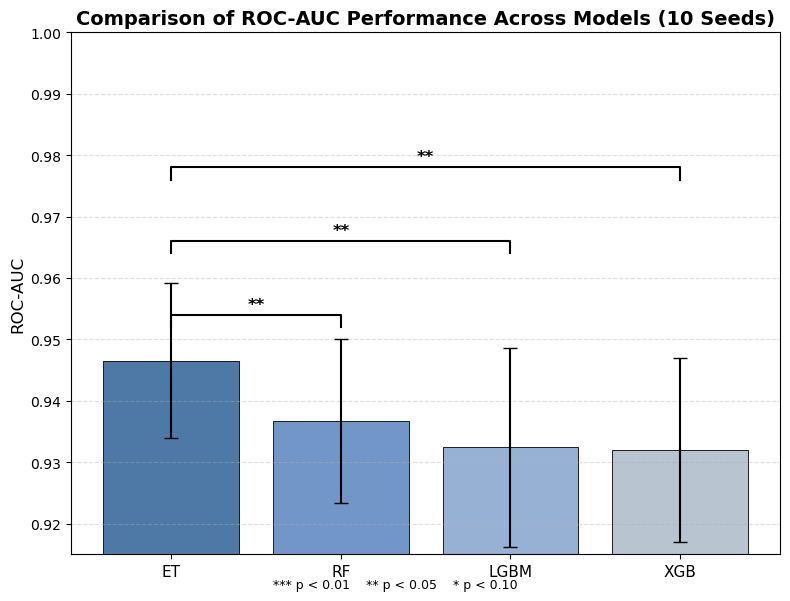

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# PREPARE DATA
# =====================================

roc_summary = summary_10seed[
    ["Model", "ROC_AUC_mean", "ROC_AUC_std"]
].copy()

model_order = ["ET", "RF", "LGBM", "XGB"]

roc_summary = (
    roc_summary
    .set_index("Model")
    .loc[model_order]
    .reset_index()
)

# =====================================
# SIGNIFICANCE FUNCTION
# =====================================

def add_significance(ax, x1, x2, y, text):

    h = 0.002

    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        c="black"
    )

    ax.text(
        (x1+x2)/2,
        y+h+0.0005,
        text,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# =====================================
# PLOT
# =====================================

fig, ax = plt.subplots(figsize=(8,6))

colors = [
    "#4E79A7",  # ET
    "#7396C8",  # RF
    "#97B1D5",  # LGBM
    "#B8C4CF"   # XGB
]

x = np.arange(len(roc_summary))

bars = ax.bar(
    x,
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    capsize=5
)

# =====================================
# AXIS
# =====================================

ax.set_xticks(x)
ax.set_xticklabels(
    roc_summary["Model"],
    fontsize=11
)

ax.set_ylabel(
    "ROC-AUC",
    fontsize=12
)

ax.set_title(
    "Comparison of ROC-AUC Performance Across Models (10 Seeds)",
    fontsize=14,
    fontweight="bold"
)

# =====================================
# GRID
# =====================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# =====================================
# SIGNIFICANCE BRACKETS
# =====================================

# ET vs RF
add_significance(
    ax,
    0,
    1,
    0.952,
    "**"
)

# ET vs LGBM
add_significance(
    ax,
    0,
    2,
    0.964,
    "**"
)

# ET vs XGB
add_significance(
    ax,
    0,
    3,
    0.976,
    "**"
)

# =====================================
# Y LIMIT
# =====================================

ax.set_ylim(
    0.915,
    1.00
)

# =====================================
# SIGNIFICANCE LEGEND
# =====================================

plt.figtext(
    0.5,
    0.01,
    "*** p < 0.01    ** p < 0.05    * p < 0.10",
    ha="center",
    fontsize=9
)

# =====================================
# SAVE
# =====================================

plt.tight_layout()

plt.savefig(
    "ROC_AUC_significance_10seed_final.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

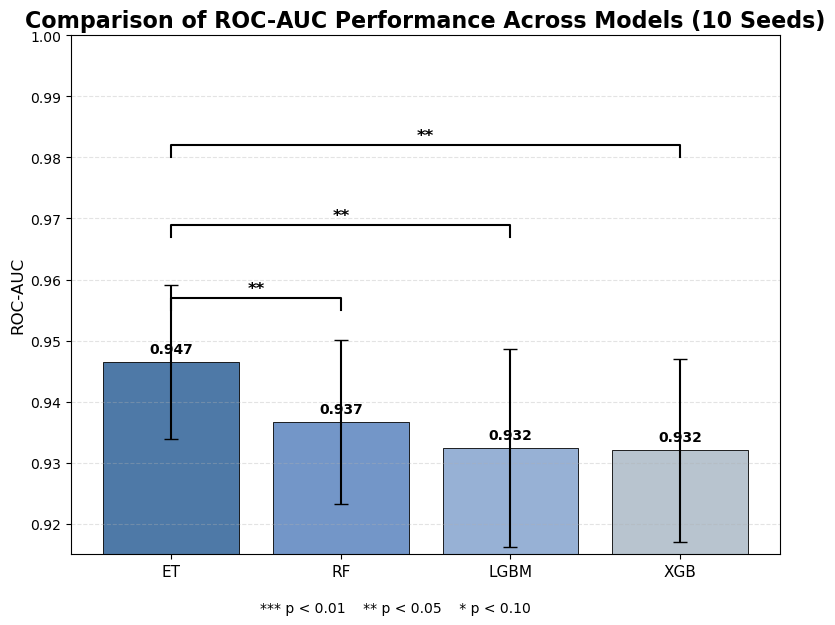

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# DATA
# ==================================================

roc_summary = summary_10seed[
    ["Model", "ROC_AUC_mean", "ROC_AUC_std"]
].copy()

model_order = ["ET", "RF", "LGBM", "XGB"]

roc_summary = (
    roc_summary
    .set_index("Model")
    .loc[model_order]
    .reset_index()
)

# ==================================================
# FUNCTION
# ==================================================

def add_significance(ax, x1, x2, y, text):

    h = 0.002

    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        c="black"
    )

    ax.text(
        (x1+x2)/2,
        y+h+0.0003,
        text,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# ==================================================
# FIGURE
# ==================================================

fig, ax = plt.subplots(figsize=(8,6))

colors = [
    "#4E79A7",   # ET
    "#7396C8",   # RF
    "#97B1D5",   # LGBM
    "#B8C4CF"    # XGB
]

x = np.arange(len(roc_summary))

bars = ax.bar(
    x,
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

# ==================================================
# MEAN VALUE LABEL
# ==================================================

for i, val in enumerate(roc_summary["ROC_AUC_mean"]):

    ax.text(
        i,
        val + 0.001,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ==================================================
# AXIS
# ==================================================

ax.set_xticks(x)

ax.set_xticklabels(
    roc_summary["Model"],
    fontsize=11
)

ax.set_ylabel(
    "ROC-AUC",
    fontsize=12
)

ax.set_title(
    "Comparison of ROC-AUC Performance Across Models (10 Seeds)",
    fontsize=16,
    fontweight="bold"
)

# ==================================================
# GRID
# ==================================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# ==================================================
# SIGNIFICANCE
# ==================================================

# ET vs RF
add_significance(
    ax,
    0,
    1,
    0.955,
    "**"
)

# ET vs LGBM
add_significance(
    ax,
    0,
    2,
    0.967,
    "**"
)

# ET vs XGB
add_significance(
    ax,
    0,
    3,
    0.980,
    "**"
)

# ==================================================
# LIMIT
# ==================================================

ax.set_ylim(
    0.915,
    1.000
)

# ==================================================
# FOOTNOTE
# ==================================================

plt.figtext(
    0.5,
    -0.03,
    "*** p < 0.01    ** p < 0.05    * p < 0.10",
    ha="center",
    fontsize=10
)

# ==================================================
# SAVE
# ==================================================

plt.tight_layout()

plt.savefig(
    "ROC_AUC_10seed_significance_final.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

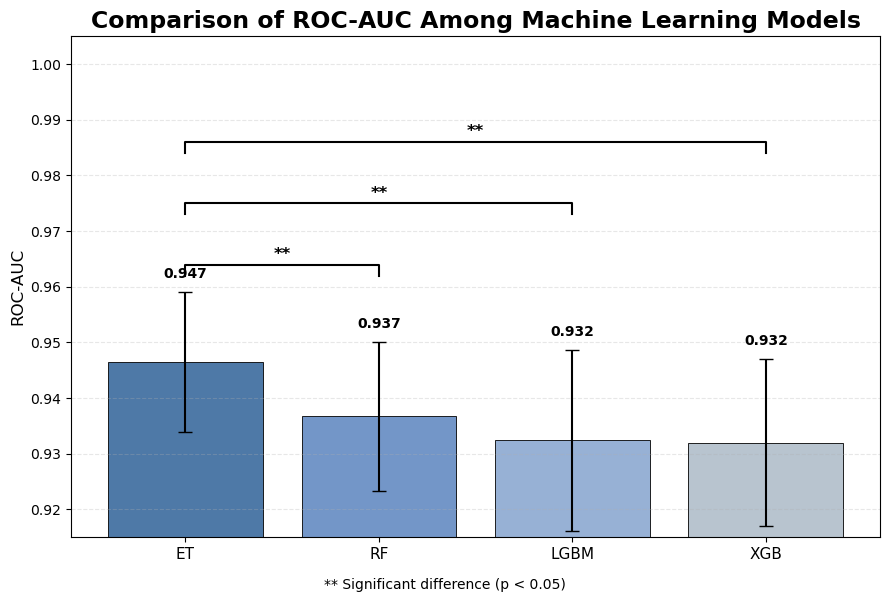

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# DATA
# ==================================================

roc_summary = summary_10seed[
    ["Model", "ROC_AUC_mean", "ROC_AUC_std"]
].copy()

model_order = ["ET", "RF", "LGBM", "XGB"]

roc_summary = (
    roc_summary
    .set_index("Model")
    .loc[model_order]
    .reset_index()
)

# ==================================================
# FUNCTION
# ==================================================

def add_significance(ax, x1, x2, y, text):

    h = 0.002

    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        color="black"
    )

    ax.text(
        (x1+x2)/2,
        y+h+0.0005,
        text,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# ==================================================
# FIGURE
# ==================================================

fig, ax = plt.subplots(figsize=(9,6))

colors = [
    "#4E79A7",  # ET
    "#7396C8",  # RF
    "#97B1D5",  # LGBM
    "#B8C4CF"   # XGB
]

x = np.arange(len(roc_summary))

bars = ax.bar(
    x,
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

# ==================================================
# MEAN LABELS
# ==================================================

for i, row in roc_summary.iterrows():

    ax.text(
        i,
        row["ROC_AUC_mean"] + row["ROC_AUC_std"] + 0.002,
        f"{row['ROC_AUC_mean']:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ==================================================
# AXIS
# ==================================================

ax.set_xticks(x)

ax.set_xticklabels(
    roc_summary["Model"],
    fontsize=11
)

ax.set_ylabel(
    "ROC-AUC",
    fontsize=12
)

ax.set_title(
    "Comparison of ROC-AUC Among Machine Learning Models",
    fontsize=17,
    fontweight="bold"
)

# ==================================================
# GRID
# ==================================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# ==================================================
# SIGNIFICANCE BRACKETS
# ==================================================

# ET vs RF
add_significance(
    ax,
    0,
    1,
    0.962,
    "**"
)

# ET vs LGBM
add_significance(
    ax,
    0,
    2,
    0.973,
    "**"
)

# ET vs XGB
add_significance(
    ax,
    0,
    3,
    0.984,
    "**"
)

# ==================================================
# LIMIT
# ==================================================

ax.set_ylim(
    0.915,
    1.005
)

# ==================================================
# FOOTNOTE
# ==================================================

plt.figtext(
    0.5,
    0.01,
    "** Significant difference (p < 0.05)",
    ha="center",
    fontsize=10
)

# ==================================================
# LAYOUT
# ==================================================

plt.tight_layout(
    rect=[0, 0.03, 1, 1]
)

# ==================================================
# SAVE
# ==================================================

plt.savefig(
    "ROC_AUC_10seed_final_journal_style.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [30]:
# ==================================================
# MEAN LABELS
# ==================================================

for i, row in roc_summary.iterrows():

    ax.text(
        i,
        row["ROC_AUC_mean"] + row["ROC_AUC_std"] + 0.002,
        f"{row['ROC_AUC_mean']:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

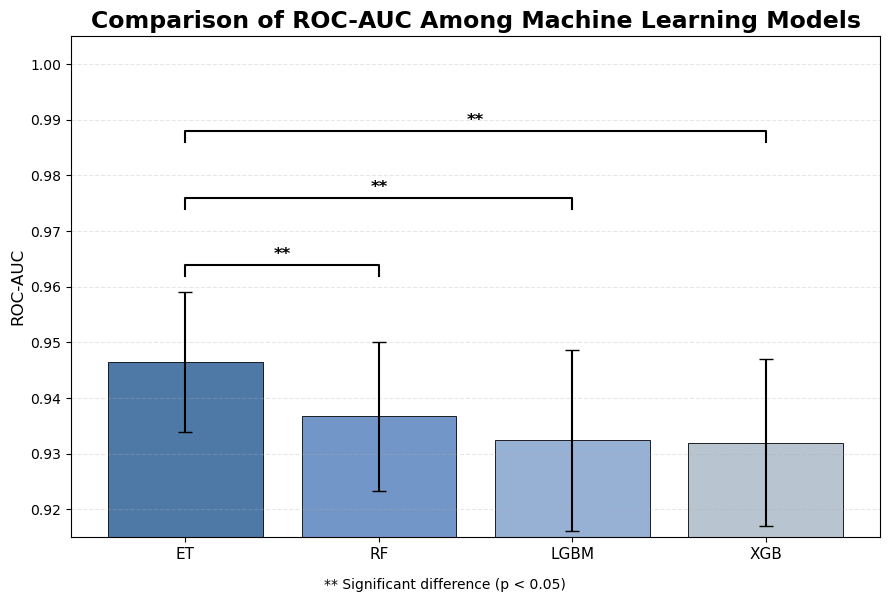

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# DATA
# ==================================================

roc_summary = summary_10seed[
    ["Model", "ROC_AUC_mean", "ROC_AUC_std"]
].copy()

model_order = ["ET", "RF", "LGBM", "XGB"]

roc_summary = (
    roc_summary
    .set_index("Model")
    .loc[model_order]
    .reset_index()
)

# ==================================================
# FUNCTION
# ==================================================

def add_significance(ax, x1, x2, y, text):

    h = 0.002

    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        color="black"
    )

    ax.text(
        (x1+x2)/2,
        y+h+0.0005,
        text,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# ==================================================
# FIGURE
# ==================================================

fig, ax = plt.subplots(figsize=(9,6))

colors = [
    "#4E79A7",  # ET
    "#7396C8",  # RF
    "#97B1D5",  # LGBM
    "#B8C4CF"   # XGB
]

x = np.arange(len(roc_summary))

bars = ax.bar(
    x,
    roc_summary["ROC_AUC_mean"],
    yerr=roc_summary["ROC_AUC_std"],
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

# ==================================================
# AXIS
# ==================================================

ax.set_xticks(x)

ax.set_xticklabels(
    roc_summary["Model"],
    fontsize=11
)

ax.set_ylabel(
    "ROC-AUC",
    fontsize=12
)

ax.set_title(
    "Comparison of ROC-AUC Among Machine Learning Models",
    fontsize=17,
    fontweight="bold"
)

# ==================================================
# GRID
# ==================================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# ==================================================
# SIGNIFICANCE BRACKETS
# ==================================================

# ET vs RF
add_significance(
    ax,
    0,
    1,
    0.962,
    "**"
)

# ET vs LGBM
add_significance(
    ax,
    0,
    2,
    0.974,
    "**"
)

# ET vs XGB
add_significance(
    ax,
    0,
    3,
    0.986,
    "**"
)

# ==================================================
# LIMIT
# ==================================================

ax.set_ylim(
    0.915,
    1.005
)

# ==================================================
# FOOTNOTE
# ==================================================

plt.figtext(
    0.5,
    0.01,
    "** Significant difference (p < 0.05)",
    ha="center",
    fontsize=10
)

# ==================================================
# LAYOUT
# ==================================================

plt.tight_layout(
    rect=[0, 0.03, 1, 1]
)

# ==================================================
# SAVE
# ==================================================

plt.savefig(
    "ROC_AUC_10seed_final_journal_style.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [33]:
anova_table_10seed = pd.DataFrame({
    "Metric": ["F1 Score", "ROC-AUC", "MCC"],
    "F Statistic": [1.0317, 11.0900, 1.8006],
    "df1": [3, 3, 3],
    "df2": [27, 27, 27],
    "p-value": [0.3942, 0.0001, 0.1709]
})

def signif_symbol(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

anova_table_10seed["Significance"] = (
    anova_table_10seed["p-value"]
    .apply(signif_symbol)
)

anova_table_10seed

,Metric,F Statistic,df1,df2,p-value,Significance
0,F1 Score,1.0317,3,27,0.3942,ns
1,ROC-AUC,11.0900,3,27,0.0001,***
2,MCC,1.8006,3,27,0.1709,ns


In [34]:
anova_table_10seed = pd.DataFrame({
    "Metric": ["F1 Score", "ROC-AUC", "MCC"],
    "F Statistic": [1.0317, 11.0900, 1.8006],
    "df1": [3, 3, 3],
    "df2": [27, 27, 27],
    "p-value": [0.3942, 0.0001, 0.1709]
})

def signif_symbol(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

anova_table_10seed["Sig."] = (
    anova_table_10seed["p-value"]
    .apply(signif_symbol)
)

anova_table_10seed

,Metric,F Statistic,df1,df2,p-value,Sig.
0,F1 Score,1.0317,3,27,0.3942,
1,ROC-AUC,11.0900,3,27,0.0001,***
2,MCC,1.8006,3,27,0.1709,


In [35]:
anova_journal = pd.DataFrame({
    "Metric": ["F1 Score", "ROC-AUC", "MCC"],
    "F(df1,df2)": [
        "1.032 (3,27)",
        "11.090 (3,27)",
        "1.801 (3,27)"
    ],
    "p-value": [
        "0.394",
        "<0.001",
        "0.171"
    ],
    "Sig.": [
        "",
        "***",
        ""
    ]
})

anova_journal

,Metric,"F(df1,df2)",p-value,Sig.
0,F1 Score,"1.032 (3,27)",0.394,
1,ROC-AUC,"11.090 (3,27)",<0.001,***
2,MCC,"1.801 (3,27)",0.171,


In [36]:
from IPython.display import display

styled = (
    anova_journal.style
    .hide(axis="index")
    .set_caption("Table X. Repeated Measures ANOVA Results (10 Seeds)")
    .set_properties(**{
        "text-align": "center"
    })
)

display(styled)

Metric,"F(df1,df2)",p-value,Sig.
F1 Score,"1.032 (3,27)",0.394,
ROC-AUC,"11.090 (3,27)",<0.001,***
MCC,"1.801 (3,27)",0.171,


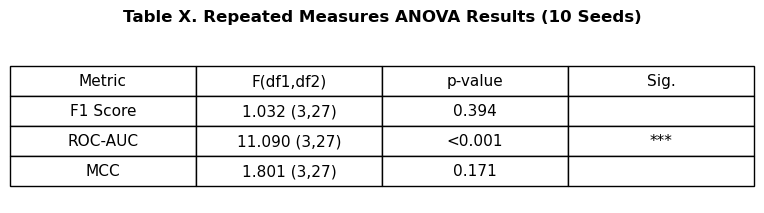

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

table = ax.table(
    cellText=anova_journal.values,
    colLabels=anova_journal.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title(
    "Table X. Repeated Measures ANOVA Results (10 Seeds)",
    pad=20,
    fontweight='bold'
)

plt.show()

In [38]:
import joblib

checkpoint = {
    "summary_10seed": summary_10seed,
    "anova_summary_10seed": anova_summary_10seed,
    "posthoc_10seed": posthoc_10seed,

    # model terbaik
    "ET_model": ET_model,  # ganti kalau nama variabelmu beda

    # opsional
    "results_df_10seed": results_df_10seed
}

joblib.dump(
    checkpoint,
    "CYP3A4_checkpoint.pkl"
)

print("✅ Checkpoint saved: CYP3A4_checkpoint.pkl")

NameError: name 'ET_model' is not defined